## ISLAS2022 microphysics COMPOSITE




In [ ]:
# imports from packages
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.lines import Line2D
from matplotlib_map_utils.core import north_arrow
import matplotlib.dates as mdates
import matplotlib as mpl
from windrose import WindroseAxes
from datetime import date
import glob
import os
import seaborn as sns
import numb_conc # functions relating to number concenctration calculations
import plots

from utils.composite_utils import add_alt_bins, add_dist_bins, add_t_bins, create_counts, add_slf_bins
from utils.plot_utils import plot_flight_obs, plot_flight_obs_single, plot_heatmap_ax, add_sect
from utils.derived_param_utils import calculate_slf, mass_param
from utils.dataset_prep_utils import preselect, incloud_select, nc_save_with_check, sea_ice_from_sat

# add small change

In [2]:
# --- Global formatting/settings/variables

# formatting for only showing time on the x-axis for plots per flight
# Use by setting axs[1,0].xaxis.set_major_formatter(formatter) for each axis where only time should show
formatter = mdates.DateFormatter('%H:%M')

level = 'L1' # use level 1 data
lwc = 'LWC calc' #name of lwc parameter to use in calculations: The 
iwc = 'IWC_H10'  # use the IWC parameter connected to the parametrization (Heymsfield)
#iwc = 'IWC100' # original from SODA, Brown

# --Paths
save_path = '/home/ninalar/Documents/MC2/procIslasMicrophy-1/save_images/sample_rate/new/'
processed_path = f'/home/ninalar/Documents/MC2/Results_2022-islas/Processed/ISLAS_processed/{level}' # regular path
main_path = '/home/ninalar/Documents/MC2/Results_2022-islas/Processed/with_distance_from_ice' # path with sea ice distance
sic_path = '/home/ninalar/Documents/MC2/procIslasMicrophy/sea_ice_satellite/asi-n6250-'

# --Filename structures
sic_file_struct = '-5.4_regridded.nc'
file_struct = '/microphy_5s_*.nc' # structure of cip text-file names

extr_txt = '_brown' # extra text to add to filenames

# --Additional settings
#colors for flights (for consistent coloring in plots)
c_flights = {'IS22-01':'wheat',
            'IS22-02':'tab:orange',
            'IS22-03':'tab:cyan',
            'IS22-04':'tab:purple',
            'IS22-05':'tab:pink',
            'IS22-06':'tab:brown',
            'IS22-07':'tab:red',
            'IS22-08':'tab:olive',
            'IS22-09':'tab:grey',
            'IS22-10':'tab:blue',
            'IS22-11':'tab:green'}

In [ ]:
# --- Data import

# ---- Microphysics data
# Import the processed data:
# get all the .nc files in the processed path
files = glob.glob(processed_path+file_struct)

# Exclude the file containing 'IS22-09' (flew over land)
files_to_exclude = [f for f in files if 'IS22-09' in os.path.basename(f)]
files_to_include = [f for f in files if f not in files_to_exclude]

# ds is the full dataset with no selections
ds = xr.open_mfdataset(files_to_include, combine='by_coords', combine_attrs='drop_conflicts')  # open withouth attributes
ds.close()


#get full extent of the dataset:
full_extent = [ds.lon.values.min()-5, ds.lon.values.max()+1, ds.lat.values.min()-3, ds.lat.values.max()+3]

# add distance from sea ice to dataset
# TEMPORARY FIX: get the distance from sea ice values from the files Filip has done instead of running the code
# TODO: add this from the things from Filip
temp_files = glob.glob(main_path+file_struct)
temp_ds = xr.open_mfdataset(temp_files, combine='by_coords',combine_attrs='drop_conflicts')
temp_ds.close()

temp_ds = temp_ds[['distance_from_ice','lon_step_upwind','lat_step_upwind','lon_step_downwind','lat_step_downwind']]

# join the temp to the ds to add the distance from ice
ds = xr.merge([ds, temp_ds], join='inner')

#----- Other datasets
# get sea ice concentration for the max and min dates for later plots
max_time = pd.to_datetime(ds.time.values.max()).strftime('%Y%m%d') # get max and min from dataset
min_time = pd.to_datetime(ds.time.values.min()).strftime('%Y%m%d')
dates = [max_time, min_time]
sic_max_ds, sic_min_ds = sea_ice_from_sat(sic_path, sic_file_struct, dates)


/home/ninalar/miniconda3/envs/microphy/lib/python3.12/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


In [4]:
# calculate IWC with set mass-dimension parametrization
param = 'Heymsfield2010_general'
name_add = '_H10'
ds = mass_param(param, ds, name_add=name_add)


### Binning by distance to sea ice, altitude and temperature


In [5]:
# --- Distance bin set up
dist_bin_size = 200 # alternatives: 125, 200, 250, 300

# Distances from sea ice for the relevant observations
#dist_df = ds_relevant['distance_from_ice'].to_dataframe() # original made from selection
dist_df = ds['distance_from_ice'].to_dataframe() # made based on full dataset (inlcuding over land)


# min, max, mean distance from sea ice per flight
f_dist_min = dist_df.groupby("islasid").min()
f_dist_max = dist_df.groupby("islasid").max()
f_dist_mean = dist_df.groupby("islasid").mean()

# Campaign min and max distance from sea ice
min_dist = dist_df['distance_from_ice'].min()
max_dist = dist_df['distance_from_ice'].max()

# create distance bins based on the dist_bin_size and the max/min for the total dataset
if dist_bin_size == 125:
    dist_bins = np.arange(dist_df['distance_from_ice'].min(),dist_df['distance_from_ice'].max()+125,125) # gives 11 distance bins of 125 km
    d_text ='dist125'
    
elif dist_bin_size == 200:
    dist_bins = np.arange(dist_df['distance_from_ice'].min()-75,dist_df['distance_from_ice'].max()+175,200) # gives 8 distance bins of 200 km
    d_text ='dist200'
elif dist_bin_size == 250:
    dist_bins = np.arange(dist_df['distance_from_ice'].min()-125,dist_df['distance_from_ice'].max()+175,250) # gives 6 distance bins of 250 km
    d_text ='dist250'
elif dist_bin_size == 300:
    dist_bins = np.arange(dist_df['distance_from_ice'].min()-175,dist_df['distance_from_ice'].max()+175,300) # gives 6 distance bins of 300 km 
    d_text ='dist300'


# Update savepath to reflect distance bin size
save_path = save_path + d_text + '/' # save the different dist-bin sizes in different folders

# add distance bins to xarray
ds = add_dist_bins(ds, dist_bins)

# sanity check for the binning:
print(f'Distance bin size: {dist_bin_size}')
print(f'save path: {save_path}')
print('Distance bin structure:')
print(f'Min: {min_dist}, Max: {max_dist}')
print(dist_bins)

Distance bin size: 200
save path: /home/ninalar/Documents/MC2/procIslasMicrophy-1/save_images/sample_rate/new/dist200/
Distance bin structure:
Min: -125.0, Max: 4775.0
[-200.    0.  200.  400.  600.  800. 1000. 1200. 1400. 1600. 1800. 2000.
 2200. 2400. 2600. 2800. 3000. 3200. 3400. 3600. 3800. 4000. 4200. 4400.
 4600. 4800.]


In [6]:
# --- Altitude bin set up
alt_bin_size = 300

# Define the bin edges for the altitude (based on the incloud data)
#altitude_bins = np.arange(0, ds_relevant['alt'].max() + alt_bin_size, alt_bin_size) # based on max values in data Original
altitude_bins = np.arange(0, ds['alt'].max() + alt_bin_size, alt_bin_size) # based on max values in data
bin_labels = (altitude_bins[:-1] + altitude_bins[1:]) / 2

# add altitude bins to xarray
ds = add_alt_bins(ds,altitude_bins)

# sanity check for the binning:
print(f'Altitude bin size: {alt_bin_size}')
print('Altitude bin structure:')
print(altitude_bins)

Altitude bin size: 300
Altitude bin structure:
[   0.  300.  600.  900. 1200. 1500. 1800. 2100. 2400. 2700. 3000. 3300.
 3600. 3900. 4200. 4500. 4800. 5100. 5400. 5700.]


In [7]:
# --- Temperature bin set up
t_bin_size = 2

# get the lowest bin bound based on the lowest value and the bin size
T = ds['T']     
T_min = float(T.min())
lower = np.floor(T_min / t_bin_size) * t_bin_size

#define bin edges
temp_bins = np.arange(lower, 0+t_bin_size, t_bin_size)

# Define bin edges for temperature bins (5 degrees)
#temp_bins = np.arange(-35, 0, t_bin_size) # selected out data below -35 allready  ORIGINAL based on ds_relevant

# add_t_bins to xarray
ds = add_t_bins(ds, temp_bins)

# sanity check for the binning:
print(f'Temperature bin size: {t_bin_size}')
print('Temperature bin structure:')
print(temp_bins)

Temperature bin size: 2
Temperature bin structure:
[-48. -46. -44. -42. -40. -38. -36. -34. -32. -30. -28. -26. -24. -22.
 -20. -18. -16. -14. -12. -10.  -8.  -6.  -4.  -2.   0.]


In [8]:
#---- Set selection flags

ds_bf = ds.copy() # for calculating the brown & francis values

# Select relevant data with preselect (Temp, Lat, Roll, Head, distances not covering complete clouds)
ds, ds_relevant, pre_text = preselect(ds, rm_dist=975) # Default preselect

# select in-cloud data based on IWC/LWC threshold
ds,ds_incloud, th_method, iwc_th = incloud_select(ds, lwc, iwc, th_method='LWC_IWC_th')

# select based on brown and francis IWC
ds_bf, ds_relevant_bf, pre_text = preselect(ds_bf, rm_dist=975) # Default preselect
ds_bf, ds_bf_incloud, th_method_bf, iwc_th_bf = incloud_select(ds_bf, lwc, 'IWC100', th_method='LWC_IWC_th')

# Calculate SLF (Korolev version) for incloud values
ds = calculate_slf(ds,'IWC_H10','LWC calc')

# drop parametrization info (not compatible with netcdf file)
del ds['IWC_H10'].attrs['parameterization info']
del ds['MASS_H10'].attrs['parameterization info']


In [9]:
# separate out the relevant and the incloud values for later calculations
rel_mask = (ds['relevant_mcao_flag']==True).compute()
ds_relevant = ds.where(rel_mask, drop=True)

incloud_mask = (ds_relevant['incloud_flag']==True).compute()
ds_incloud = ds_relevant.where(incloud_mask, drop=True)


In [10]:
# do the same for the brown and francis data
# Calculate SLF (Korolev version) for incloud values
#ds_bf = calculate_slf(ds_bf,'IWC100','LWC calc')

# drop parametrization info (not compatible with netcdf file)
del ds_bf['IWC_H10'].attrs['parameterization info']
del ds_bf['MASS_H10'].attrs['parameterization info']

# separate out the relevant and the incloud values for later calculations
rel_mask = (ds_bf['relevant_mcao_flag']==True).compute()
ds_relevant_bf = ds_bf.where(rel_mask, drop=True)

incloud_mask = (ds_relevant_bf['incloud_flag']==True).compute()
ds_incloud_bf = ds_relevant_bf.where(incloud_mask, drop=True)

In [11]:
ds

<xarray.Dataset> Size: 182MB
Dimensions:                 (time: 22392, CDP_Bin: 30, Vector64: 64,
                             Vector40: 40, step: 201)
Coordinates:
  * time                    (time) datetime64[ns] 179kB 2022-03-22T11:37:21 ....
  * CDP_Bin                 (CDP_Bin) int64 240B 1 2 3 4 5 6 ... 26 27 28 29 30
    lat                     (time) float32 90kB dask.array<chunksize=(2505,), meta=np.ndarray>
    lon                     (time) float32 90kB dask.array<chunksize=(2505,), meta=np.ndarray>
    alt                     (time) float32 90kB dask.array<chunksize=(2505,), meta=np.ndarray>
    islasid                 (time) <U7 627kB 'IS22-02' 'IS22-02' ... 'IS22-11'
    dist_bin                (time) int64 179kB 2800 2800 2800 ... 1400 1400 1400
    altitude_bin            (time) int64 179kB 3750 3750 3750 ... 5250 5250 5250
    temp_bin                (time) int64 179kB -20 -20 -20 -20 ... -46 -46 -46
Dimensions without coordinates: Vector64, Vector40, step
Data variables: (12/91)
    base_time               (time) datetime64[ns] 179kB 2022-03-22T11:37:21 ....
    utc_time                (time) float64 179kB dask.array<chunksize=(2358,), meta=np.ndarray>
    TAS                     (time) float32 90kB dask.array<chunksize=(2358,), meta=np.ndarray>
    MIDBINS                 (time, Vector64) float32 6MB dask.array<chunksize=(2358, 64), meta=np.ndarray>
    ACTIVETIME              (time) float32 90kB dask.array<chunksize=(2358,), meta=np.ndarray>
    SA                      (time, Vector64) float32 6MB dask.array<chunksize=(2358, 64), meta=np.ndarray>
    ...                      ...
    MASS_H10                (time, Vector64) float32 6MB dask.array<chunksize=(2358, 64), meta=np.ndarray>
    IWC_H10                 (time) float32 90kB dask.array<chunksize=(2358,), meta=np.ndarray>
    relevant_mcao_flag      (time) bool 22kB False False False ... False False
    incloud_flag            (time) bool 22kB False False False ... False False
    TWC_H10                 (time) float64 179kB dask.array<chunksize=(2358,), meta=np.ndarray>
    SLF_H10                 (time) float64 179kB dask.array<chunksize=(2358,), meta=np.ndarray>
Attributes:
    date_modified:            2025-11-01
    Joint sample rate (sek):  5.0

In [12]:
# Save files per flight and add metadata

# remove unused attributes (leftovers from joining, not to be added to files )
del ds.attrs['date_modified']
del ds.attrs['Joint sample rate (sek)']

# go through per flight
flights = np.unique(ds.islasid.values)
for flight in flights:
        
    # Select out the data connected with the flight
    f1_mask = (ds['islasid']==flight).compute()
    ds_f = ds.where(f1_mask, drop = True)

    # get specific flight details
    lat_min_flight = ds_f.lat.values.min()
    lat_max_flight = ds_f.lat.values.max()
    lon_min_flight = ds_f.lon.values.min()
    lon_max_flight = ds_f.lon.values.max()
    alt_min_flight = ds_f.alt.values.min()
    alt_max_flight = ds_f.alt.values.max()
    time_start_flight = np.datetime_as_string(ds_f.time.values.min(), unit="s")
    time_end_flight = np.datetime_as_string(ds_f.time.values.max(), unit="s")

    # update metadata
    ds_f = ds_f.assign_attrs(
    description = "Post-processed measurements from Cloud Droplet Probe and Cloud Imaging Probe mounted on ATR42 during the ISLAS2022 campaign, dataset is collocated with aircraft navigational data and the distance from the sea ice (for details, see Larsgård et al. 2026)",
    creator_email = "n.e.larsgard@geo.uio.no",
    creator_name = "Nina Elisabeth Larsgård",
    creator_institution = "Department of Geoscience, University of Oslo, Norway",
    date_created = f"{date.today()}",
    reference = "Larsgård et al. (2026), Sodemann et al. (submitted manuscript, 2026), Sodemann et al. (dataset in review, 2026) https://doi.pangaea.de/10.1594/PANGAEA.997052",
    version = "1.0",
    title = "Processed CDP and CIP measurements from ATR42 during the ISLAS2022 campaign",
    keywords = "Earth Science > Atmosphere > Clouds > Cloud microphysics; Earth Science > Atmosphere > Air Temparature;",
    keywords_vocabulary = "GCMD",
    geospatial_lat_min = lat_min_flight,
    geospatial_lat_max = lat_max_flight,
    geospatial_lon_min = lon_min_flight,
    geospatial_lon_max = lon_max_flight,
    geospatial_vertical_min = alt_min_flight,
    geospatial_vertical_max = alt_max_flight,
    geospatial_vertical_postition = "up",
    geospatial_vertical_units = "meters",
    time_coverage_start = time_start_flight,
    time_coverage_end = time_end_flight,
    Conventions = "ACDD-1.3, CF-1.13",
    history = f"{date.today()}: file created.",
    license = "Creative Commons Attribution v4.0",
    creator_type = "person",
    project = "ERC Consolidator Grant project ISLAS (Isotopic Links to Atmospheric Water's Sources), ERC Consolidator Grant “STEP-CHANGE” (grant number 101045273), ERC StG758005, University of Oslo Sustainability Initiative through “ACT-Pilot” project",
    source = "Data processing by Nina Elisabeth Larsgård, Department of Geoscience, University of Oslo, Norway",
    activity_type = "In situ observation",
    operational_status = "Scientific",
    contributor_name = "Tim Carlsen (tim.carlsen@geo.uio.no), Robert Oscar David (r.o.david@geo.uio.no), Filip Severin von der Lippe (fvonderlippe@gmail.com), Alfons Schwarzenboeck (alfons.schwarzenboeck@uca.fr), Harald Sodemann (harald.sodemann@uib.no), Trude Storelvmo (trude.storelvmo@geo.uio.no)",
    processing_level = "L2, post-processed using the open-source System for OAP Data Analysis (SODA2, https://github.com/abansemer/soda2) applying sizing method fastcircle, interarrival time correction and all-in",
    comment = "This dataset provides an alternative post-processing approach of the ISLAS2022 in-situ data using SODA2. The related dataset can be found at Sodemann et al. (dataset in review, 2026) https://doi.pangaea.de/10.1594/PANGAEA.997052.  For details, please contact the authors of this dataset.",
    acknowledgements = "We are grateful for the support received from Aaron Bansemer (NCAR) for setting up SODA2 with the right cloud probe configuration files."
    )

    # remove incompatible metadata
    

    # save each flight in separate file
    filename = f'/ISLAS22_processed_CIP_CDP_{flight}.nc'
    file = processed_path + filename
    ds_f.to_netcdf(file, 'w','NETCDF4')
    print(file)



/home/ninalar/Documents/MC2/Results_2022-islas/Processed/ISLAS_processed/L1/ISLAS22_processed_CIP_CDP_IS22-02.nc
/home/ninalar/Documents/MC2/Results_2022-islas/Processed/ISLAS_processed/L1/ISLAS22_processed_CIP_CDP_IS22-03.nc
/home/ninalar/Documents/MC2/Results_2022-islas/Processed/ISLAS_processed/L1/ISLAS22_processed_CIP_CDP_IS22-04.nc
/home/ninalar/Documents/MC2/Results_2022-islas/Processed/ISLAS_processed/L1/ISLAS22_processed_CIP_CDP_IS22-05.nc
/home/ninalar/Documents/MC2/Results_2022-islas/Processed/ISLAS_processed/L1/ISLAS22_processed_CIP_CDP_IS22-06.nc
/home/ninalar/Documents/MC2/Results_2022-islas/Processed/ISLAS_processed/L1/ISLAS22_processed_CIP_CDP_IS22-07.nc
/home/ninalar/Documents/MC2/Results_2022-islas/Processed/ISLAS_processed/L1/ISLAS22_processed_CIP_CDP_IS22-08.nc
/home/ninalar/Documents/MC2/Results_2022-islas/Processed/ISLAS_processed/L1/ISLAS22_processed_CIP_CDP_IS22-10.nc
/home/ninalar/Documents/MC2/Results_2022-islas/Processed/ISLAS_processed/L1/ISLAS22_processed_CI

In [12]:
ds_relevant

<xarray.Dataset> Size: 87MB
Dimensions:                 (time: 10691, Vector64: 64, Vector40: 40,
                             CDP_Bin: 30, step: 201)
Coordinates:
  * time                    (time) datetime64[ns] 86kB 2022-03-22T11:48:16 .....
  * CDP_Bin                 (CDP_Bin) int64 240B 1 2 3 4 5 6 ... 26 27 28 29 30
    lat                     (time) float32 43kB 70.75 70.76 ... 74.37 74.37
    lon                     (time) float32 43kB 20.18 20.18 ... 20.76 20.75
    alt                     (time) float32 43kB 3.848e+03 ... 4.126e+03
    islasid                 (time) <U7 299kB 'IS22-02' 'IS22-02' ... 'IS22-11'
    dist_bin                (time) int64 86kB 800 800 800 800 800 ... 0 0 0 0 0
    altitude_bin            (time) int64 86kB 3750 3750 3750 ... 4050 4050 4050
    temp_bin                (time) int64 86kB -20 -20 -20 -20 ... -36 -36 -36
Dimensions without coordinates: Vector64, Vector40, step
Data variables: (12/91)
    base_time               (time) datetime64[ns] 86kB 2022-03-22T11:37:21 .....
    utc_time                (time) float64 86kB dask.array<chunksize=(2488,), meta=np.ndarray>
    TAS                     (time) float32 43kB dask.array<chunksize=(2488,), meta=np.ndarray>
    MIDBINS                 (time, Vector64) float32 3MB dask.array<chunksize=(2488, 64), meta=np.ndarray>
    ACTIVETIME              (time) float32 43kB dask.array<chunksize=(2488,), meta=np.ndarray>
    SA                      (time, Vector64) float32 3MB dask.array<chunksize=(2488, 64), meta=np.ndarray>
    ...                      ...
    MASS_H10                (time, Vector64) float32 3MB dask.array<chunksize=(2488, 64), meta=np.ndarray>
    IWC_H10                 (time) float32 43kB dask.array<chunksize=(2488,), meta=np.ndarray>
    relevant_mcao_flag      (time) float64 86kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0
    incloud_flag            (time) float64 86kB 0.0 0.0 1.0 1.0 ... 0.0 0.0 0.0
    TWC_H10                 (time) float64 86kB dask.array<chunksize=(2488,), meta=np.ndarray>
    SLF_H10                 (time) float64 86kB dask.array<chunksize=(2488,), meta=np.ndarray>
Attributes:
    date_modified:            2025-11-01
    Joint sample rate (sek):  5.0

In [13]:
# Evans selection
ds_evans, ds_incloud_m_evans, th_method_e, iwc_th_e = incloud_select(ds_relevant, lwc, iwc,th_method='N_th')

# for evans incloud
ds_incloud_m_evans = calculate_slf(ds_incloud_m_evans,'IWC100','LWC calc')

In [14]:
ds_incloud_m_evans

<xarray.Dataset> Size: 56MB
Dimensions:                 (time: 6873, Vector64: 64, Vector40: 40,
                             CDP_Bin: 30, step: 201)
Coordinates:
  * time                    (time) datetime64[ns] 55kB 2022-03-22T11:48:16 .....
  * CDP_Bin                 (CDP_Bin) int64 240B 1 2 3 4 5 6 ... 26 27 28 29 30
    lat                     (time) float32 27kB 70.75 70.76 ... 74.93 74.92
    lon                     (time) float32 27kB 20.18 20.18 ... 20.87 20.87
    alt                     (time) float32 27kB 3.848e+03 ... 1.041e+03
    islasid                 (time) <U7 192kB 'IS22-02' 'IS22-02' ... 'IS22-11'
    dist_bin                (time) int64 55kB 800 800 800 800 ... -200 -200 -200
    altitude_bin            (time) int64 55kB 3750 3750 3750 ... 1050 1050 1050
    temp_bin                (time) int64 55kB -20 -20 -20 -20 ... -14 -16 -16
Dimensions without coordinates: Vector64, Vector40, step
Data variables: (12/93)
    base_time               (time) datetime64[ns] 55kB 2022-03-22T11:37:21 .....
    utc_time                (time) float64 55kB dask.array<chunksize=(2138,), meta=np.ndarray>
    TAS                     (time) float32 27kB dask.array<chunksize=(2138,), meta=np.ndarray>
    MIDBINS                 (time, Vector64) float32 2MB dask.array<chunksize=(2138, 64), meta=np.ndarray>
    ACTIVETIME              (time) float32 27kB dask.array<chunksize=(2138,), meta=np.ndarray>
    SA                      (time, Vector64) float32 2MB dask.array<chunksize=(2138, 64), meta=np.ndarray>
    ...                      ...
    relevant_mcao_flag      (time) float64 55kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0
    incloud_flag            (time) float64 55kB 0.0 0.0 1.0 1.0 ... 0.0 0.0 0.0
    TWC_H10                 (time) float64 55kB dask.array<chunksize=(2138,), meta=np.ndarray>
    SLF_H10                 (time) float64 55kB dask.array<chunksize=(2138,), meta=np.ndarray>
    TWC_BF95                (time) float64 55kB dask.array<chunksize=(2138,), meta=np.ndarray>
    SLF_BF95                (time) float64 55kB dask.array<chunksize=(2138,), meta=np.ndarray>
Attributes:
    date_modified:            2025-11-01
    Joint sample rate (sek):  5.0

In [15]:

# Binning slf values
slf_bin_size = 5
# Edges: 0, 5, 10, ..., 100, 105
slf_edges = np.arange(0, 105, slf_bin_size)   # 0..100 plus one extra edge
slf_labels = slf_edges[:-1] 

ds_incloud = add_slf_bins(ds_incloud, slf_edges, slf_labels, slf_param='SLF_H10') # add slf binning information on the Heymsfield version of SLF
#ds_incloud_bf = add_slf_bins(ds_incloud_bf, slf_edges, slf_labels, slf_param='SLF_BF95') # add slf binning information on the Brown&Francis version of SLF
ds_incloud_m_evans = add_slf_bins(ds_incloud_m_evans, slf_edges, slf_labels, slf_param = 'SLF_H10') # add slf binning information to evans selection

In [16]:
# INFORMATION TO VIEW ABOUT THE CREATED DATASETS
#  creating the summary values for in cloud observations

# Printing sizes of datasets for overview:
print(f'Full dataset size: {len(ds.time)}')
print(f'Relevant(over sea, warmer than -35) dataset size: {len(ds_relevant.time)}')
print(f'Used dataset: {th_method}, size:{len(ds_incloud.time)}')

# Get the number of in cloud observations per flight
c_df = ds_incloud['time'].groupby("islasid").count().to_dataframe()


# Get the max and min temperatures for the fligths incloud values
t_df = ds_incloud['T'].to_dataframe()
t_min = t_df.groupby("islasid").min()
t_max = t_df.groupby("islasid").max()

# get the max and min altitude per flight

# get the max and mean LWC and IWC per flight
lwc_df = ds_incloud['LWC calc'].to_dataframe()
lwc_max = lwc_df.groupby("islasid").max()
lwc_mean = lwc_df.groupby("islasid").mean()
iwc_df = ds_incloud['IWC100'].to_dataframe()
iwc_max = iwc_df.groupby("islasid").max()
iwc_mean = iwc_df.groupby("islasid").mean()


# datapoints per altitude bins and statistics
print(f'#datapoints per altitudebin: {ds_incloud['altitude_bin'].groupby('altitude_bin').count().values}')
print(f'Min #datapoints: {ds_incloud['altitude_bin'].groupby('altitude_bin').count().values.min()}')
print(f'Max #datapoints: {ds_incloud['altitude_bin'].groupby('altitude_bin').count().values.max()}')
print(f'Mean #datapoints: {ds_incloud['altitude_bin'].groupby('altitude_bin').count().values.mean()}')

# incloud datapoints per flight
print(f'#datapoints per flight: {ds_incloud['islasid'].groupby('islasid').count()}')

Full dataset size: 22392
Relevant(over sea, warmer than -35) dataset size: 10691
Used dataset: LWC_IWC_th, size:4958
#datapoints per altitudebin: [ 221 1259  453  499  977  524  205  127   32  424   23   24   39  144
    6    1]
Min #datapoints: 1
Max #datapoints: 1259
Mean #datapoints: 309.875
#datapoints per flight: <xarray.DataArray 'islasid' (islasid: 9)> Size: 72B
array([1132,  188,  460,  561,  567,  503,  255,  520,  772])
Coordinates:
  * islasid  (islasid) object 72B 'IS22-02' 'IS22-03' ... 'IS22-10' 'IS22-11'


## Plots

In [17]:
lon_min = ds_incloud.lon.values.min() 
lon_max = ds_incloud.lon.values.max()

sample_rate = int(ds_incloud.attrs['Joint sample rate (sek)']) # get sample rate for file naming

#print(lon_min, lon_max)

In [18]:
# --- group by distance from sea ice 100 km
def plot_obs_sic_dist(ds, ds_incloud, sic_max_ds,sic_min_ds, ax = False, title="", savefile = ''):
    # Function to plot latitude bands used for further analysis
    # Input: 
    # --- ds: full original dataset for plotting flightpaths
    # --- ds_incloud: the in_cloud values of the dataset
    # --- sic_max_ds: sea ice concnetration data for the day with the max sic
    # --- sic_min_ds: sea ice concentration data for the day with the min sic
    # --- title: title to add to plot
    # --- obs: True or false whether or not to include the observations in the plot
    # --- savefile(optional): path and filename to save plot into

    # functions
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    import matplotlib.pyplot as plt
    from matplotlib.gridspec import GridSpec # gridspec for nested subfigures
    import matplotlib.lines as mlines
    from matplotlib.patches import Rectangle

    # coordinates of Kiruna
    lat_kir = 67.8256
    lon_kir = 20.3351

    #colors for flights (for consistent coloring in plots)
    c_flights = {'IS22-01':'wheat',
              'IS22-02':'tab:orange',
              'IS22-03':'tab:cyan',
              'IS22-04':'tab:purple',
              'IS22-05':'tab:pink',
              'IS22-06':'tab:brown',
              'IS22-07':'tab:red',
              'IS22-08':'tab:olive',
              'IS22-09':'tab:grey',
              'IS22-10':'tab:blue',
              'IS22-11':'tab:green'}

    
    # --- Set up figure
    if ax==False:
        fig = plt.figure(figsize=(20, 10))
        gs = gridspec.GridSpec(1, 2, figure=fig)
        ax = fig.add_subplot(gs[0,0], projection=ccrs.NorthPolarStereo())

    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.BORDERS, linewidth=2)
    data_projection = ccrs.PlateCarree()

    # get the flightids
    flights = np.unique(ds.islasid.values)

    for flight in flights:
        
        # Select out the data connected with the flight
        f1_mask = (ds['islasid']==flight).compute()
        ds_f = ds.where(f1_mask, drop = True)
        f1_mask = (ds_incloud['islasid']==flight).compute()
        ds_incloud_f = ds_incloud.where(f1_mask, drop = True)


        # get datavalues for plotting lines
        lat_values = ds_f['lat'].values
        lon_values = ds_f['lon'].values
        
        # plot all lat-lon points for flights in color
        ax.scatter(lon_values, lat_values, marker='.', c=c_flights[flight], alpha = 0.5,label=flight, transform = data_projection)
    
    # plot the in cloud observations with color as distance from sea ice (labeled Fetch)
    incloud_obs =ax.scatter(ds_incloud['lon'].values, ds_incloud['lat'].values, marker='s', c=ds_incloud['distance_from_ice'],cmap='bone', label='Fetch',transform = data_projection)
    cbar = plt.colorbar(incloud_obs, label='Fetch (km)')
    cbar.ax.tick_params(labelsize=11)
    cbar.set_label('Fetch (km)',size=11)
    
    # add sea ice concentration
    cs = ax.contour(sic_max_ds['lon'],sic_max_ds['lat'],sic_max_ds['sic'], transform=ccrs.PlateCarree(),levels=[20.], colors='tab:grey', linestyles='dashed')
    contour_legend_max = mlines.Line2D([], [], color='tab:grey',linestyle='--', label='20% Sea Ice \n concentration')
    cs_m = ax.contour(sic_min_ds['lon'],sic_min_ds['lat'],sic_min_ds['sic'], transform=ccrs.PlateCarree(),levels=[20.], colors='tab:grey', linestyles='dashdot')
    contour_legend_min = mlines.Line2D([], [], color='tab:grey',linestyle='-.', label='20% Sea Ice \n concentration')
    
    #Plot Kiruna 
    ax.plot(lon_kir, lat_kir, marker='^',markersize=16, color='red', transform=data_projection)
    offset_lon = 0.95  # adjust the horizontal offset
    offset_lat = -0.95  # adjust the vertical offset
    ax.text(lon_kir + offset_lon, lat_kir + offset_lat, "Kiruna", transform=data_projection, ha='right', va='bottom',
            bbox=dict(facecolor='white', alpha=1, edgecolor='black', pad=5), fontsize=16)

    # set extent of the plot to the full area covered by the dataset +/- an increment of 1
    ax.set_extent([ds.lon.values.min()-5, ds.lon.values.max()+1, ds.lat.values.min()-1.5, ds.lat.values.max()+1])
    
    if title!="":
        ax.set_title(f'{title}', fontsize = 25)

    handles, labels = ax.get_legend_handles_labels() # get exisiting labels
    title_proxy = Rectangle((0,0), 0, 0, color='w') # create second "title"
    # append handles and labels with new title
    handles.append(title_proxy)
    labels.append('Sea ice edge:')
    #append with sea ice information
    handles.append(contour_legend_max)
    max_date_obj = pd.to_datetime(sic_max_ds.attrs['date'], format='%Y%m%d')
    labels.append(f'Max: {max_date_obj.strftime('%b')} {max_date_obj.strftime('%d')}')
    handles.append(contour_legend_min)
    min_date_obj = pd.to_datetime(sic_min_ds.attrs['date'], format='%Y%m%d')
    labels.append(f'Min: {min_date_obj.strftime('%b')} {min_date_obj.strftime('%d')}')

    plt.legend(handles=handles, labels=labels, loc='lower left', fontsize=11)
    plt.tight_layout()
    if savefile !='':
        plt.savefig(savefile, bbox_inches='tight')

#savefile = save_path + f'Distance_sic_flight_{sample_rate}s.png'
#plot_obs_sic_dist(ds, ds_incloud, sic_max_ds, sic_min_ds, title = "", savefile=savefile)

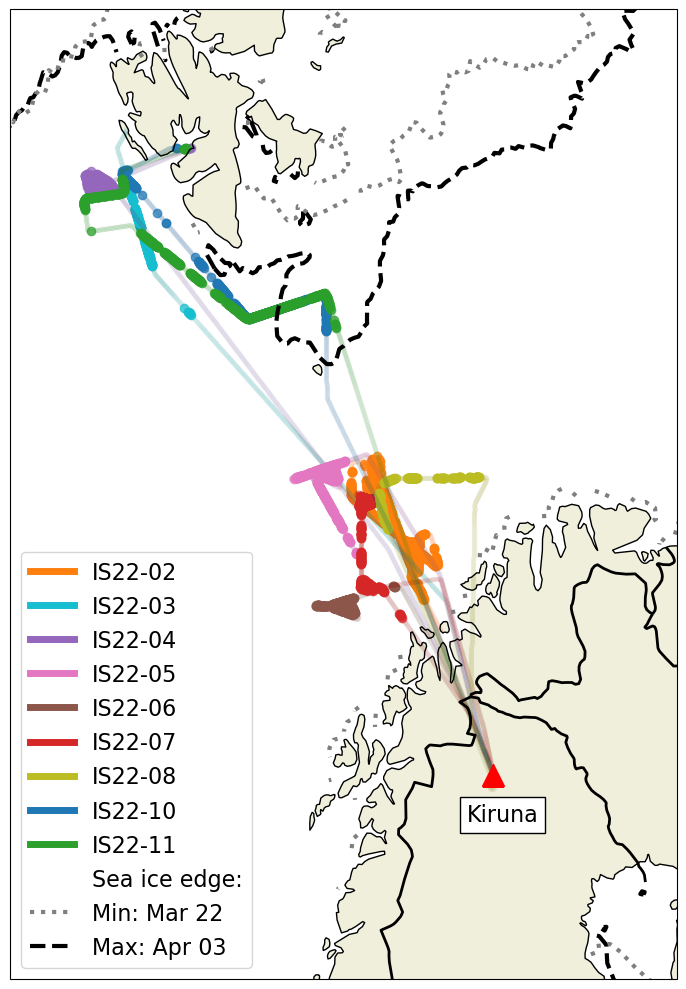

In [19]:
# Plot: incloud observations per flight
savefile = save_path + f'Incloud_pr_flight_{sample_rate}s_{th_method}{extr_txt}.png'

plot_flight_obs(ds, ds_incloud,sic_max_ds, sic_min_ds, obs=True,savefile=savefile)

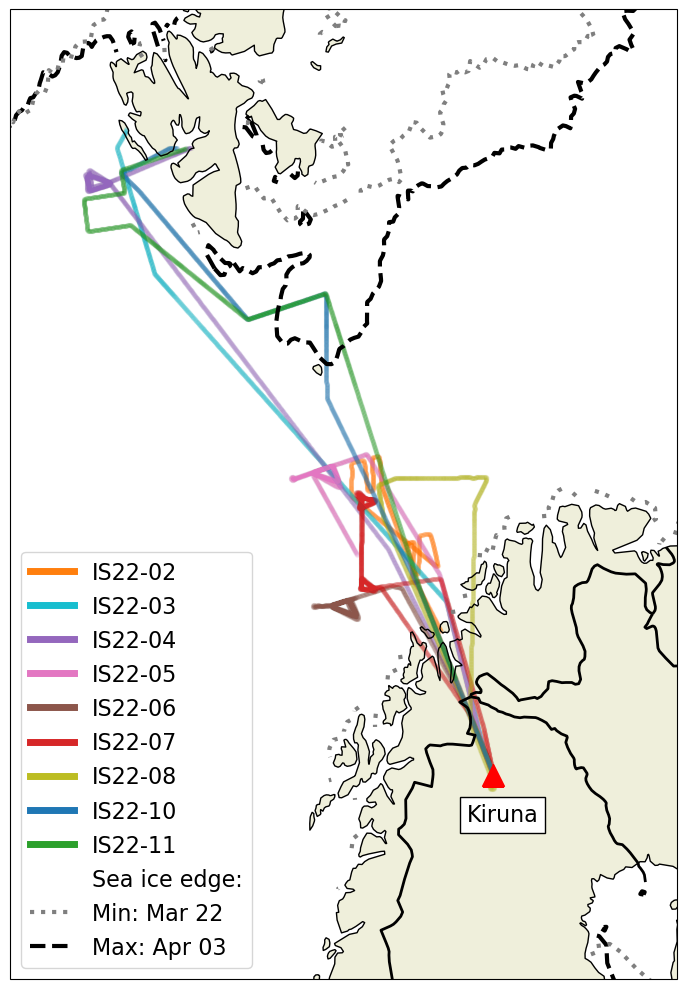

In [20]:
# Plot: flights from ISLAS campaign in use with sea ice concentration
savefile = save_path + f'Islas_flights_{sample_rate}s_{th_method}{extr_txt}.png'
plot_flight_obs(ds, ds_incloud,sic_max_ds, sic_min_ds, obs=False,savefile=savefile)

In [21]:
# Create dataframe for visualizing available observations with Heatmap
# - number of observations per altitude bin vs. distance bin

def reorg_heatmap_df(data):
     # reorganize data before plotting heatmap
    # - turn into dataframe - unstack to get correct array structure  
    new_df = data.to_dataframe().unstack()
    
    # - transpose to get altitude on y-axis - reset index and drop outer index(base_time)
    new_df = new_df.T.reset_index(level=0, drop = True)
    # -  make sure all possible bins for y-axis is representedented, 
    if 'altitude_bin' in data.coords:
          new_df = new_df.reindex(bin_labels, fill_value=0).iloc[::-1] # fill with 0 - reverse order of altitudes
          new_df = new_df.fillna(0) # set nan to 0 (for easier plot management)
          new_df = new_df.astype(int) # set the count to int
    elif 'temp_bin' in data.coords:
          new_df = new_df.reindex(temp_bins, fill_value=0) # fill with 0
          new_df = new_df.fillna(0) # set nan to 0 (for easier plot management)

    return new_df
   


In [22]:
def create_distribution_df(ds, xbins, ybins, statistic,val, mask = ""):
    # function to prepare the selected data (ds) to create heatmaps with x-axis xbins and y-axis ybins
    # REQUIRES: 
    #   -- pandas
    # INPUT: 
    #   -- ds: selected dataset(xarray)
    #   -- xbins: string indicating coordinate in ds to use for x-axis
    #   -- ybins: string indicating coordinate in ds to use for y-axis
    #   -- statistic: what should be calculated (count, mean, std)
    #   -- val: number of digits to display
    #   -- mask: mask to hide in cloud values
    # RETURNS: 
    #   -- dist_df: dataframe containing the distribution over the xbin/ybin
    #   -- incloud_mask: mask where no observations

    import pandas as pd

    # get the minimum distance (over sea ice)
    np.nanmin(ds_incloud.distance_from_ice.values)

    # Dataset grouped by xbins
    data_groupedx = ds.groupby(xbins)

    if statistic=='count':
        data_groupedxy = data_groupedx.map(lambda group: group.groupby(ybins).count())
    elif statistic=='mean':
        data_groupedxy = data_groupedx.map(lambda group: group.groupby(ybins).mean())
    elif statistic=='std':
        data_groupedxy = data_groupedx.map(lambda group: group.groupby(ybins).std())
    elif statistic =='max':
        data_groupedxy = data_groupedx.map(lambda group: group.groupby(ybins).max())
    else:
        print(f"Statistic {statistic} not available, use 'count','max', 'mean' or 'std'")
        return
    
    #reorganize data
    dist_df = reorg_heatmap_df(data_groupedxy)

    # round to val number of digits
    dist_df.round(decimals=val)

    # rename first column name to the furthest distance over sea ice
    dist_df.columns.values[0]=np.nanmin(ds_incloud.distance_from_ice.values)

    if statistic=='count':
        incloud_mask = dist_df == 0 # create the in-cloud mask
        return dist_df, incloud_mask
    else:
        if isinstance(mask, pd.DataFrame):
            dist_df = dist_df.mask(mask,np.nan)
            return dist_df
        else:
            print('No masking of incloud values have been made, (mask not available)')
            return dist_df
        
    
            
    

# Number of observations and flights

In [23]:
# calculations for number of observations

# counts per distance-altitude
count_df, incloud_mask = create_distribution_df(ds_incloud['base_time'],'dist_bin','altitude_bin','count',val=0) # count all in cloud observations
count_rel_df, m = create_distribution_df(ds_relevant['base_time'],'dist_bin', 'altitude_bin', 'count',val=0) # count all observations

# hide 0 observations by setting themm to na
count_df.replace(0,np.nan, inplace=True)

# the df includes empthy rows on top, trop the two first ones for cleaner plots
count_df = count_df.iloc[2:]
count_rel_df = count_rel_df.iloc[2:]

# Calculating the percentage of total observations per category that is in cloud:
dist_df = ((count_df/count_rel_df)*100)

# repeat for brown and francis
# counts per distance-altitude
count_bf_df, incloud_mask = create_distribution_df(ds_incloud_bf['base_time'],'dist_bin','altitude_bin','count',val=0) # count all in cloud observations
count_rel_bf_df, m = create_distribution_df(ds_relevant_bf['base_time'],'dist_bin', 'altitude_bin', 'count',val=0) # count all observations

# hide 0 observations by setting themm to na
count_bf_df.replace(0,np.nan, inplace=True)

# the df includes empthy rows on top, trop the two first ones for cleaner plots
count_bf_df = count_bf_df.iloc[2:]
count_rel_bf_df = count_rel_bf_df.iloc[2:]

# Calculating the percentage of total observations per category that is in cloud:
dist_bf_df = ((count_bf_df/count_rel_bf_df)*100)


# counts per distance-altitude evans incloud
m_evans_count_df, m_evans_incloud_mask = create_distribution_df(ds_incloud_m_evans['base_time'],'dist_bin','altitude_bin','count',val=0) # count all in cloud observations
# hide 0 observations by setting themm to na
m_evans_count_df.replace(0,np.nan, inplace=True)

# Calculating the percentage of total observations per category that is in cloud:
m_evans_dist_df = ((m_evans_count_df/count_rel_df)*100) 


In [24]:
count_df

dist_bin,-125,0,200,400,600,800
altitude_bin,,,,,,
4950.0,NaN,NaN,NaN,NaN,1.0,NaN
4650.0,NaN,NaN,NaN,NaN,6.0,NaN
4350.0,NaN,NaN,NaN,NaN,NaN,144.0
4050.0,NaN,NaN,NaN,NaN,NaN,NaN
3750.0,NaN,5.0,NaN,NaN,NaN,34.0
3450.0,NaN,3.0,NaN,NaN,NaN,21.0
3150.0,NaN,1.0,NaN,NaN,NaN,22.0
2850.0,NaN,NaN,NaN,NaN,NaN,424.0
2550.0,NaN,NaN,NaN,4.0,NaN,28.0


In [25]:
m_evans_count_df

dist_bin,-125,0,200,400,600,800
altitude_bin,,,,,,
5550.0,NaN,NaN,NaN,NaN,NaN,NaN
5250.0,NaN,NaN,NaN,NaN,NaN,NaN
4950.0,NaN,NaN,NaN,NaN,5.0,NaN
4650.0,NaN,NaN,NaN,NaN,9.0,NaN
4350.0,NaN,NaN,NaN,NaN,NaN,164.0
4050.0,NaN,NaN,NaN,NaN,NaN,12.0
3750.0,NaN,8.0,NaN,NaN,NaN,42.0
3450.0,NaN,10.0,NaN,NaN,NaN,21.0
3150.0,NaN,10.0,NaN,NaN,NaN,22.0


Plot is saved to: /home/ninalar/Documents/MC2/procIslasMicrophy-1/save_images/sample_rate/new/dist200/Perc_incloud_alt_sic_dist200_sr5.png


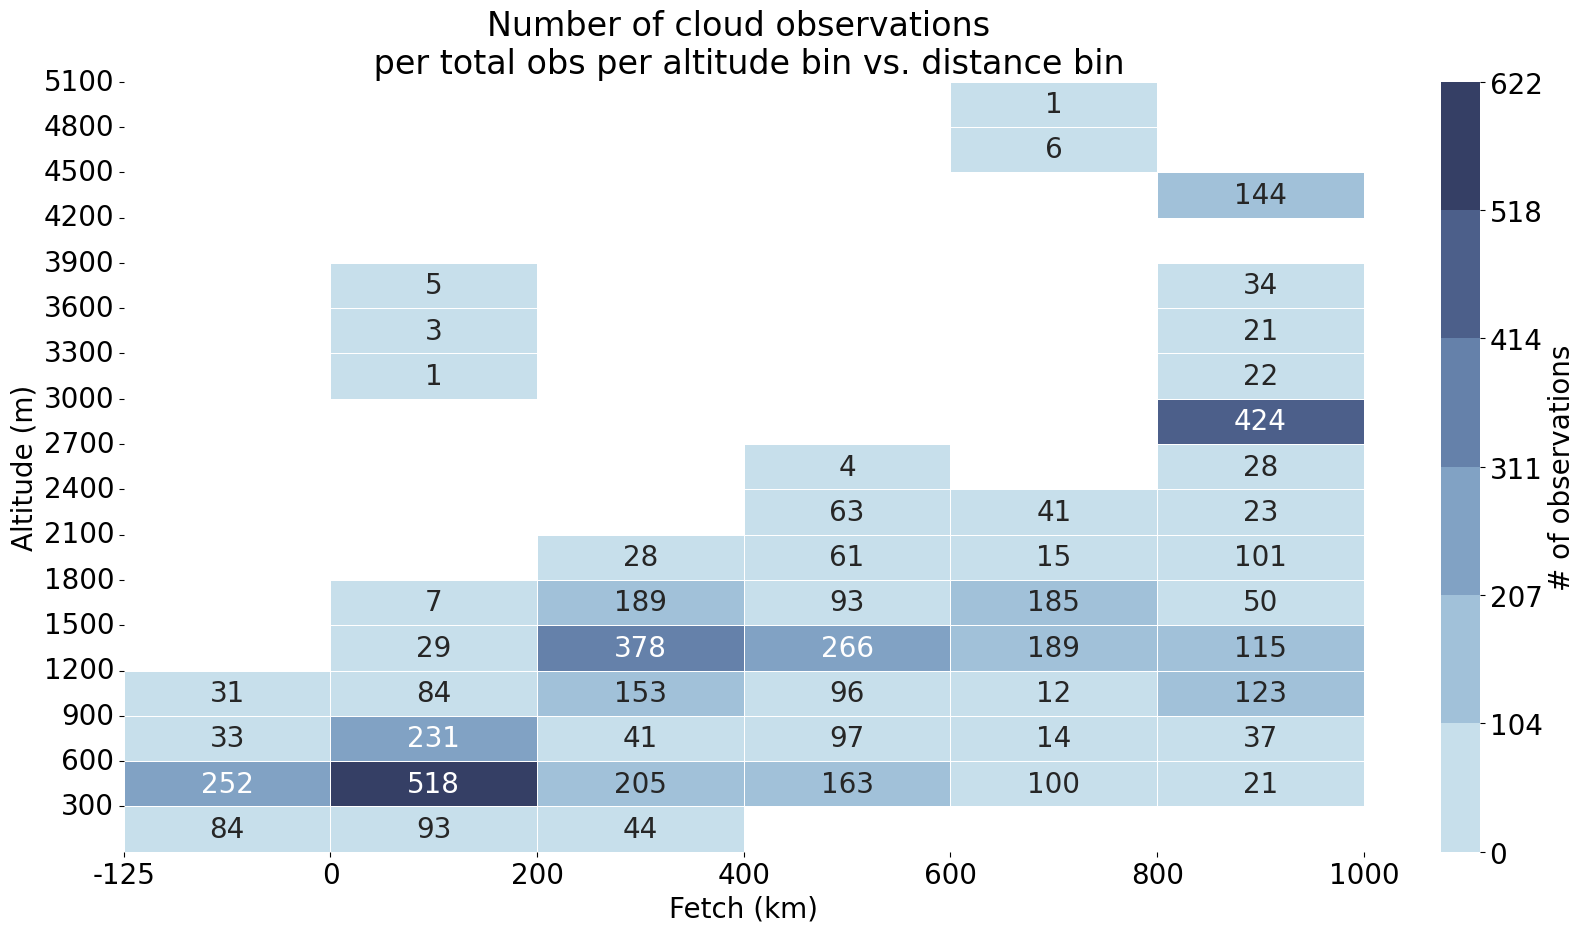

In [26]:
# Heatplot of percentage of observations that where in-cloud
# y-axis: Altitude

obs_labels_dict = {
    'xax_lab':'Fetch (km)',
    'yax_lab':'Altitude (m)',
    'cbar_lab':'# of observations'
}

savefile = save_path + f'Perc_incloud_alt_sic_{d_text}_sr{sample_rate}.png'



fig,ax = plt.subplots(figsize=(20, 10))

plot_heatmap_ax(count_df, obs_labels_dict, ax, mask_na= True, val=0, annot_df = count_df, counts=False, ss=20, ncol=5, v_extend=False, altitude_bins=altitude_bins)

ax.set_title("Number of cloud observations \n per total obs per altitude bin vs. distance bin")

#plt.savefig(savefile, bbox_inches='tight')
print(f'Plot is saved to: {savefile}')

plt.show()


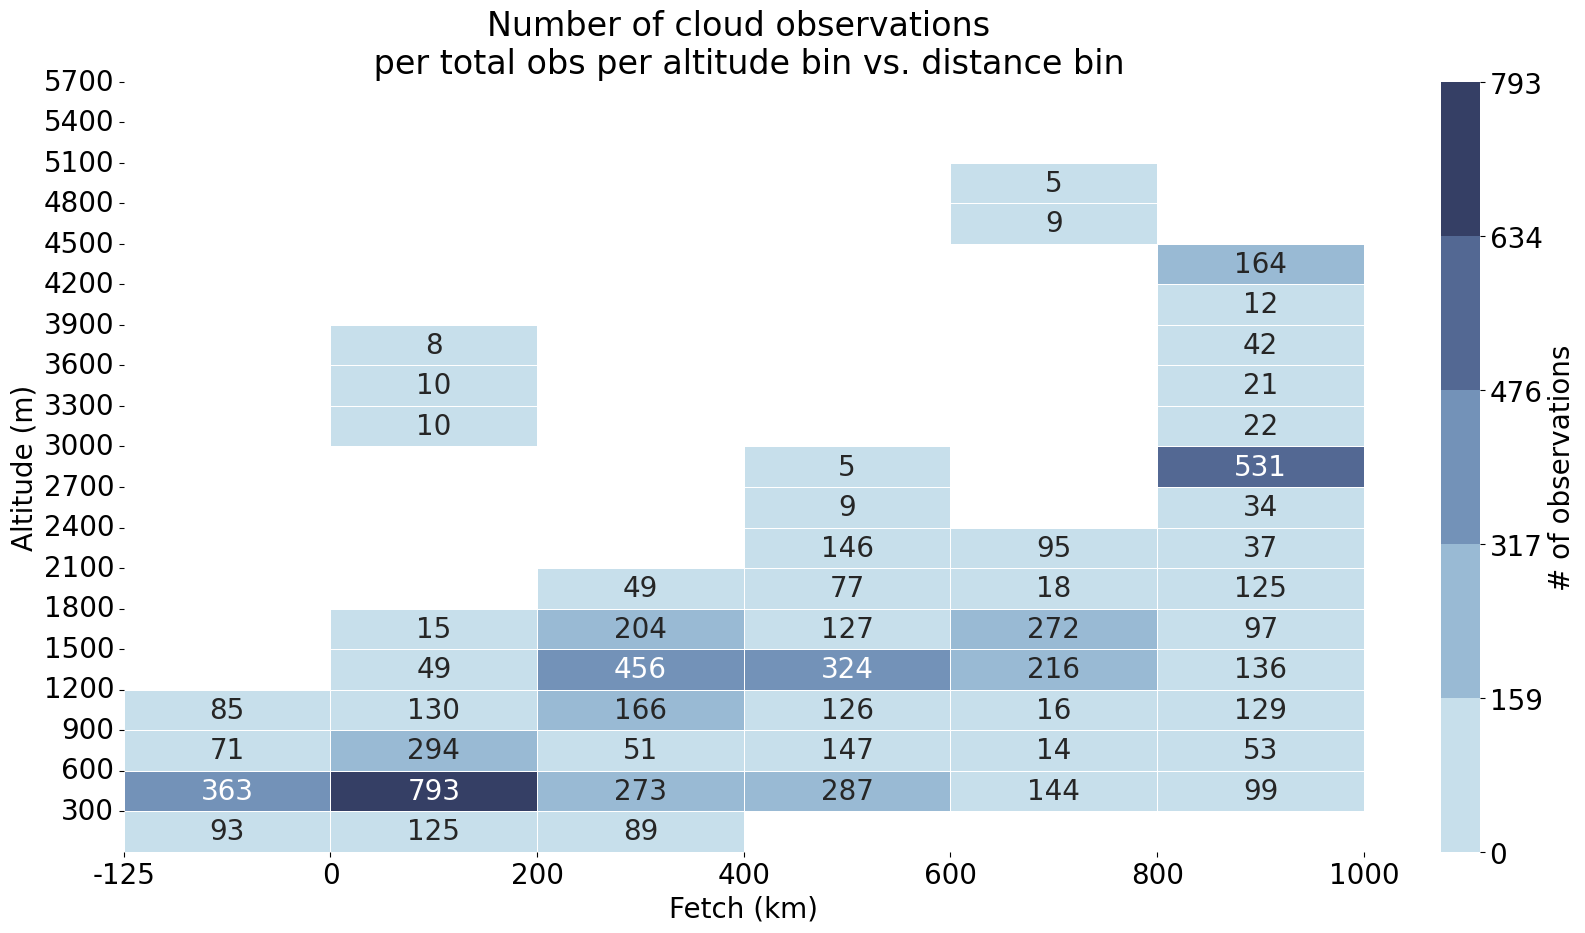

In [27]:
# Heatplot of percentage of observations that where in-cloud
# y-axis: Altitude

obs_labels_dict = {
    'xax_lab':'Fetch (km)',
    'yax_lab':'Altitude (m)',
    'cbar_lab':'# of observations'
}

#savefile = save_path + f'Perc_incloud_alt_sic_{d_text}_sr{sample_rate}.png'

# hide 0 observations by setting themm to na
m_evans_count_df.replace(0,np.nan, inplace=True)

fig,ax = plt.subplots(figsize=(20, 10))

plot_heatmap_ax(m_evans_count_df, obs_labels_dict, ax, mask_na= True, val=0, annot_df = m_evans_count_df, counts=False, ss=20, ncol=5, v_extend=False, altitude_bins=altitude_bins)

ax.set_title("Number of cloud observations \n per total obs per altitude bin vs. distance bin")

#plt.savefig(savefile, bbox_inches='tight')
#print(f'Plot is saved to: {savefile}')

plt.show()

In [28]:
# To remove the observations where there is less than 10 observations in a distnace-altitude box
# get the locations of the values less than 0 in count_df
loc_low = count_df[count_df <= 10].stack().index.tolist()

for i in loc_low:
    # for each location pair, find corresponding values in ds_incloud and drop these
    dist = i[1]
    alt = i[0]
    #print(alt)
    con1 = ds_incloud['altitude_bin']==alt
    con2 = ds_incloud['dist_bin']==dist
    comb_con = con1 & con2

    ds_incloud = ds_incloud.where(~comb_con, drop=True)
    #print(sel_val.dist_bin.values)
    #print('-----')


# recalculate count_df based on the new incloud values
count_df, incloud_mask = create_distribution_df(ds_incloud['base_time'],'dist_bin','altitude_bin','count',val=0) # count all in cloud observations
# hide 0 observations by setting themm to na
count_df.replace(0,np.nan, inplace=True)

# the df includes empthy rows on top, trop the two first ones for cleaner plots
count_df = count_df.iloc[2:]

# repeat for Brown dataset
# get the locations of the values less than 0 in count_df
loc_low_bf = count_bf_df[count_bf_df <= 10].stack().index.tolist()

for i in loc_low_bf:
    # for each location pair, find corresponding values in ds_incloud and drop these
    dist = i[1]
    alt = i[0]
    #print(alt)
    con1 = ds_incloud_bf['altitude_bin']==alt
    con2 = ds_incloud_bf['dist_bin']==dist
    comb_con = con1 & con2

    ds_incloud_bf = ds_incloud_bf.where(~comb_con, drop=True)
    #print(sel_val.dist_bin.values)
    #print('-----')


# recalculate count_df based on the new incloud values
count_bf_df, incloud_mask = create_distribution_df(ds_incloud_bf['base_time'],'dist_bin','altitude_bin','count',val=0) # count all in cloud observations
# hide 0 observations by setting themm to na
count_bf_df.replace(0,np.nan, inplace=True)

# the df includes empthy rows on top, trop the two first ones for cleaner plots
count_bf_df = count_bf_df.iloc[2:]

# same for evans incloud
loc_low_e = m_evans_count_df[m_evans_count_df <= 10].stack().index.tolist()

for i in loc_low_e:
    # for each location pair, find corresponding values in ds_incloud and drop these
    dist = i[1]
    alt = i[0]
    #print(alt)
    con1 = ds_incloud_m_evans['altitude_bin']==alt
    con2 = ds_incloud_m_evans['dist_bin']==dist
    comb_con = con1 & con2

    ds_incloud_m_evans = ds_incloud_m_evans.where(~comb_con, drop=True)
    #print(sel_val.dist_bin.values)
    #print('-----')


# recalculate count_df based on the new incloud values
m_evans_count_df, m_evans_incloud_mask = create_distribution_df(ds_incloud_m_evans['base_time'],'dist_bin','altitude_bin','count',val=0) # count all in cloud observations
# hide 0 observations by setting themm to na
m_evans_count_df.replace(0,np.nan, inplace=True)

In [29]:
#count_df
count_bf_df

dist_bin,-125,0,200,400,600,800
altitude_bin,,,,,,
4950.0,NaN,NaN,NaN,NaN,NaN,NaN
4650.0,NaN,NaN,NaN,NaN,NaN,NaN
4350.0,NaN,NaN,NaN,NaN,NaN,143.0
4050.0,NaN,NaN,NaN,NaN,NaN,NaN
3750.0,NaN,NaN,NaN,NaN,NaN,34.0
3450.0,NaN,NaN,NaN,NaN,NaN,21.0
3150.0,NaN,NaN,NaN,NaN,NaN,22.0
2850.0,NaN,NaN,NaN,NaN,NaN,416.0
2550.0,NaN,NaN,NaN,NaN,NaN,28.0


In [30]:
print(f'Total min: {count_df[count_df>0].min().min()}')
print(f'Total max: {count_df.values.max()}')
print(f'Total mean: {count_df.values.mean()}')
count_df

Total min: 12.0
Total max: nan
Total mean: nan


dist_bin,-125,0,200,400,600,800
altitude_bin,,,,,,
4950.0,NaN,NaN,NaN,NaN,NaN,NaN
4650.0,NaN,NaN,NaN,NaN,NaN,NaN
4350.0,NaN,NaN,NaN,NaN,NaN,144.0
4050.0,NaN,NaN,NaN,NaN,NaN,NaN
3750.0,NaN,NaN,NaN,NaN,NaN,34.0
3450.0,NaN,NaN,NaN,NaN,NaN,21.0
3150.0,NaN,NaN,NaN,NaN,NaN,22.0
2850.0,NaN,NaN,NaN,NaN,NaN,424.0
2550.0,NaN,NaN,NaN,NaN,NaN,28.0


In [31]:
# calculate the in-cloud percentage

count_rel_df[[-125,0,200,400,600,800]]

dist_bin,-125,0,200,400,600,800
altitude_bin,,,,,,
4950.0,0,0,0,0,5,0
4650.0,0,0,0,1,28,0
4350.0,0,0,0,19,35,164
4050.0,0,21,0,15,35,12
3750.0,0,34,0,20,32,42
3450.0,0,40,3,23,33,21
3150.0,16,97,13,34,19,22
2850.0,25,41,14,41,10,550
2550.0,33,29,12,28,3,41


In [32]:
# ---- Get the distribution of the observations all, incloud and percentage

# set colorbar options
ticks = [0,100,200,300,400,500] # ticks to set on colorbar
bounds = [0,1,100,200,300,400,500] # boundaries for colors in colorbar (to set 0 to white)


# hide 0 observations by setting them to na
count_rel_df.replace(0,np.nan, inplace=True)
count_df.replace(0,np.nan, inplace=True)

# calculate the percentage of incloud vs total
count_perc_df = np.round((count_df/count_rel_df[[-125,0,200,400,600,800]])*100,0)
count_perc_t_df = count_perc_df.map(lambda x: f"({int(x)}%)" if pd.notna(x) else x) # turn into properly formatted text
count_t_df = count_df.map(lambda x: f"{int(x)}  " if pd.notna(x) else x) # turn into properly formatted text

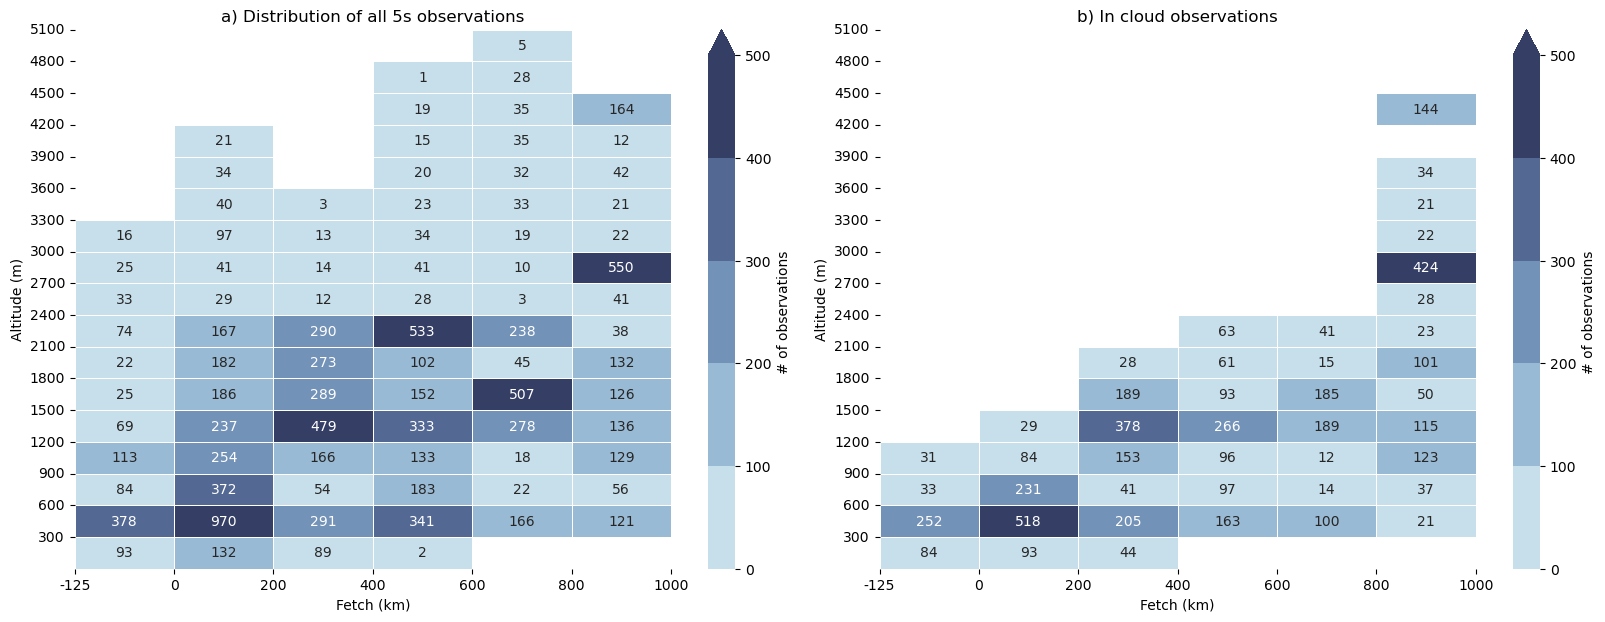

In [33]:
# ---- Plot the total and the in-cloud distributions 
fig, ax = plt.subplots(1,2, figsize=(20, 7))
plt.subplots_adjust(wspace=0.08)

# Double plot of the cloud distribution

# Total number of observations (5s)
plot_heatmap_ax(count_rel_df[[-125,0,200,400,600,800]], obs_labels_dict, ax[0], mask_na=True, val=0, annot_df = count_rel_df[[-125,0,200,400,600,800]],counts=False,ncol=5, v_extend=500, altitude_bins=altitude_bins)
ax[0].set_title('a) Distribution of all 5s observations')
# in-cloud
plot_heatmap_ax(count_df, obs_labels_dict, ax[1], mask_na=True, val=0, annot_df = count_df,counts=True,ncol=5, v_extend=500, altitude_bins=altitude_bins)
ax[1].set_title('b) In cloud observations')


savefile = save_path + f'obs_count_incloud_count_{d_text}_{sample_rate}s.png'
plt.savefig(savefile, bbox_inches='tight')

Plot is saved to: /home/ninalar/Documents/MC2/procIslasMicrophy-1/save_images/sample_rate/new/dist200/Incloud_count_dist200_sr5.png


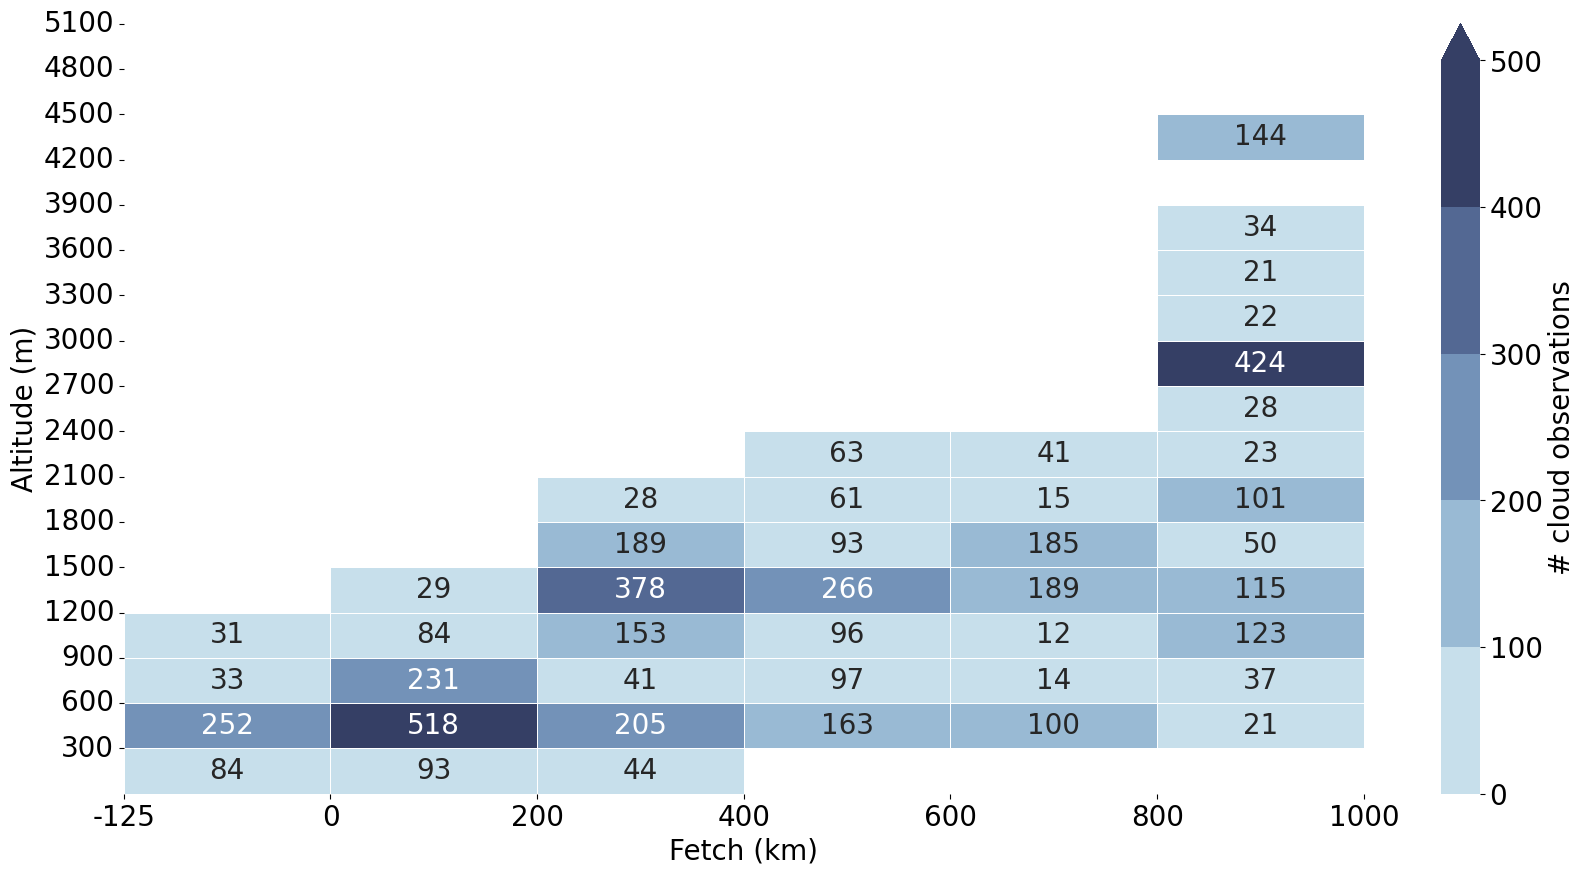

Sum of observations per 200km distance bin: dist_bin
-125     400.0
 0       955.0
 200    1038.0
 400     839.0
 600     556.0
 800    1143.0
dtype: float64


In [34]:
# in lower level mixed phase cloud observations

# Heatplot of percentage of observations that where in-cloud
# y-axis: Altitude

incloud_labels_dict = {
    'xax_lab':'Fetch (km)',
    'yax_lab':'Altitude (m)',
    'cbar_lab':'# cloud observations'
}

savefile = save_path + f'Incloud_count_{d_text}_sr{sample_rate}.png'

fig,ax = plt.subplots(figsize=(20, 10))
plot_heatmap_ax(count_df, incloud_labels_dict, ax, mask_na= True, val=0, annot_df = count_df, counts=False, ss=20,ncol=5, v_extend=500, altitude_bins=altitude_bins)
#plot_heatmap_ax(count_df, incloud_labels_dict, ax, mask_na= True, val=0, annot_df = count_perc_df, counts=False, ss=20,ncol=5, v_extend=500)

#ax.set_title("Number of cloud observations in lower level clouds \n per total obs per altitude bin vs. distance bin \n (percentage of in-cloud observations vs total observations)")

plt.savefig(savefile, bbox_inches='tight')
print(f'Plot is saved to: {savefile}')

plt.show()


# sum each colum to get the number of observations per distance bin
col_sum = count_df.sum()

print(f'Sum of observations per {dist_bin_size}km distance bin: {col_sum}')

Plot is saved to: /home/ninalar/Documents/MC2/procIslasMicrophy-1/save_images/sample_rate/new/dist200/islasid_alt_dist200_5s.png


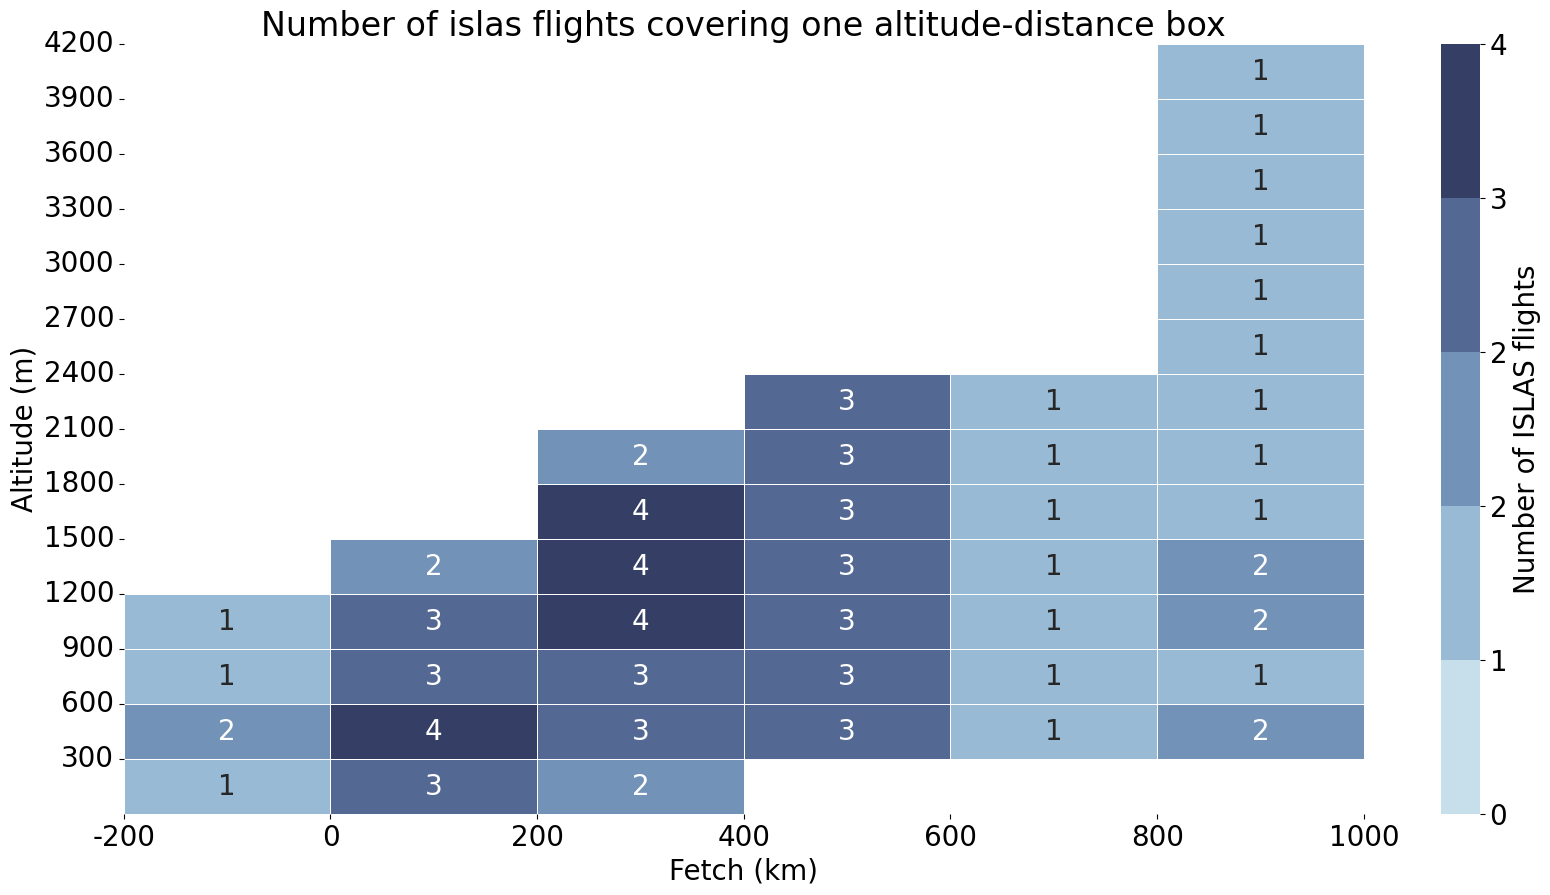

In [35]:
# Heatplot of Number of flights 
# y-axis: altitude
# id_count_df

# count of flights per box
id_df = ds_incloud['islasid'].to_dataframe()
grouped_df = id_df.groupby('dist_bin')  # Groupby dist_bin
id_count_df = grouped_df.apply(lambda group: group.groupby('altitude_bin')['islasid'].nunique(), include_groups=False).iloc[:,0]

id_count_df = id_count_df.unstack()
# - transpose to get altitude on y-axis - reset index and drop outer index(base_time)
id_count_df = id_count_df.T
# flip axis
id_count_df = id_count_df.iloc[::-1] #

number_labels_dict = {
    'xax_lab':'Fetch (km)',
    'yax_lab':'Altitude (m)',
    'cbar_lab':"Number of ISLAS flights"
}

savefile = save_path + f'islasid_alt_{d_text}_{sample_rate}s.png'

fig,ax = plt.subplots(figsize=(20, 10))

plot_heatmap_ax(id_count_df, number_labels_dict, ax, mask_na= True, val=0, annot_df = id_count_df, counts=False, ss=20,ncol=5, add_sections=True, altitude_bins=altitude_bins)

ax.set_title("Number of islas flights covering one altitude-distance box")

plt.savefig(savefile, bbox_inches='tight')
print(f'Plot is saved to: {savefile}')

plt.show()


## TWC

In [36]:
# TWC
twc_var = 'TWC_H10'

data_groupedx = ds_incloud[twc_var].groupby('dist_bin')
data_groupedxy = data_groupedx.map(lambda group: group.groupby('altitude_bin').mean())
twc_mean_df = data_groupedxy.to_dataframe().unstack() 
twc_mean_df = twc_mean_df.T.reset_index(level=0, drop = True) # - transpose to get altitude on y-axis - reset index and drop outer index(base_time)
twc_mean_df = twc_mean_df.reindex(bin_labels, fill_value=np.nan).iloc[::-1] # fill with 0 - reverse order of altitudes

# the df includes empthy rows on top, trop the two first ones for cleaner plots
twc_mean_df = twc_mean_df.iloc[2:]

# evans incloud
e_data_groupedx = ds_incloud_m_evans[twc_var].groupby('dist_bin')
e_data_groupedxy = e_data_groupedx.map(lambda group: group.groupby('altitude_bin').mean())
e_twc_mean_df = e_data_groupedxy.to_dataframe().unstack() 
e_twc_mean_df = e_twc_mean_df.T.reset_index(level=0, drop = True) # - transpose to get altitude on y-axis - reset index and drop outer index(base_time)
e_twc_mean_df = e_twc_mean_df.reindex(bin_labels, fill_value=np.nan).iloc[::-1] # fill with 0 - reverse order of altitudes


Plot is saved to: /home/ninalar/Documents/MC2/procIslasMicrophy-1/save_images/sample_rate/new/dist200/TWC_heatmap_dist200_5s.png


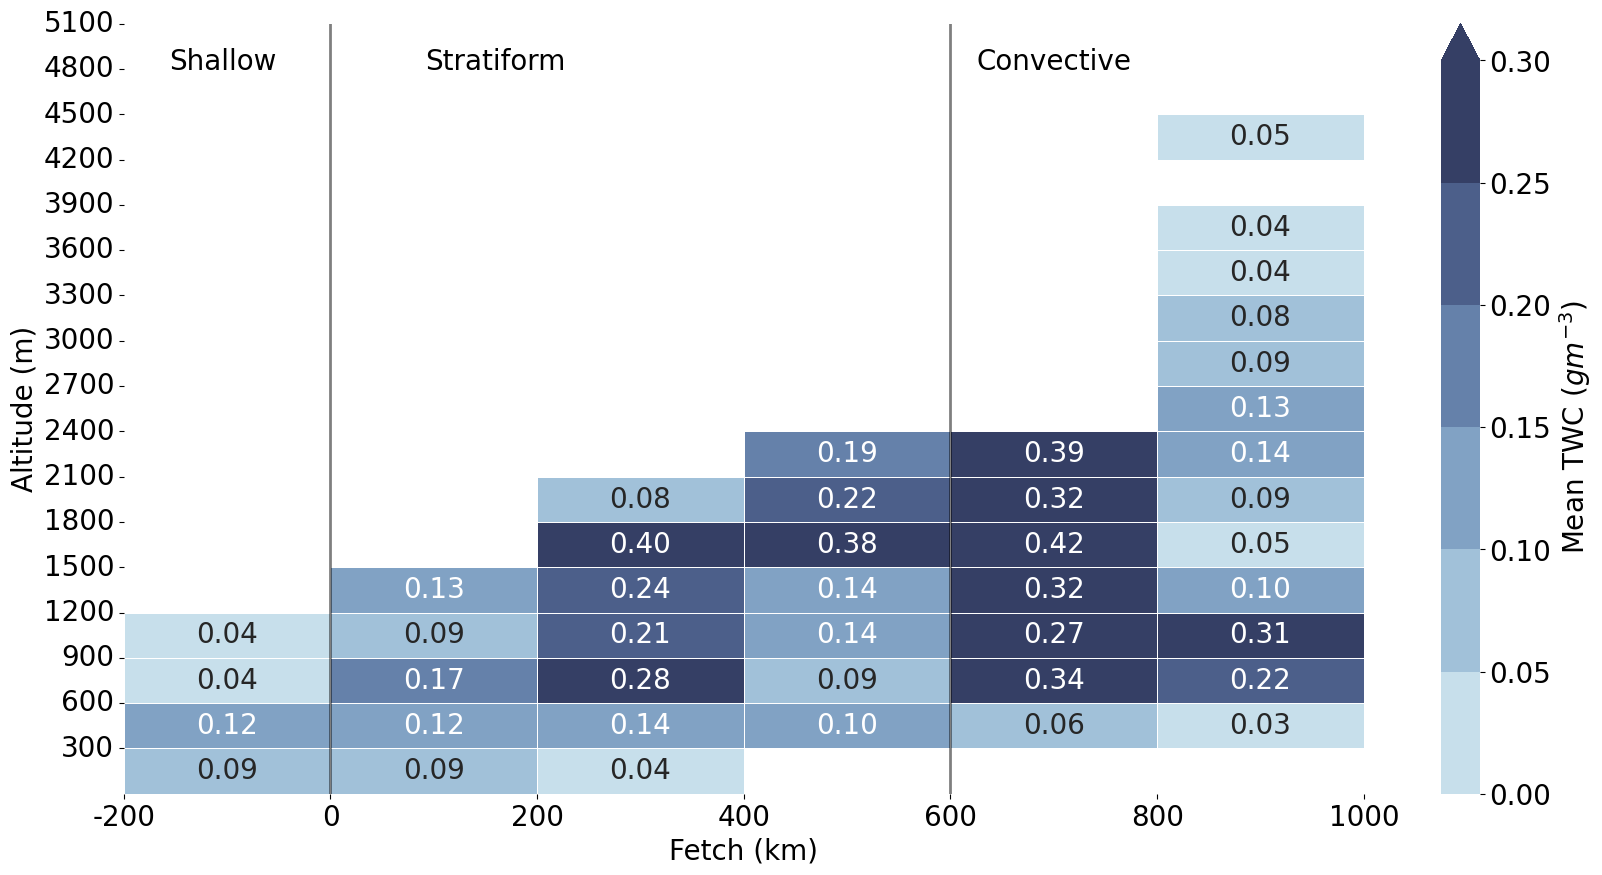

In [37]:
# Heatplot of TWC (IWC100 + LWC)
# y-axis: altitude
# cip_size_mean_df,cip_size_std_df

twc_lab_dict = {
    'xax_lab':'Fetch (km)',
    'yax_lab':'Altitude (m)',
    'cbar_lab':'Mean TWC ($gm^{-3}$)'
}

savefile = save_path + f'TWC_heatmap_{d_text}_{sample_rate}s.png'

fig,ax = plt.subplots(figsize=(20, 10))

plot_heatmap_ax(twc_mean_df, twc_lab_dict, ax, mask_na= True, val=2, annot_df = twc_mean_df, counts=False, ss=20,ncol=6, v_extend=0.3, altitude_bins=altitude_bins)

#temp_steps(ax,tb,th20,th10) # add temperature lines -10 and -20
add_sect(ax,fs=20) # add lines and text for sections

plt.savefig(savefile, bbox_inches='tight')
print(f'Plot is saved to: {savefile}')

plt.show()

# In cloud temperature

In [38]:
# add temperature to other plots functions

def fmt(x):
    # function to add temp unit
    s = f"{x:.0f}"
    return f"{s} $^\circ$C"

def temp_contour(ax, temp_mean_df):
    # Add temp contour lines for -10 and -20 based on the mean temp values per bin

    # Prepare temperature observations for contour plot
    X,Y = np.meshgrid(temp_mean_df.columns.values, temp_mean_df.index.values)
    Z = temp_mean_df.values


    #label_locations = [(700,2400),(800,600)]
    temp_c = ax.contour(X, Y, Z, levels=[-20,-10], colors='Red')

    ax.set_xlim(-200,1000) # set limits to match the histogram plots
    ax.clabel(temp_c, temp_c.levels,inline=True, fmt=fmt, fontsize=20)

    return

def temp_steps(ax,tb,th20,th10, lw=4, leg=True, col = 'k'):
    # Create step plots indicating where temperature exceeds -20 and -10
    
    ax_t = fig.add_axes(ax.get_position(), frameon=False) # create new axes

    # create step plots for T=-10 and T=-20
    #ax_t.step(tb, th20, where='post', color=col, linewidth=lw,linestyle='--', label=u'-20\u00B0C')
    #ax_t.step(tb, th10, where='post', color=col, linewidth=lw,linestyle=':', label=u'-10\u00B0C')
    ax_t.step(tb, th20, where='post', color=col, linewidth=lw, dashes = [4,4], gapcolor = 'w', label=u'-20\u00B0C')
    ax_t.step(tb, th10, where='post', color=col, linewidth=lw, dashes = [2,2], gapcolor = 'w', label=u'-10\u00B0C')

    # set limits to match the histogram plots
    ax_t.set_xlim(-200,1000) 
    ax_t.set_ylim(0,5100)

    # set axes invisible
    ax_t.axes.get_xaxis().set_visible(False)
    ax_t.axes.get_yaxis().set_visible(False)

    # define legend
    if leg==True:
        ax_t.legend(loc='center left', framealpha=1)

    return

def T_th_array(df, th):
    # find the heights in a dataframw where the mean T is above a threshold
    # return array of heights

    # find heights with list comprehension
    # add 150 to get top bin edge
    th = np.array([(df[col] > th).idxmax() for col in df.columns]).astype(int)+150
    # duplicate last value to cover complete plot for step plots
    th =np.append(th, th[-1])
    # if values larger than 5000 it hould be 0
    th[th>5000]=0

    return th



Plot is saved to: /home/ninalar/Documents/MC2/procIslasMicrophy-1/save_images/sample_rate/new/dist200/temp_incloud_alt_dist200_5s.png


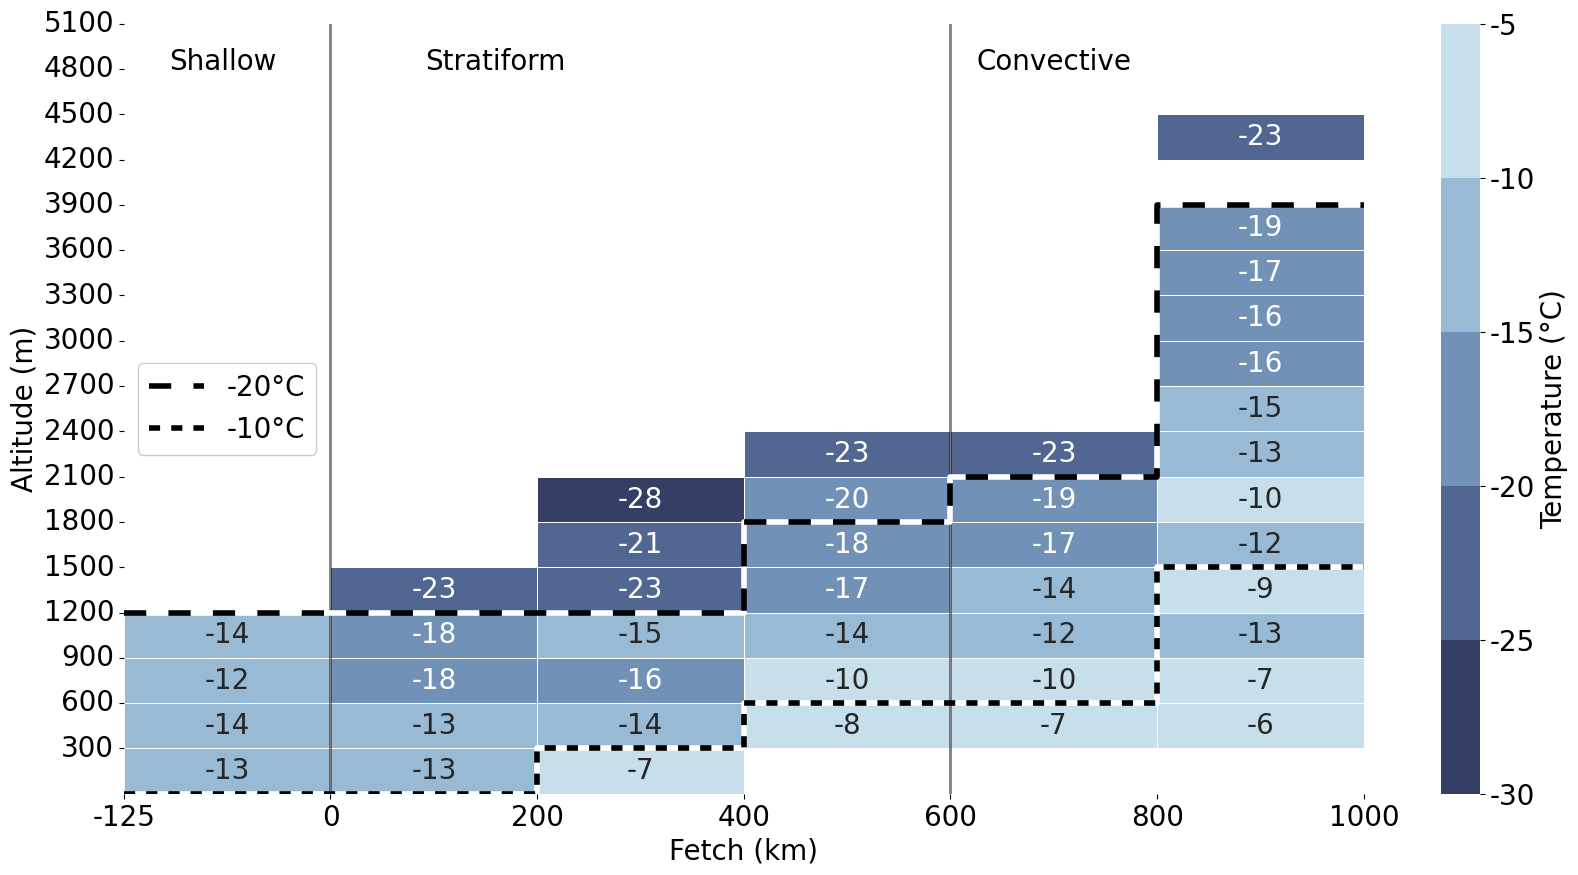

In [39]:
# Heatplot of mean temperature in-cloud
# y-axis: altitude
# temp_mean_df, temp_std_df,

temp_mean_df = create_distribution_df(ds_incloud['T'],'dist_bin','altitude_bin','mean',val=0, mask=incloud_mask)
temp_std_df = create_distribution_df(ds_incloud['T'],'dist_bin','altitude_bin','std',val=0, mask=incloud_mask)

# drop the two topmost empty rows of df for cleaner plots
temp_mean_df = temp_mean_df.iloc[2:]
temp_std_df = temp_std_df.iloc[2:]

# Get values for plotting -20 and -10 temperature lines with temp_steps:
tb = np.unique(ds_incloud.dist_bin.values) # get the distance bins
tb = np.append(tb,tb[-1]+dist_bin_size) # for step plot one more bin must be added to cover complete plot
th10=T_th_array(temp_mean_df,-10)
th20=T_th_array(temp_mean_df,-20)



t_labels_dict = {
    'xax_lab':'Fetch (km)',
    'yax_lab':'Altitude (m)',
    'cbar_lab':u'Temperature (\u00B0C)'
}

savefile = save_path + f'temp_incloud_alt_{d_text}_{sample_rate}s.png'

fig,ax = plt.subplots(figsize=(20, 10))

plot_heatmap_ax(temp_mean_df, t_labels_dict, ax, mask_na= True, val=0, annot_df = temp_mean_df, counts=False, ss=20, ncol=5,ticks = np.arange(-30, 0, 5),reverse=True,v_extend=-5, altitude_bins=altitude_bins)

ss=20
temp_steps(ax,tb,th20,th10) # add temperature lines -10 and -20
add_sect(ax,fs=ss) # add lines and text for sections

#ax.set_title("Mean incloud temperature($^\circ C$), with standard deviation")

plt.savefig(savefile, bbox_inches='tight')
print(f'Plot is saved to: {savefile}')

plt.show()

# SLF

In [40]:
slf_var = 'SLF_H10'

slf_mean_df = create_distribution_df(ds_incloud[slf_var],'dist_bin','altitude_bin','mean',val=0, mask=incloud_mask)

# adjust for plotting: remove the two topmost empthy altitude layers
slf_mean_df = slf_mean_df.iloc[2:]
print(slf_mean_df)


# evans_incloud
e_slf_mean_df = create_distribution_df(ds_incloud_m_evans['SLF_H10'],'dist_bin','altitude_bin','mean',val=0, mask=m_evans_incloud_mask)

dist_bin      -125   0     200   400   600   800
altitude_bin                                    
4950.0         NaN   NaN   NaN   NaN   NaN   NaN
4650.0         NaN   NaN   NaN   NaN   NaN   NaN
4350.0         NaN   NaN   NaN   NaN   NaN   0.0
4050.0         NaN   NaN   NaN   NaN   NaN   NaN
3750.0         NaN   NaN   NaN   NaN   NaN   0.0
3450.0         NaN   NaN   NaN   NaN   NaN   0.0
3150.0         NaN   NaN   NaN   NaN   NaN   0.0
2850.0         NaN   NaN   NaN   NaN   NaN   0.0
2550.0         NaN   NaN   NaN   NaN   NaN   0.0
2250.0         NaN   NaN   NaN  22.0  17.0   1.0
1950.0         NaN   NaN  52.0  33.0   7.0  11.0
1650.0         NaN   NaN  52.0  29.0   8.0   3.0
1350.0         NaN  40.0  18.0  16.0  30.0   9.0
1050.0         2.0  13.0  20.0  15.0  24.0  48.0
750.0          0.0  14.0   8.0  11.0   1.0  10.0
450.0          3.0   4.0   0.0   0.0   1.0   0.0
150.0          0.0   0.0   1.0   NaN   NaN   NaN


In [41]:
# how does the SLF change with temperature
# group data by temperature and slf bin and plot heatmap.

data_groupedx = ds_incloud['time'].groupby('temp_bin')
data_groupedxy = data_groupedx.map(lambda group: group.groupby('slf_bin').count())
temp_slf_df = data_groupedxy.to_dataframe().unstack() 
temp_slf_df.columns = temp_slf_df.columns.droplevel(0) # drop the toplevel of multiindex ('time')

temp_slf_df

slf_bin,0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95
temp_bin,,,,,,,,,,,,,,,,,,,,
-34,NaN,NaN,NaN,1.0,NaN,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-32,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0,NaN
-30,5.0,NaN,2.0,1.0,NaN,NaN,2.0,1.0,1.0,NaN,NaN,NaN,4.0,1.0,NaN,3.0,NaN,NaN,3.0,5.0
-28,38.0,2.0,2.0,1.0,3.0,4.0,NaN,2.0,6.0,8.0,3.0,2.0,5.0,3.0,5.0,5.0,7.0,2.0,2.0,3.0
-26,161.0,17.0,16.0,10.0,9.0,5.0,5.0,4.0,8.0,2.0,3.0,2.0,2.0,3.0,3.0,NaN,1.0,3.0,1.0,1.0
-24,154.0,5.0,3.0,4.0,4.0,1.0,1.0,3.0,1.0,4.0,3.0,2.0,NaN,1.0,1.0,NaN,2.0,NaN,1.0,2.0
-22,112.0,9.0,14.0,7.0,4.0,4.0,3.0,5.0,10.0,8.0,10.0,8.0,4.0,6.0,10.0,6.0,3.0,7.0,7.0,10.0
-20,331.0,18.0,8.0,10.0,8.0,5.0,8.0,16.0,9.0,10.0,13.0,19.0,16.0,20.0,30.0,23.0,13.0,7.0,7.0,5.0
-18,745.0,23.0,16.0,9.0,9.0,7.0,9.0,6.0,5.0,8.0,7.0,5.0,8.0,5.0,4.0,8.0,10.0,6.0,8.0,11.0


In [42]:
# get the number of observations per temperature bin:
temp_obs = temp_slf_df.sum(axis=1) 

# normalize per temperature bin
temp_slf_df = temp_slf_df.div(temp_slf_df.sum(axis=1), axis=0)


In [43]:
temp_slf_df

slf_bin,0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95
temp_bin,,,,,,,,,,,,,,,,,,,,
-34,NaN,NaN,NaN,0.333333,NaN,0.333333,NaN,NaN,0.333333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-32,NaN,NaN,NaN,NaN,NaN,NaN,0.333333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.333333,NaN,0.333333,NaN
-30,0.178571,NaN,0.071429,0.035714,NaN,NaN,0.071429,0.035714,0.035714,NaN,NaN,NaN,0.142857,0.035714,NaN,0.107143,NaN,NaN,0.107143,0.178571
-28,0.368932,0.019417,0.019417,0.009709,0.029126,0.038835,NaN,0.019417,0.058252,0.077670,0.029126,0.019417,0.048544,0.029126,0.048544,0.048544,0.067961,0.019417,0.019417,0.029126
-26,0.628906,0.066406,0.062500,0.039062,0.035156,0.019531,0.019531,0.015625,0.031250,0.007812,0.011719,0.007812,0.007812,0.011719,0.011719,NaN,0.003906,0.011719,0.003906,0.003906
-24,0.802083,0.026042,0.015625,0.020833,0.020833,0.005208,0.005208,0.015625,0.005208,0.020833,0.015625,0.010417,NaN,0.005208,0.005208,NaN,0.010417,NaN,0.005208,0.010417
-22,0.453441,0.036437,0.056680,0.028340,0.016194,0.016194,0.012146,0.020243,0.040486,0.032389,0.040486,0.032389,0.016194,0.024291,0.040486,0.024291,0.012146,0.028340,0.028340,0.040486
-20,0.574653,0.031250,0.013889,0.017361,0.013889,0.008681,0.013889,0.027778,0.015625,0.017361,0.022569,0.032986,0.027778,0.034722,0.052083,0.039931,0.022569,0.012153,0.012153,0.008681
-18,0.819582,0.025303,0.017602,0.009901,0.009901,0.007701,0.009901,0.006601,0.005501,0.008801,0.007701,0.005501,0.008801,0.005501,0.004400,0.008801,0.011001,0.006601,0.008801,0.012101


Plot is saved to: /home/ninalar/Documents/MC2/procIslasMicrophy-1/save_images/sample_rate/new/dist200/slf_vs_T_incloud_dist200_5s.png


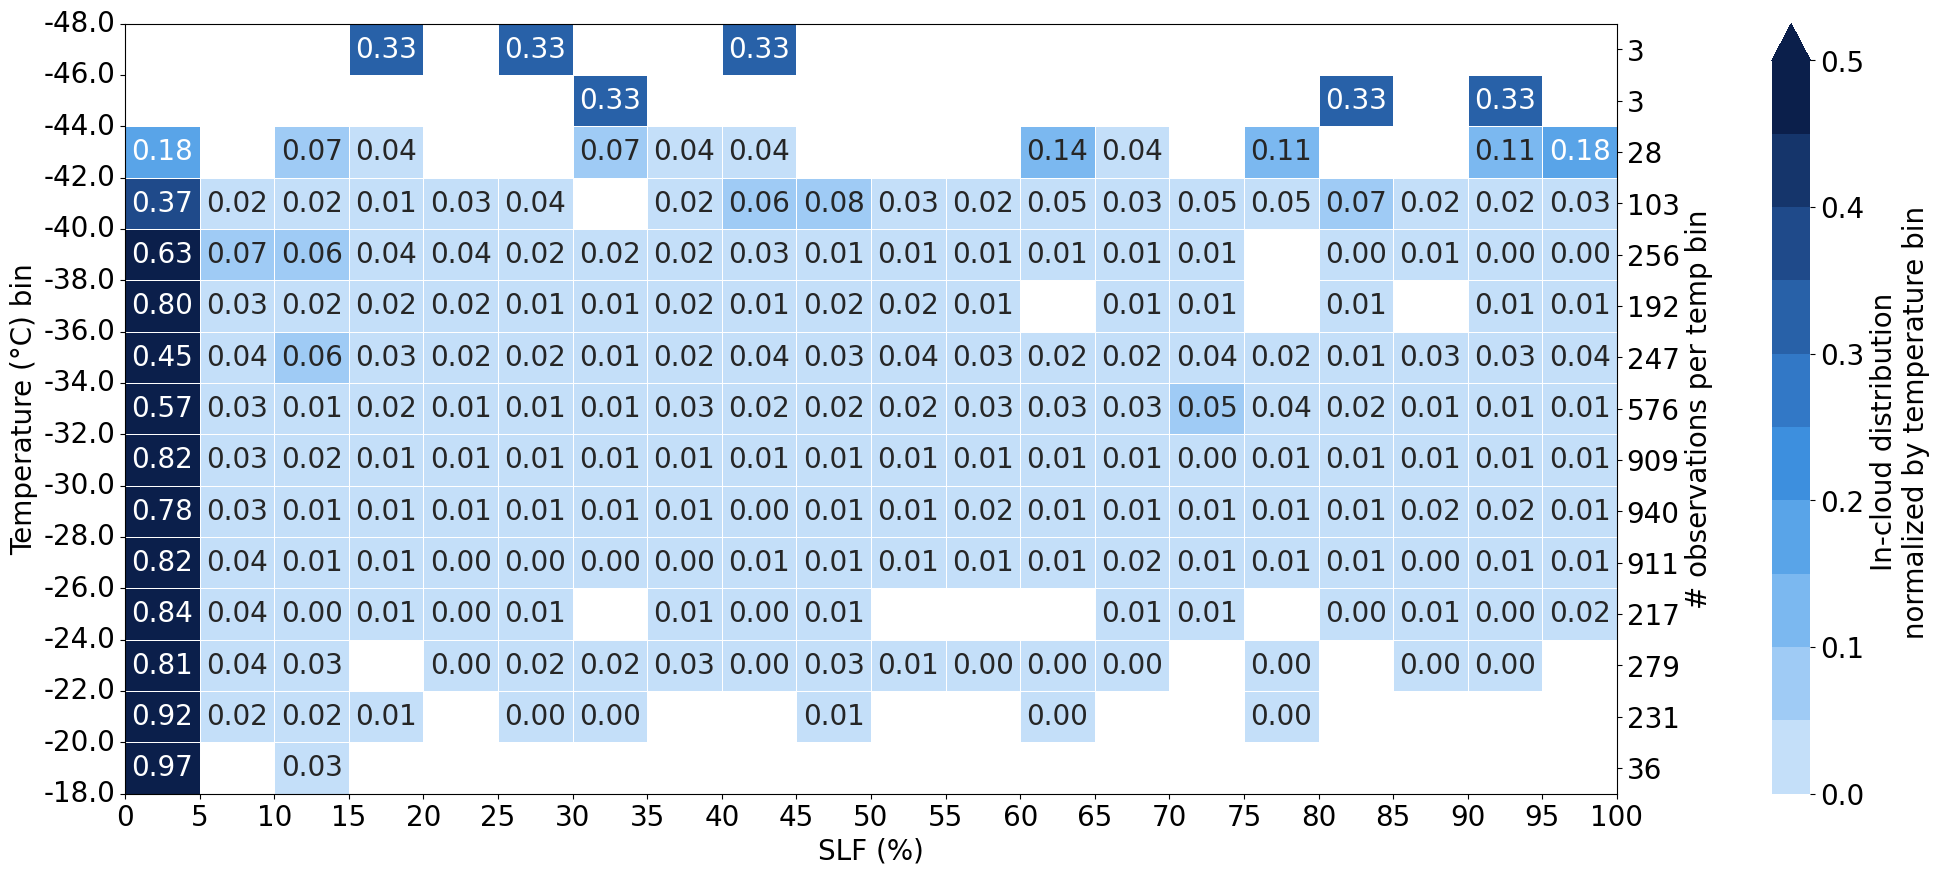

In [44]:
# Heatplot of SLF vs temperature incloud
savefile = save_path + f'slf_vs_T_incloud_{d_text}_{sample_rate}s.png'
ss=20

fig, ax = plt.subplots(figsize=(25, 10))

# Set up plot options
plt.rcParams.update({'font.size':20}) # set global font size

xax_lab = 'SLF (%)' 
yax_lab = u'Temperature (\u00B0C) bin'
cbar_lab = "In-cloud distribution \n normalized by temperature bin"    

#cmap=sns.cubehelix_palette(5, rot=-.15, dark=.25, as_cmap=True)
blue_mvd = [
    '#0B1F4B',  # very dark navy
    '#15356B',  # dark blue
    '#1F4A8A',  # strong mid blue
    '#2861A8',  # saturated blue
    '#3278C6',  # bright blue
    '#3D8FDE',  # lighter bright blue
    '#59A4E8',  # light blue
    '#7BB8F0',  # pale sky blue
    '#9FCBF5',  # very light sky blue
    '#C4DFF9',  # near-white blue
]
cmap = mpl.colors.ListedColormap(
    name="blue_distinct",
    colors=blue_mvd
)
# Set ticks and colormap to use
ticks = np.array([0,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,1.00])


pl = sns.heatmap(temp_slf_df, annot=temp_slf_df, cmap=cmap.reversed(), fmt=f".2f",vmin= 0, vmax=0.5,  mask=temp_slf_df.isna(), ax=ax, 
                        cbar_kws={"location" : 'right', 'ticks':ticks,'extend':'max', 'label':cbar_lab, 'pad':0.08,},
                        linewidths=0.5, annot_kws={})

pl.set_xlabel(xax_lab, fontsize=ss) # set plot labels
pl.set_ylabel(yax_lab, fontsize=ss)

# Create temp_bin_edges
n = temp_slf_df.shape[0] # number of yaxis values
temp_bin_edges = temp_bins[:n+1]
temp_bins = temp_slf_df.index.to_numpy()
n_diff = temp_bins[-1] - (temp_bins[-2]-temp_bins[-1])
temp_bins  = np.append(temp_bins, [n_diff])
temp_bin_edges1 = temp_bins-1

# Left side y-axis: temperature,  ticks at edges
pl.set_ylim(0, n) 
pl.invert_yaxis()
pl.set_yticks(np.arange(0, n+1))
pl.set_yticklabels(temp_bin_edges, rotation=0, fontsize=ss) # labels for ticks at edges
# Right side y-axis: number of observations, ticks in the middle
pl_right = pl.twinx()
pl_right.set_ylim(pl.get_ylim())
pl_right.set_yticks(np.arange(0.5, n, 1.0)) # set center location
pl_right.set_yticklabels(
    [int(v) for v in temp_obs.values],  # set number of obs as label
    rotation=0,
    fontsize=ss
)

pl_right.set_ylabel('# observations per temp bin', size=ss)
pl_right.tick_params(axis='y', labelsize=ss)

# adjust x-axis ticks
# tick adjustment
# add last tick
ncols = len(temp_slf_df.columns)

# Shift the x-ticks to the left edge of each cell
new_x_ticks = np.arange(ncols + 1)  # Get new x-tick positions to align with the left edge of cells
old_labels = [t.get_text() for t in pl.get_xticklabels()]
labels = old_labels + ['100']  

pl.set_xticks(new_x_ticks)  # Set new ticks at the left side of cells
pl.set_xticklabels(labels,fontsize=ss)  # Reuse the old labels


# colorbar options
cax=pl.figure.axes[-1]
cax.tick_params(labelsize=ss)  # Change the size of the colorbar ticks

plt.savefig(savefile, bbox_inches='tight')
print(f'Plot is saved to: {savefile}')

plt.show()

Plot is saved to: /home/ninalar/Documents/MC2/procIslasMicrophy-1/save_images/sample_rate/new/dist200/slf_incloud_TC_alt_dist200_5s.png


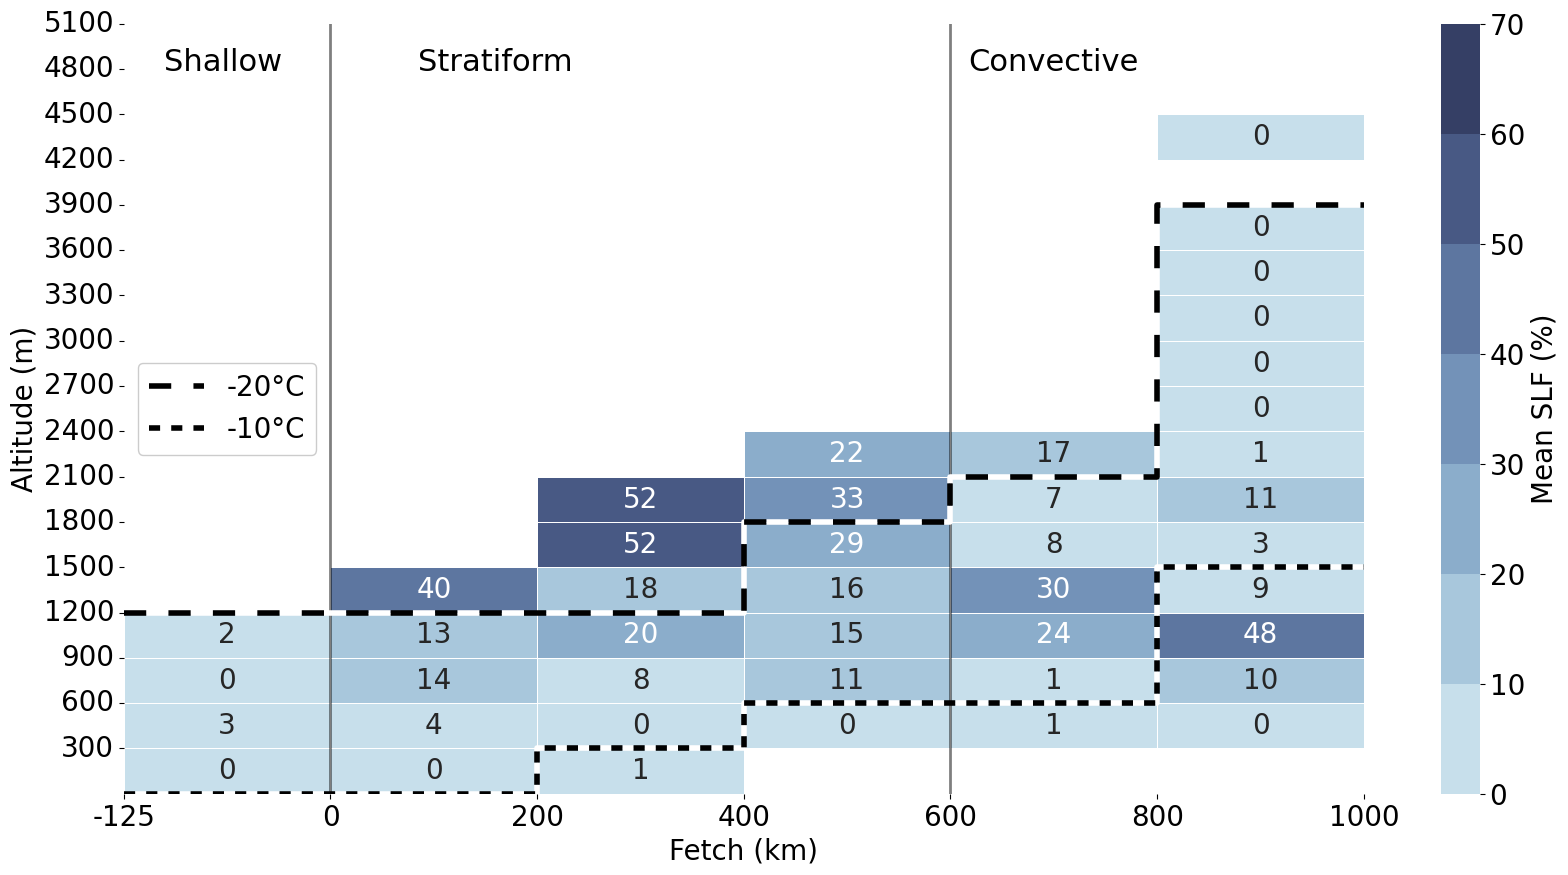

In [45]:

# Heatplot of mean SLF in-cloud
# y-axis: altitude
# slf_mean_df,
ss=22

slf_labels_dict = {
    'xax_lab':'Fetch (km)',
    'yax_lab':'Altitude (m)',
    'cbar_lab':"Mean SLF (%)"
}

savefile = save_path + f'slf_incloud_TC_alt_{d_text}_{sample_rate}s.png'

fig, ax = plt.subplots(figsize=(20, 10))

plot_heatmap_ax(slf_mean_df, slf_labels_dict, ax, mask_na= True, val=0, annot_df = slf_mean_df, counts=False, ss=20, ncol=7, v_extend=70, altitude_bins=altitude_bins)
# add temperature lines -10 and -20
temp_steps(ax,tb,th20,th10)
add_sect(ax,fs=ss) # add lines and text for sections

plt.savefig(savefile, bbox_inches='tight')
print(f'Plot is saved to: {savefile}')

plt.show()


# Need to look further into how to save and show this...

### Joint plot of TWC and SLF 

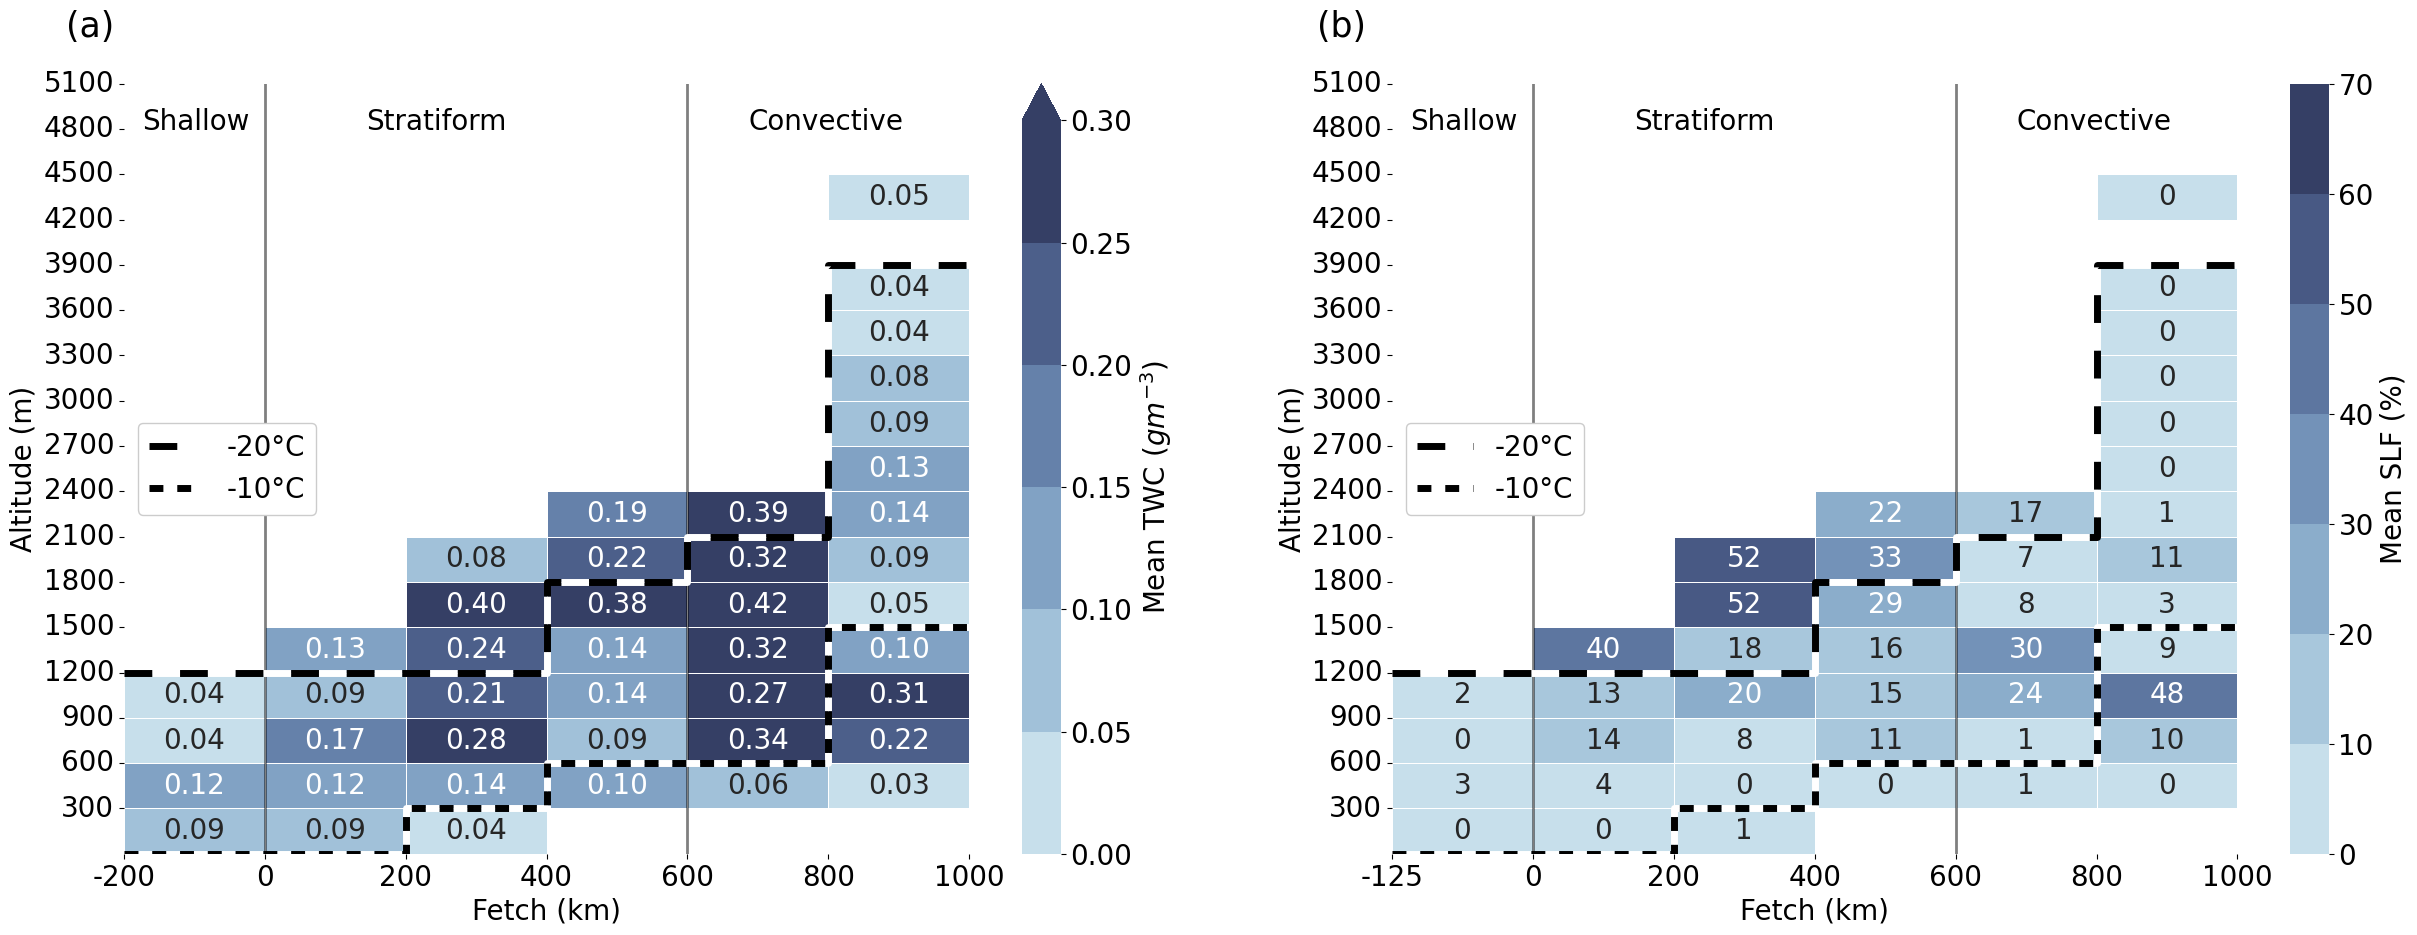

In [46]:
# ---- Plot the temperature and SLF in one plot
fig, ax = plt.subplots(1,2, figsize=(30, 10))
plt.subplots_adjust(wspace=0.2)

ss = 20

# TWC
plot_heatmap_ax(twc_mean_df, twc_lab_dict, ax[0], mask_na= True, val=2, annot_df = twc_mean_df, ss=ss,counts=False,ncol=6, v_extend=0.3, altitude_bins=altitude_bins)
temp_steps(ax[0],tb,th20,th10,lw=5) # add temperature lines -10 and -20 do not need the temperature lines yet
add_sect(ax[0],x_vals = [0.085,0.37,0.83],fs=ss) # add lines and text for sections

# SLF

plot_heatmap_ax(slf_mean_df, slf_labels_dict, ax[1], mask_na= True, val=0, annot_df = slf_mean_df, counts=False,ss=ss, ncol=7, v_extend=70, altitude_bins=altitude_bins)
temp_steps(ax[1],tb,th20,th10,lw=5) # add temperature lines -10 and -20
add_sect(ax[1],x_vals = [0.085,0.37,0.83],fs=ss) # add lines and text for sections

# set (a) and (b) to plots
ax[0].set_title('(a)', y=1.05, x=-0.04,fontdict={'fontsize': 25})
ax[1].set_title('(b)', y=1.05, x=-0.06,fontdict={'fontsize': 25}) # testing


savefile = save_path + f'TWC_SLF_incloud_{d_text}_{sample_rate}s.png'
plt.savefig(savefile, dpi=300, bbox_inches='tight')

### Joint plot of number of observations and SLF
For comparison between different sizes of distance bins.

Plot is saved to: /home/ninalar/Documents/MC2/procIslasMicrophy-1/save_images/sample_rate/new/dist200/obs_SLF_incloud_dist200_5s.png


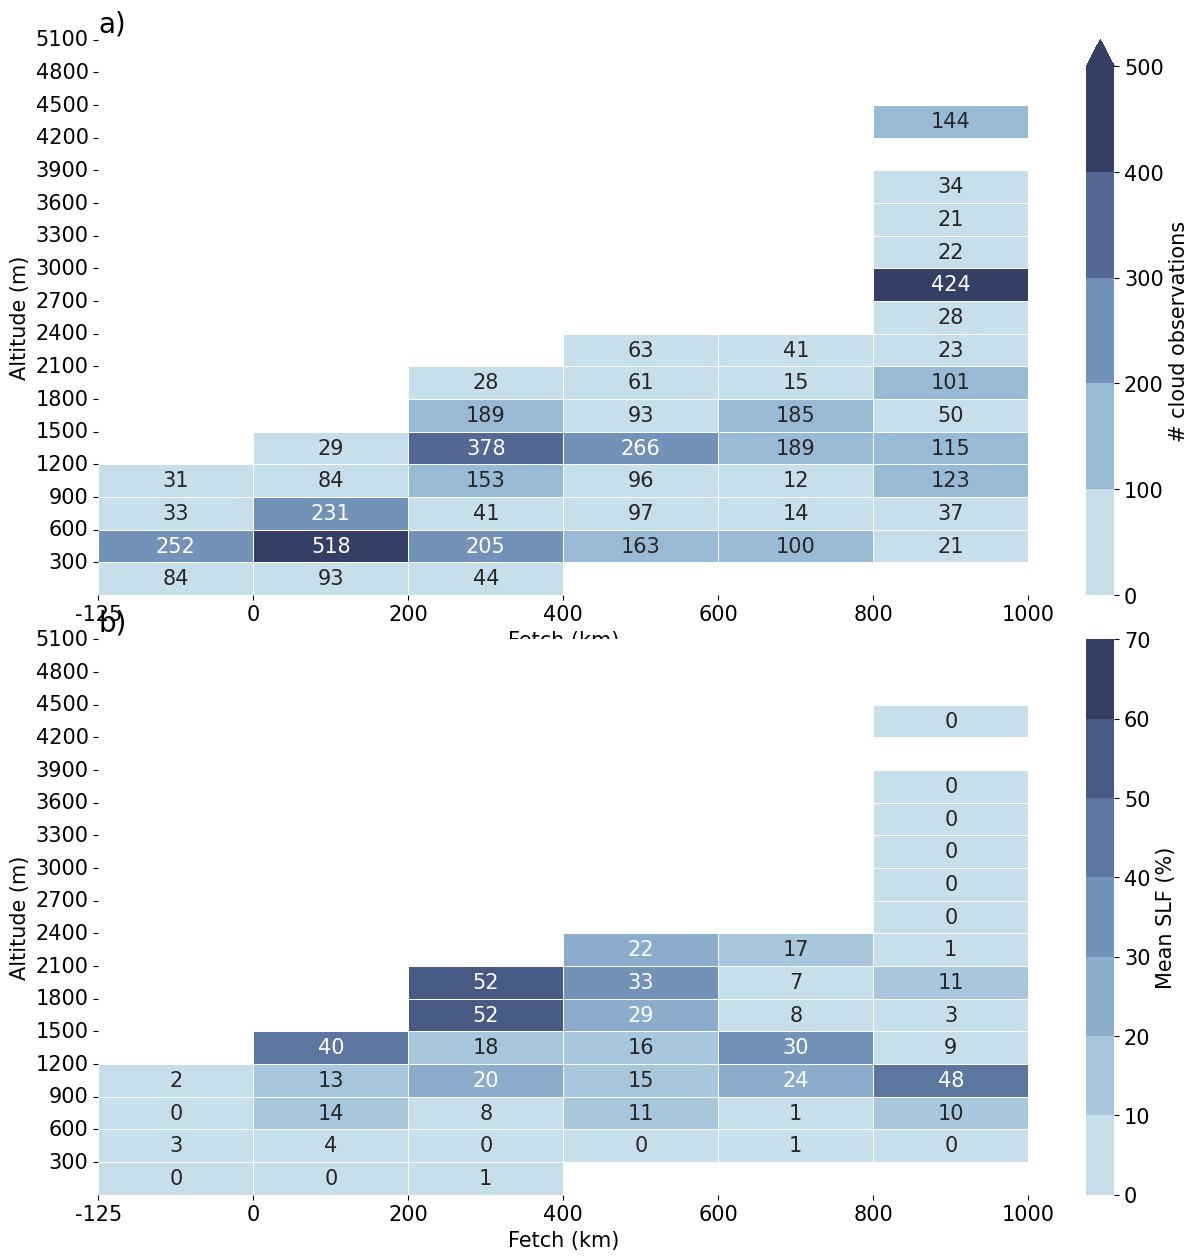

In [47]:
# ---- Plot the number of observations and SLF in one plot
fig, ax = plt.subplots(2,1, figsize=(15, 15))
plt.subplots_adjust(hspace=0.08)

# Observations
plot_heatmap_ax(count_df, incloud_labels_dict, ax[0], mask_na= True, val=0, annot_df = count_df, counts=False, ss=15,ncol=5, v_extend=500, altitude_bins=altitude_bins)
#add_sect(ax[0],fs=15) # add lines and text for sections
ax[0].set_title('a)', loc='left',fontdict={'fontsize': 20})

# SLF
plot_heatmap_ax(slf_mean_df, slf_labels_dict, ax[1], mask_na= True, val=0, annot_df = slf_mean_df, counts=False,ss=15, ncol=7, v_extend=70, altitude_bins=altitude_bins)
#temp_steps(ax[1],tb,th20,th10,lw=3) # add temperature lines -10 and -20
#add_sect(ax[1],fs=15) # add lines and text for sections
ax[1].set_title('b)', loc='left',fontdict={'fontsize': 20})

savefile = save_path + f'obs_SLF_incloud_{d_text}_{sample_rate}s.png'
plt.savefig(savefile, bbox_inches='tight')

print(f'Plot is saved to: {savefile}')

plt.show()


# sum each colum to get the number of observations per distance bin
#col_sum = count_df.sum()

#print(f'Sum of observations per {dist_bin_size}km distance bin: {col_sum}')

In [48]:
e_twc_mean_df

dist_bin,-200,0,200,400,600,800
altitude_bin,,,,,,
5550.0,NaN,NaN,NaN,NaN,NaN,NaN
5250.0,NaN,NaN,NaN,NaN,NaN,NaN
4950.0,NaN,NaN,NaN,NaN,NaN,NaN
4650.0,NaN,NaN,NaN,NaN,NaN,NaN
4350.0,NaN,NaN,NaN,NaN,NaN,0.049024
4050.0,NaN,NaN,NaN,NaN,NaN,NaN
3750.0,NaN,NaN,NaN,NaN,NaN,0.037478
3450.0,NaN,NaN,NaN,NaN,NaN,0.040916
3150.0,NaN,NaN,NaN,NaN,NaN,0.079741


Plot is saved to: /home/ninalar/Documents/MC2/procIslasMicrophy-1/save_images/sample_rate/new/dist200/thresh_test_dist200_5s.png


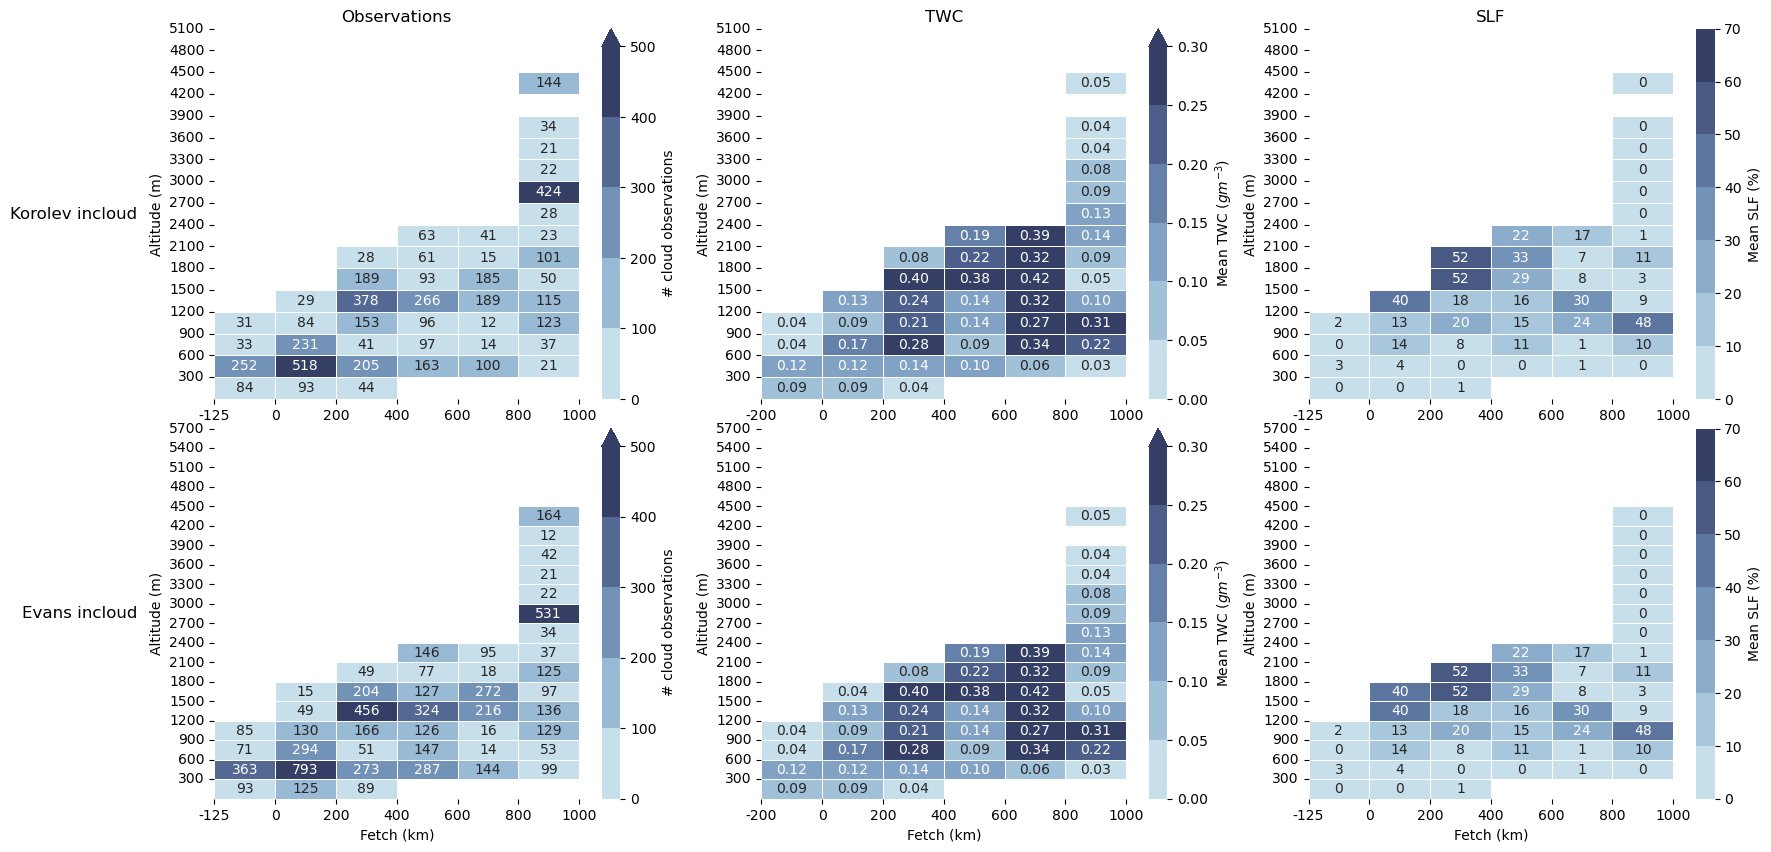

In [49]:
# joined plot for different variants of incloud selection

# naming of rows and columns
cols = ['Observations', 'TWC', 'SLF']
rows = ['Korolev incloud', 'Evans incloud']

fig, axes = plt.subplots(2,3, figsize=(20, 10))
plt.subplots_adjust(hspace=0.08)

# Observations
# original
plot_heatmap_ax(count_df, incloud_labels_dict, axes[0,0], mask_na = True, val=0, annot_df = count_df, counts=False, ss=10,ncol=5, v_extend=500, altitude_bins=altitude_bins)
#add_sect(axes[0,0],fs=10) # add lines and text for sections
#ax[0].set_title('a)', loc='left',fontdict={'fontsize': 20})

#evans
plot_heatmap_ax(m_evans_count_df, incloud_labels_dict, axes[1,0], mask_na = True, val=0, annot_df = m_evans_count_df, counts=False, ss=10,ncol=5, v_extend=500, altitude_bins=altitude_bins)
#add_sect(ax[1,0],fs=10) # add lines and text for sections
#ax[0].set_title('a)', loc='left',fontdict={'fontsize': 20})

# TWC
# original
plot_heatmap_ax(twc_mean_df, twc_lab_dict, axes[0,1], mask_na= True, val=2, annot_df = twc_mean_df, counts=False, ss=10,ncol=6, v_extend=0.3, altitude_bins=altitude_bins)
#add_sect(ax[0,1],fs=10) # add lines and text for sections
#ax[0].set_title('a)', loc='left',fontdict={'fontsize': 20})

# evans
plot_heatmap_ax(e_twc_mean_df, twc_lab_dict, axes[1,1], mask_na= True, val=2, annot_df = e_twc_mean_df, counts=False, ss=10,ncol=6, v_extend=0.3, altitude_bins=altitude_bins)
#add_sect(ax[1,1],fs=10) # add lines and text for sections
#ax[0].set_title('a)', loc='left',fontdict={'fontsize': 20})

# SLF
#original
plot_heatmap_ax(slf_mean_df, slf_labels_dict, axes[0,2], mask_na= True, val=0, annot_df = slf_mean_df, counts=False,ss=10, ncol=7, v_extend=70, altitude_bins=altitude_bins)
#temp_steps(ax[1],tb,th20,th10,lw=3) # add temperature lines -10 and -20
#add_sect(ax[1],fs=15) # add lines and text for sections
#ax[1].set_title('b)', loc='left',fontdict={'fontsize': 20})

# evans
plot_heatmap_ax(e_slf_mean_df, slf_labels_dict, axes[1,2], mask_na= True, val=0, annot_df = e_slf_mean_df, counts=False,ss=10, ncol=7, v_extend=70, altitude_bins=altitude_bins)

#names
pad = 5 # in points

for ax, col in zip(axes[0], cols):
    ax.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')

for ax, row in zip(axes[:,0], rows):
    ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - pad, 0),
                xycoords=ax.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center')

savefile = save_path + f'thresh_test_{d_text}_{sample_rate}s.png'
plt.savefig(savefile, bbox_inches='tight')
print(f'Plot is saved to: {savefile}')

plt.show()


In [50]:
twc_mean_df-e_twc_mean_df

dist_bin,-200,0,200,400,600,800
altitude_bin,,,,,,
150.0,0.000000e+00,0.000000e+00,6.938894e-18,NaN,NaN,NaN
450.0,-1.387779e-17,0.000000e+00,2.775558e-17,-2.775558e-17,1.387779e-17,0.000000e+00
750.0,6.938894e-18,-2.775558e-17,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1050.0,0.000000e+00,0.000000e+00,-2.775558e-17,0.000000e+00,0.000000e+00,0.000000e+00
1350.0,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.387779e-17
1650.0,NaN,NaN,0.000000e+00,0.000000e+00,-2.156464e-03,0.000000e+00
1950.0,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,2.775558e-17
2250.0,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00
2550.0,NaN,NaN,NaN,NaN,NaN,0.000000e+00


# Number concentration plots 

Plot is saved to: /home/ninalar/Documents/MC2/procIslasMicrophy-1/save_images/sample_rate/new/dist200/NT100_incloud_alt_dist200_5s.png


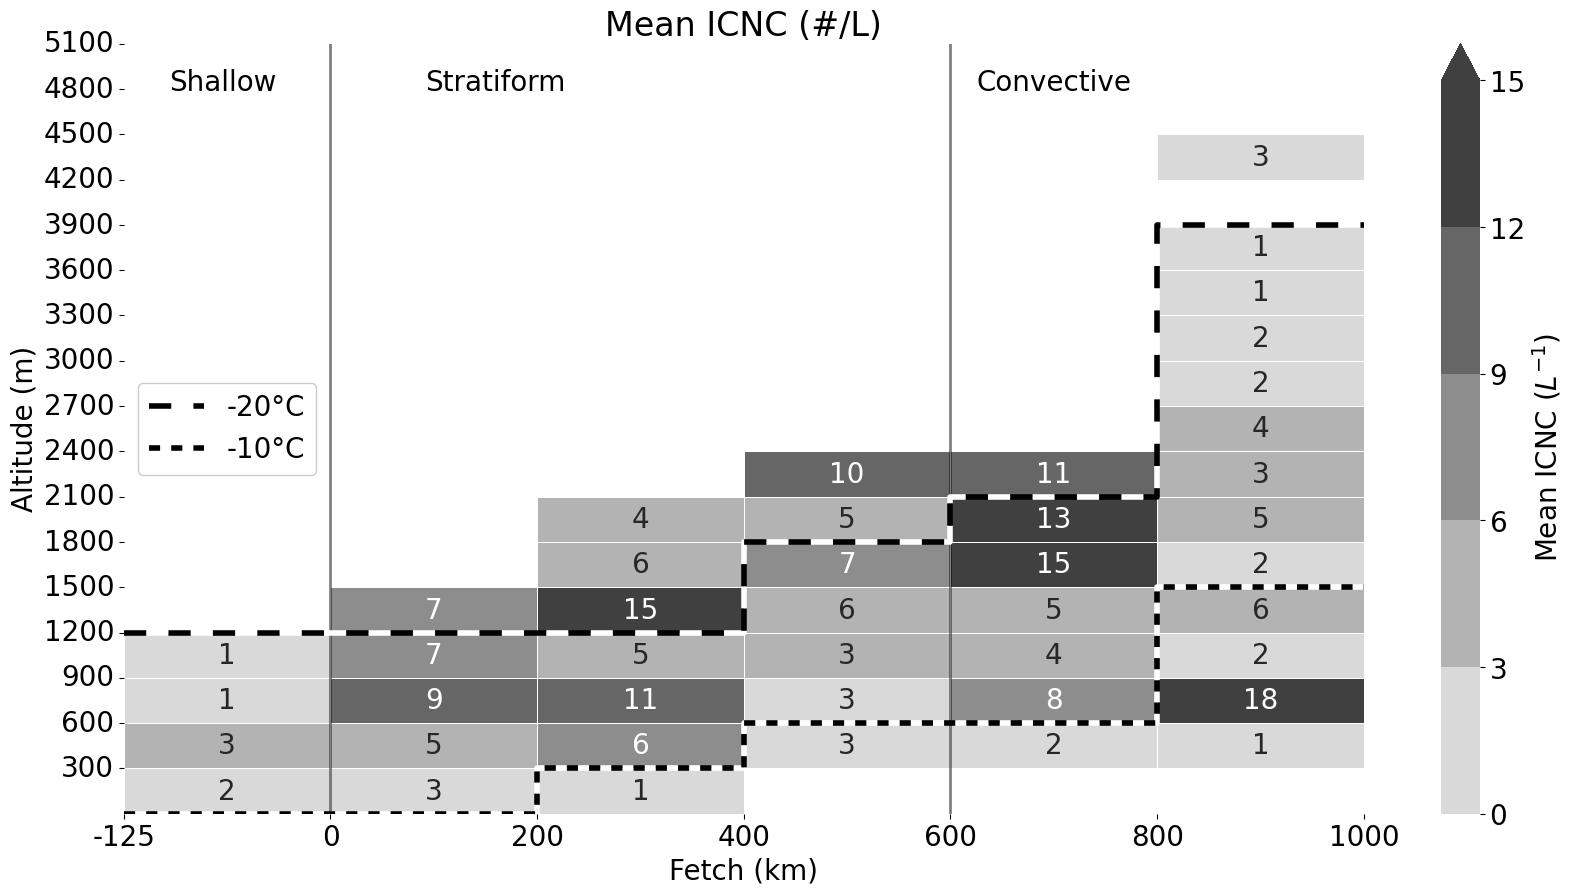

In [51]:
# Heatplot of ICNC (Ice crystal number concentration)
# y-axis: altitude

icnc_mean_df = create_distribution_df(ds_incloud['NT100'],'dist_bin','altitude_bin','mean',val=0, mask=incloud_mask)
icnc_std_df = create_distribution_df(ds_incloud['NT100'],'dist_bin','altitude_bin','std',val=0, mask=incloud_mask)

# adjust for plotting: remove the two topmost empthy altitude layers
icnc_mean_df = icnc_mean_df.iloc[2:]
icnc_std_df = icnc_std_df.iloc[2:]

# recalculate to #/L
icnc_mean_df = icnc_mean_df/1000
icnc_std_df = icnc_std_df/1000


icnc_lab_dict = {
    'xax_lab':'Fetch (km)',
    'yax_lab':'Altitude (m)',
    'cbar_lab':'Mean ICNC ($L^{-1}$)'
}

savefile = save_path + f'NT100_incloud_alt_{d_text}_{sample_rate}s.png'

fig,ax = plt.subplots(figsize=(20, 10))

plot_heatmap_ax(icnc_mean_df, icnc_lab_dict, ax, mask_na= True, val=0, annot_df = icnc_mean_df, counts=False, ss=20, col='Grey',ncol=5, v_extend=15, altitude_bins=altitude_bins)
temp_steps(ax,tb,th20,th10) # add temperature lines -10 and -20
add_sect(ax,fs=ss) # add lines and text for sections
ax.set_title("Mean ICNC (#/L)")

plt.savefig(savefile, bbox_inches='tight')
print(f'Plot is saved to: {savefile}')

plt.show()

Plot is saved to: /home/ninalar/Documents/MC2/procIslasMicrophy-1/save_images/sample_rate/new/dist200/cdnc_incloud_alt_dist200_5s.png


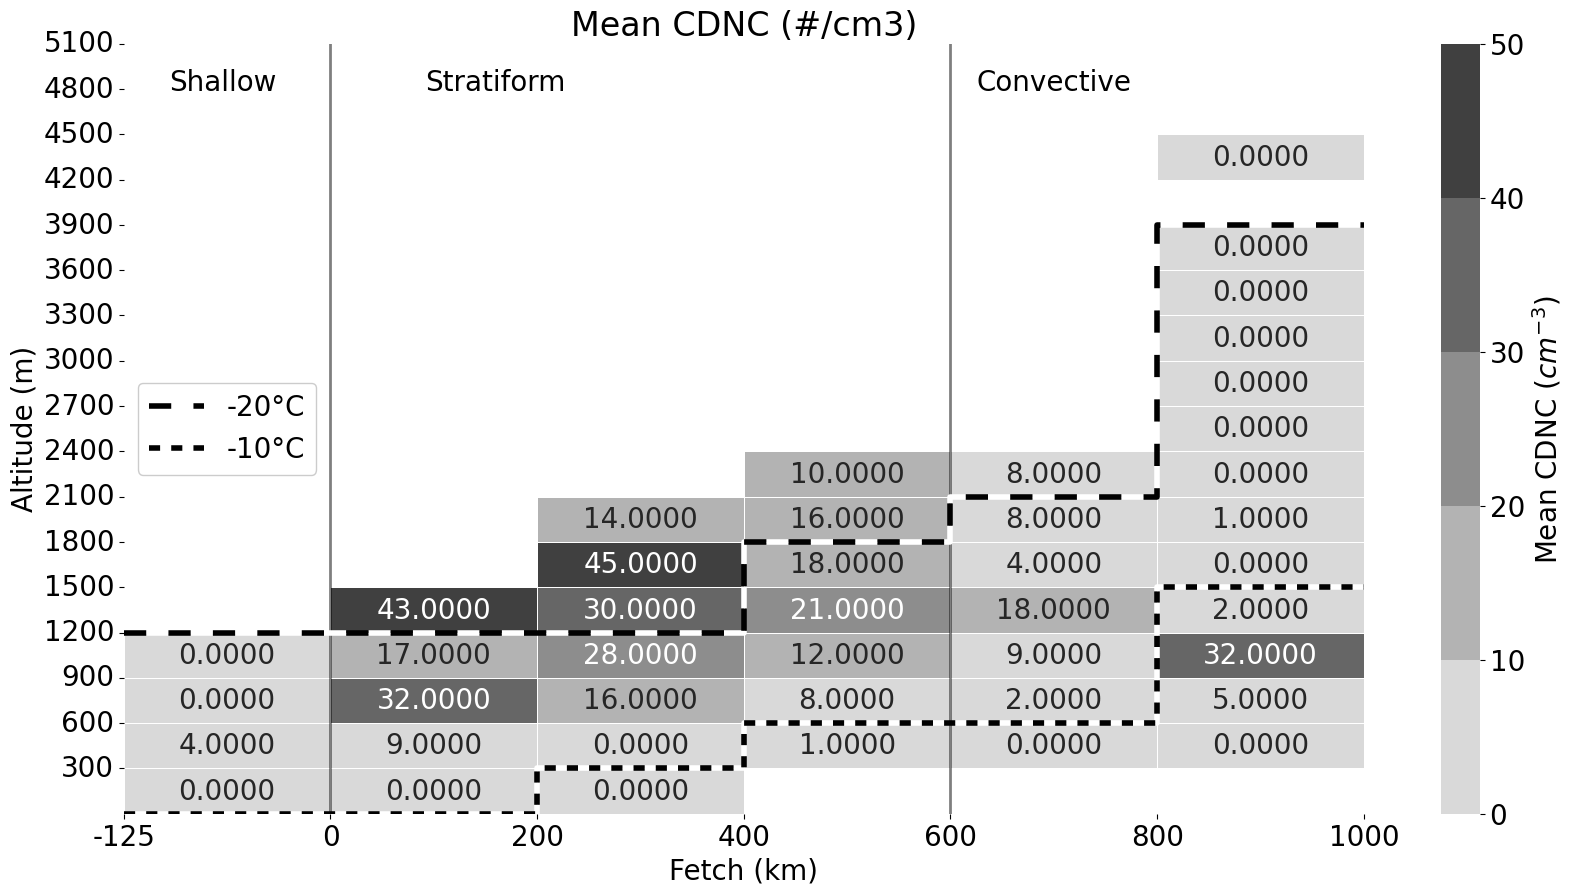

In [52]:
# Heatplot of CDNC (droplet number concentration)
# y-axis: altitude
# changed to using calc instead of corr
cdnc_mean_df = create_distribution_df(ds_incloud['Number Conc calc'],'dist_bin','altitude_bin','mean',val=0, mask=incloud_mask)
cdnc_std_df = create_distribution_df(ds_incloud['Number Conc calc'],'dist_bin','altitude_bin','std',val=0, mask=incloud_mask)

# adjust for plotting: remove the two topmost empthy altitude layers
cdnc_mean_df = cdnc_mean_df.iloc[2:]
cdnc_std_df = cdnc_std_df.iloc[2:]

cdnc_lab_dict = {
    'xax_lab':'Fetch (km)',
    'yax_lab':'Altitude (m)',
    'cbar_lab':'Mean CDNC ($cm^{-3}$)'
}

savefile = save_path + f'cdnc_incloud_alt_{d_text}_{sample_rate}s.png'

fig,ax = plt.subplots(figsize=(20, 10))

plot_heatmap_ax(cdnc_mean_df, cdnc_lab_dict, ax, mask_na= True, val=4, annot_df = cdnc_mean_df, counts=False, ss=20,col='Grey', ncol=5, v_extend=50, altitude_bins=altitude_bins)
temp_steps(ax,tb,th20,th10) # add temperature lines -10 and -20
add_sect(ax,fs=ss) # add lines and text for sections
ax.set_title("Mean CDNC (#/cm3)")

plt.savefig(savefile, bbox_inches='tight')
print(f'Plot is saved to: {savefile}')

plt.show()

# Particle sizes

In [53]:
# The ED must be calculated for the subset of particles that we are actually using in the analyis

def calc_ed(ds, rad_var, count_var, dim):
    # Function to calculate the total Effective diameter from all the timesteps in ds
    # ds: xarray
    # rad_var: variable to use as radius
    # count_var: variable to use for counts
    # dim: dimension to sum over

    # calculate the radius, radius squared and radius cubed
    radius = 0.5*ds[rad_var][-1]
    radius_sq = radius**2
    radius_cu = radius**3

    # calculate the sum of (sum_count*radius_cu) and (sum_count*radius_sq)
    sum_count_rad_cu = (ds[count_var]*radius_cu).sum(dim=dim)
    sum_count_rad_sq = (ds[count_var]*radius_sq).sum(dim=dim)

    # Calculate ED:
    ed = 2*(sum_count_rad_cu/sum_count_rad_sq) 
    return ed


# Calculate ED based on size and count for CDP and CIP NB! this is for the whole dataset, not just above threshold
ds_incloud['ED_calc_CDP'] = calc_ed(ds_incloud, rad_var='Size', count_var='CDP Bin Particle Count', dim= 'CDP_Bin')
ds_incloud['ED_calc_CIP'] = calc_ed(ds_incloud, rad_var='MIDBINS', count_var='COUNTS', dim= 'Vector64')

# update attributes for the new parameters
ds_incloud['ED_calc_CDP'] = ds_incloud['ED_calc_CDP'].assign_attrs(
        long_name = 'CDP Effective diameter',
        units = 'um',
        description = 'Effective Diameter calculated from the CDP. Derived from "CDP Bin Particle Count" and "Size"',
        instrument = "CDP")
ds_incloud['ED_calc_CIP'] = ds_incloud['ED_calc_CIP'].assign_attrs(
        long_name = 'CIP Effective diameter',
        units = 'um',
        description = 'Effective Diameter calculated from the CIP. Derived from "COUNTS" and "MIDBINS"',
        instrument = "CIP")

In [54]:
# recalculating the Effective diameter for the CDP per distance-altitude bin

def create_ed_comp(ds_large, shape_df, rad_var, count_var):

    #initiate ed_df by creating an empty dataframe and reindex like the shape_df
    ed_df = pd.DataFrame().reindex_like(shape_df)

    # run through each altitude-distance set
    for alt in ed_df.index:
        alt_mask = (ds_large['altitude_bin']==alt).compute()
        ds_alt = ds_large.where(alt_mask, drop=True)

        #print(ds_alt.time.values)
        for dist in ed_df.columns:
            if dist==-125:
                # the distance bins in ds_alt used -200 as the initial bin instead of -125
                dist_u=-200 # hack to fix issues whith changning the inital bin (TODO fix this in the distance bin calculation)
            else:
                dist_u=dist

            #select only the distance
            dist_mask = (ds_alt['dist_bin']==dist_u).compute()
            ds_dist = ds_alt.where(dist_mask, drop=True)

            # check if there are observations within the alt-dist bin
            # before calculating the ed
            add=len(ds_dist.time)
            if add>0:
                # Calculate ed
                # calculate the radius, radius squared and radius cubed
                radius = 0.5*ds_dist[rad_var][-1]
                radius_sq = radius**2
                radius_cu = radius**3

                # sum all counts per bin for the selected lines
                sum_count = ds_dist[count_var].sum(dim='time').values

                # calculate the sum of (sum_count*radius_cu) and (sum_count*radius_sq)
                sum_count_rad_cu = (sum_count*radius_cu).sum().values
                sum_count_rad_sq = (sum_count*radius_sq).sum().values

                #calculate ed and add to correct location of ed_df
                ed_df.loc[alt,dist] = 2*(sum_count_rad_cu/sum_count_rad_sq) 

    return ed_df

# CDP ED
# select only CDP_bins higher than 6 mum
bin_mask = (ds_incloud.CDP_Bin>6).compute()
ds_large = ds_incloud.where(bin_mask, drop=True)
ed_cdp_df = create_ed_comp(ds_large,slf_mean_df,rad_var='Size', count_var='CDP Bin Particle Count')

# CIP ED
# select only CIP_bins higher than 100 mum
bin_mask = (ds_incloud.MIDBINS>100).compute()
ds_large = ds_incloud.where(bin_mask, drop=True)
ed_cip_df = create_ed_comp(ds_large,slf_mean_df, rad_var='MIDBINS',count_var='COUNTS')

ed_cip_df

dist_bin,-125,0,200,400,600,800
altitude_bin,,,,,,
4950.0,NaN,NaN,NaN,NaN,NaN,NaN
4650.0,NaN,NaN,NaN,NaN,NaN,NaN
4350.0,NaN,NaN,NaN,NaN,NaN,698.935425
4050.0,NaN,NaN,NaN,NaN,NaN,NaN
3750.0,NaN,NaN,NaN,NaN,NaN,883.341614
3450.0,NaN,NaN,NaN,NaN,NaN,864.971863
3150.0,NaN,NaN,NaN,NaN,NaN,965.999939
2850.0,NaN,NaN,NaN,NaN,NaN,969.392212
2550.0,NaN,NaN,NaN,NaN,NaN,885.317566


In [55]:
def get_ed_stats(ds, ed_df, stat, ed_var):

    if stat == 'mean':
        ed_stat = np.nanmean(ds[ed_var])
        
    elif stat == 'median':
        ed_stat = np.nanmean(ds[ed_var])
    else:
        print(f'Stat "{stat}" not defined')
        return

    ed_diff = ed_df-ed_stat
    
    return ed_stat, ed_diff

stat = 'median'

# get composite based on the statistic selected (mean or median)
ed_stat_cdp, ed_diff_df_cdp = get_ed_stats(ds_incloud, ed_cdp_df,stat,'ED_calc_CDP')
ed_stat_cip, ed_diff_df_cip = get_ed_stats(ds_incloud,ed_cip_df,stat, 'ED_calc_CIP')


In [84]:
ed_cdp_df

dist_bin,-125,0,200,400,600,800
altitude_bin,,,,,,
4950.0,NaN,NaN,NaN,NaN,NaN,NaN
4650.0,NaN,NaN,NaN,NaN,NaN,NaN
4350.0,NaN,NaN,NaN,NaN,NaN,27.154001
4050.0,NaN,NaN,NaN,NaN,NaN,NaN
3750.0,NaN,NaN,NaN,NaN,NaN,46.399809
3450.0,NaN,NaN,NaN,NaN,NaN,22.000000
3150.0,NaN,NaN,NaN,NaN,NaN,45.862069
2850.0,NaN,NaN,NaN,NaN,NaN,28.166460
2550.0,NaN,NaN,NaN,NaN,NaN,22.100358


In [56]:
ed_diff_df_cdp

dist_bin,-125,0,200,400,600,800
altitude_bin,,,,,,
4950.0,NaN,NaN,NaN,NaN,NaN,NaN
4650.0,NaN,NaN,NaN,NaN,NaN,NaN
4350.0,NaN,NaN,NaN,NaN,NaN,10.967781
4050.0,NaN,NaN,NaN,NaN,NaN,NaN
3750.0,NaN,NaN,NaN,NaN,NaN,30.213588
3450.0,NaN,NaN,NaN,NaN,NaN,5.813779
3150.0,NaN,NaN,NaN,NaN,NaN,29.675848
2850.0,NaN,NaN,NaN,NaN,NaN,11.980240
2550.0,NaN,NaN,NaN,NaN,NaN,5.914138


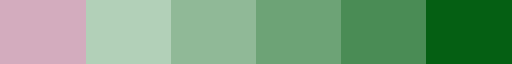

In [57]:
# Color palettes

purple_green_mvd = ['#5f1166','#752c72','#8a457f','#9e5e8d','#c391ac','#d3acbe','#e3c7d2','#b2d0b8','#6da376','#055f13']
purple_green_ed_cip = ['#8a457f','#9e5e8d','#d3acbe','#e3c7d2','#b2d0b8','#6da376','#055f13']
purple_green_ed = ['#d3acbe','#b2d0b8','#90b997','#6da376','#4a8c55','#055f13']
purple_green = ['#93119e','#bc54aa','#dc8dbc','#f2c5d8','#E5E4E2','#aad7ac','#7bb47e','#4c9253','#117028']# with grey

cmap_ed = mpl.colors.ListedColormap(
    name="purple_white_green",
    colors=purple_green_ed
)
cmap_ed

In [58]:
# setting up for hatching where cdnc_mean_df == 0
mask_zero = (cdnc_mean_df == 0.0).values  # mask where 0

#set up grid for colormesh
# Build a grid for pcolormesh
ny, nx = cdnc_mean_df.shape  #this is the same shape for all plots
x = np.arange(nx + 1) # grid should be one larger in each dimension
y = np.arange(ny + 1)

hatch_data = np.where(mask_zero, 1, np.nan) # array with 1 where hatching should occur

Plot is saved to: /home/ninalar/Documents/MC2/procIslasMicrophy-1/save_images/sample_rate/new/dist200/EDrecalc_meandiff_heatmap_dist200_5s.png


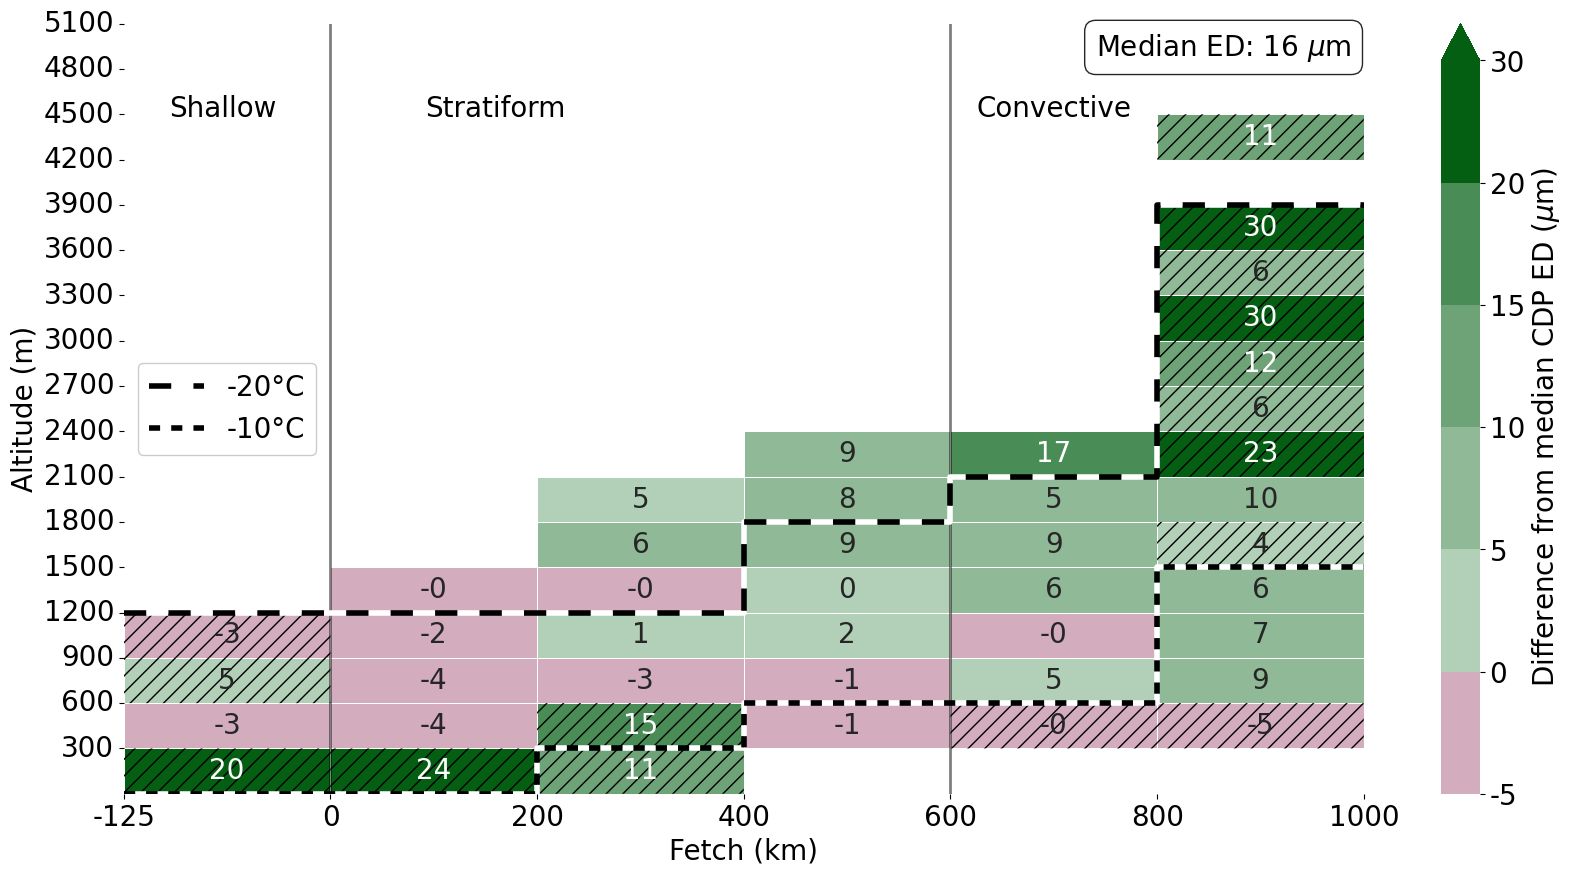

In [59]:
# Heatplot of CDP droplet size (Effective diameter) recalculated for bins larger than 6 mum DIFF FROM MEAN
# y-axis: altitude
# cdp_size_mean_df,cdp_size_std_df


ed_labels_dict = {
    'xax_lab':'Fetch (km)',
    'yax_lab':'Altitude (m)',
    'cbar_lab':f'Difference from {stat} CDP ED ($\mu$m)'
}

savefile = save_path + f'EDrecalc_meandiff_heatmap_{d_text}_{sample_rate}s.png'

# Set ticks and colormap to use
t_ed=np.array([-5,0,5,10,15,20,30])


fig,ax = plt.subplots(figsize=(20, 10))

#plot_heatmap_ax(ed_meandiff_df, ed_labels_dict, ax, mask_na= True, val=0, annot_df = ed_meandiff_df, counts=False, ss=20,col=cmap_ed, ticks=t_ed,v_extend=20, altitude_bins=altitude_bins)
plot_heatmap_ax(ed_diff_df_cdp, ed_labels_dict, ax, mask_na= True, val=0, annot_df = ed_diff_df_cdp, counts=False, ss=20,col=cmap_ed, ticks=t_ed,v_extend=20, altitude_bins=altitude_bins)

plt.pcolor(x, y, hatch_data, hatch='//',hatch_linewidth=1, alpha=0) #Hatching for bins where cdnc is zero


# add mean value to top of plot
ax.text(
    0.99, 0.99,          # x, y in axes coordinates (0..1). 0.01 is near left, 0.99 is near top
    f'{stat.capitalize()} ED: {round(ed_stat_cdp)} $\mu$m',
    transform=ax.transAxes,
    fontsize=ss,
    va='top',            # align text vertically at top
    ha='right',           # align left
    color='black',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85)
)

temp_steps(ax,tb,th20,th10) # add temperature lines -10 and -20
add_sect(ax,y_val=0.89,fs=ss) # add lines and text for sections


plt.savefig(savefile, bbox_inches='tight')
print(f'Plot is saved to: {savefile}')

plt.show()

Plot is saved to: /home/ninalar/Documents/MC2/procIslasMicrophy-1/save_images/sample_rate/new/dist200/MVD100_heatmap_meandiff_dist200_5s.png


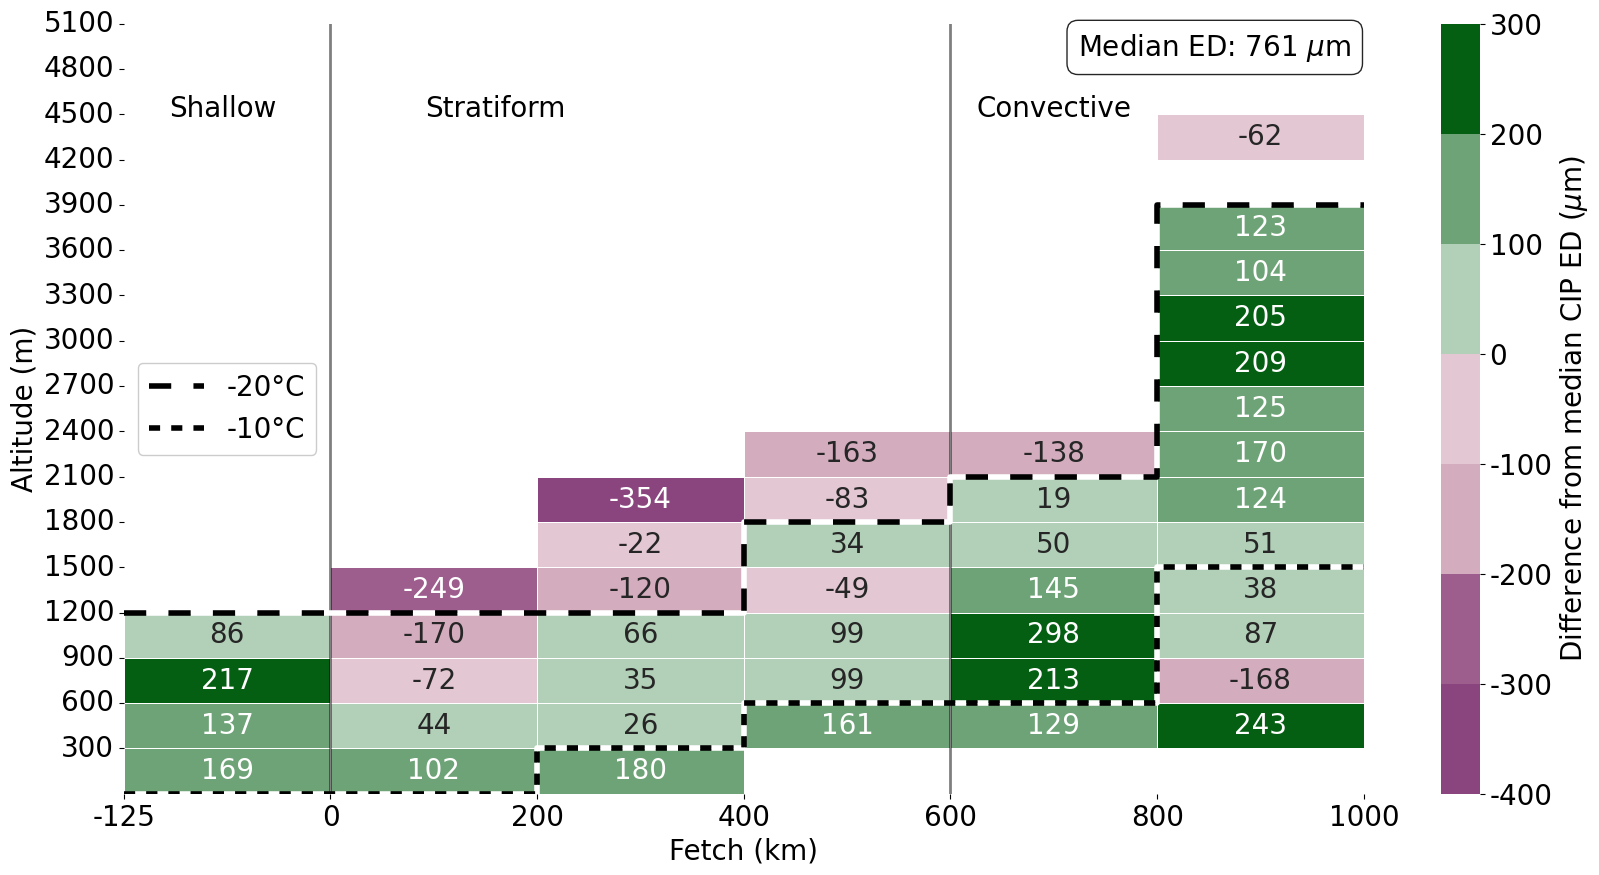

In [60]:
# Heatplot of CIP ice crystal size (ED) Difference from median
# y-axis: altitude
# cip_size_mean_df,cip_size_std_df


# Set ticks and colormap to use
#t_mvd=np.array([-700,-600,-500,-400,-300,-200,-100,0,100,200,300]) # for MVD
t_mvd=np.array([-400,-300,-200,-100,0,100,200,300])  # for ED

#set colorpalette
cmap_mvd = mpl.colors.ListedColormap(
    name="purple_white_green",
    colors=purple_green_ed_cip  #purple_green_mvd
)

cip_lab_dict = {
    'xax_lab':'Fetch (km)',
    'yax_lab':'Altitude (m)',
    'cbar_lab':f'Difference from {stat} CIP ED ($\mu$m)'
}

savefile = save_path + f'MVD100_heatmap_meandiff_{d_text}_{sample_rate}s.png'

fig,ax = plt.subplots(figsize=(20, 10))

#plot_heatmap_ax(mvd_meandiff_df, cip_lab_dict, ax, mask_na= True, val=0, annot_df = mvd_meandiff_df, counts=False, ss=20,col=cmap_mvd, ticks=t_mvd, altitude_bins=altitude_bins)
plot_heatmap_ax(ed_diff_df_cip, cip_lab_dict, ax, mask_na= True, val=0, annot_df = ed_diff_df_cip, counts=False, ss=20,col=cmap_mvd, ticks=t_mvd, altitude_bins=altitude_bins)

# add mean value to top of plot
ax.text(
    0.99, 0.99,          # x, y in axes coordinates (0..1). 0.01 is near left, 0.99 is near top
    #f'Mean MVD: {round(mvd_mean)} $\mu$m',
    f'{stat.capitalize()} ED: {round(ed_stat_cip)} $\mu$m',
    transform=ax.transAxes,
    fontsize=ss,
    va='top',            # align text vertically at top
    ha='right',           # align left
    color='black',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85)
)

temp_steps(ax,tb,th20,th10) # add temperature lines -10 and -20
add_sect(ax,y_val=0.89,fs=ss) # add lines and text for sections

plt.savefig(savefile, bbox_inches='tight')
print(f'Plot is saved to: {savefile}')

plt.show()

# Water content plots

In [61]:
# Grouping and means for LWC, IWC and TWC

# LWC
data_groupedx = ds_incloud[lwc].groupby('dist_bin')
data_groupedxy = data_groupedx.map(lambda group: group.groupby('altitude_bin').mean())
lwc_mean_df = data_groupedxy.to_dataframe().unstack() 
lwc_mean_df = lwc_mean_df.T.reset_index(level=0, drop = True) # - transpose to get altitude on y-axis - reset index and drop outer index(base_time)
lwc_mean_df = lwc_mean_df.reindex(bin_labels, fill_value=np.nan).iloc[::-1] # fill with 0 - reverse order of altitudes

# IWC
data_groupedx = ds_incloud[iwc].groupby('dist_bin')
data_groupedxy = data_groupedx.map(lambda group: group.groupby('altitude_bin').mean())
iwc_mean_df = data_groupedxy.to_dataframe().unstack() 
iwc_mean_df = iwc_mean_df.T.reset_index(level=0, drop = True) # - transpose to get altitude on y-axis - reset index and drop outer index(base_time)
iwc_mean_df = iwc_mean_df.reindex(bin_labels, fill_value=np.nan).iloc[::-1] # fill with 0 - reverse order of altitudes


# adjust for plotting: remove the two topmost empthy altitude layers
iwc_mean_df = iwc_mean_df.iloc[2:]
lwc_mean_df = lwc_mean_df.iloc[2:]

Ice water path is the mass of all ice phase particles within a vertical atmospheric column per unit area kg/m-2
Ice water content is the mass of ice particles per unit volume of air g/m-3

Plot is saved to: /home/ninalar/Documents/MC2/procIslasMicrophy-1/save_images/sample_rate/new/dist200/IWP_LWP_dist200_5s.png


<function matplotlib.pyplot.show(close=None, block=None)>

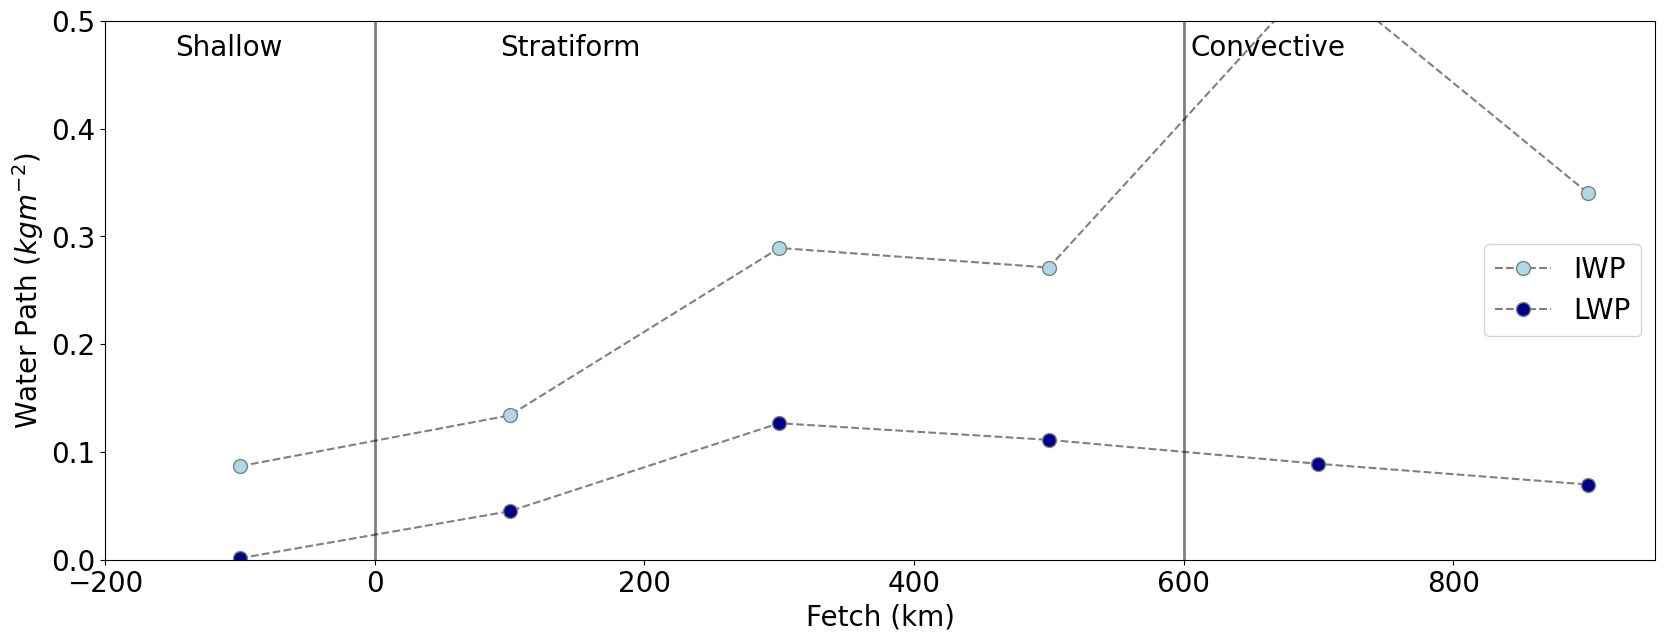

In [62]:
# estimate the integration of the lwc mean df = lwp

lwc_mean_dfad = lwc_mean_df*300
lwp_df = lwc_mean_dfad.sum()
lwp_df=lwp_df/1000 # calculate in kg/m-2
lwp_df.index = lwp_df.index + 100 # shift index to halfway point to line up with middle of distance bin

# estimate the integration of the lwc mean df = lwp
iwc_mean_dfad = iwc_mean_df*300
iwp_df = iwc_mean_dfad.sum()
iwp_df=iwp_df/1000 # calculate in kg/m-2
iwp_df.index = iwp_df.index + 100 # shift index to halfway point to line up with middle of distance bin

fig, ax = plt.subplots(figsize=(20, 7))

iwp_df.plot(marker ='.',ms=ss,mfc='lightblue',ls='--',c='grey', label='IWP')
lwp_df.plot(marker ='.',ms=ss,mfc='darkblue',ls='--',c='grey', label='LWP')
add_sect(ax,xv_vals=[0,600],fs=ss)
ax.set_xlabel('Fetch (km)', fontsize=ss) # set plot labels
ax.set_ylabel('Water Path ($kgm^{-2}$)', fontsize=ss)
ax.set_xticks([-200,0,200,400,600,800])
ax.set_ylim(0,0.5)

plt.legend()
savefile = save_path + f'IWP_LWP_{d_text}_{sample_rate}s.png'
plt.savefig(savefile, bbox_inches='tight')
print(f'Plot is saved to: {savefile}')
plt.show


In [63]:
iwc

'IWC_H10'

Plot is saved to: /home/ninalar/Documents/MC2/procIslasMicrophy-1/save_images/sample_rate/new/dist200/IWC_heatmap_dist200_5s.png


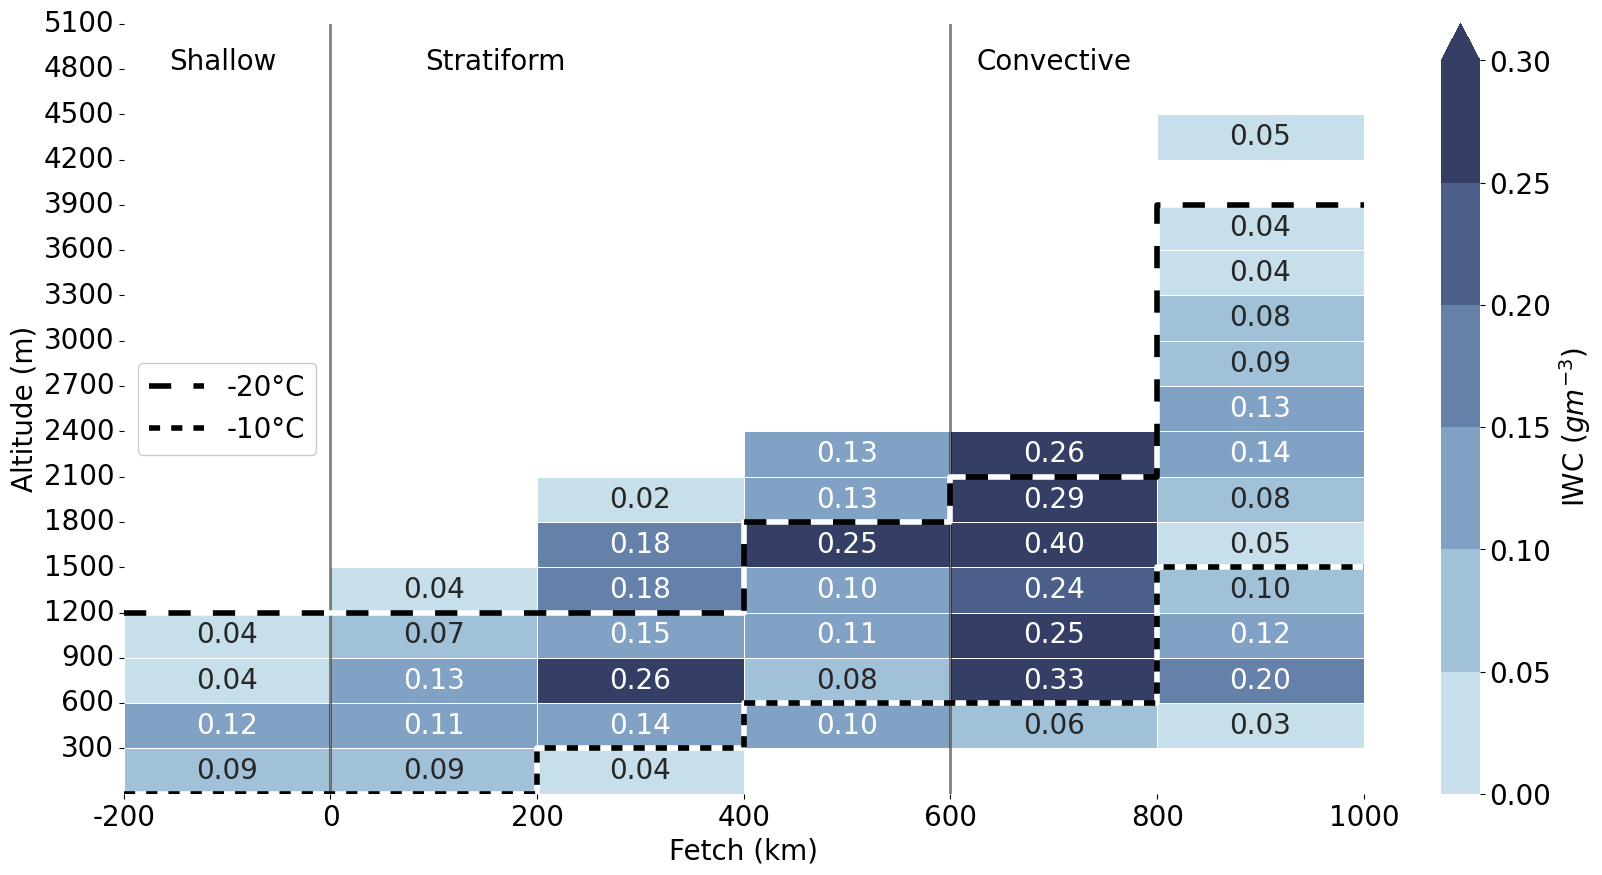

In [64]:
# Heatplot of IWC100 
# y-axis: altitude

iwc_lab_dict = {
    'xax_lab':'Fetch (km)',
    'yax_lab':'Altitude (m)',
    'cbar_lab':'IWC ($gm^{-3}$)'
}

savefile = save_path + f'IWC_heatmap_{d_text}_{sample_rate}s.png'


fig,ax = plt.subplots(figsize=(20, 10))

plot_heatmap_ax(iwc_mean_df, iwc_lab_dict, ax, mask_na= True, val=2, annot_df = iwc_mean_df, counts=False, ss=20, ncol=6, v_extend=0.3, altitude_bins=altitude_bins)

temp_steps(ax,tb,th20,th10) # add temperature lines -10 and -20
add_sect(ax,fs=ss) # add lines and text for sections

plt.savefig(savefile, bbox_inches='tight')
print(f'Plot is saved to: {savefile}')

plt.show()

Plot is saved to: /home/ninalar/Documents/MC2/procIslasMicrophy-1/save_images/sample_rate/new/dist200/LWC_heatmap_dist200_5s.png


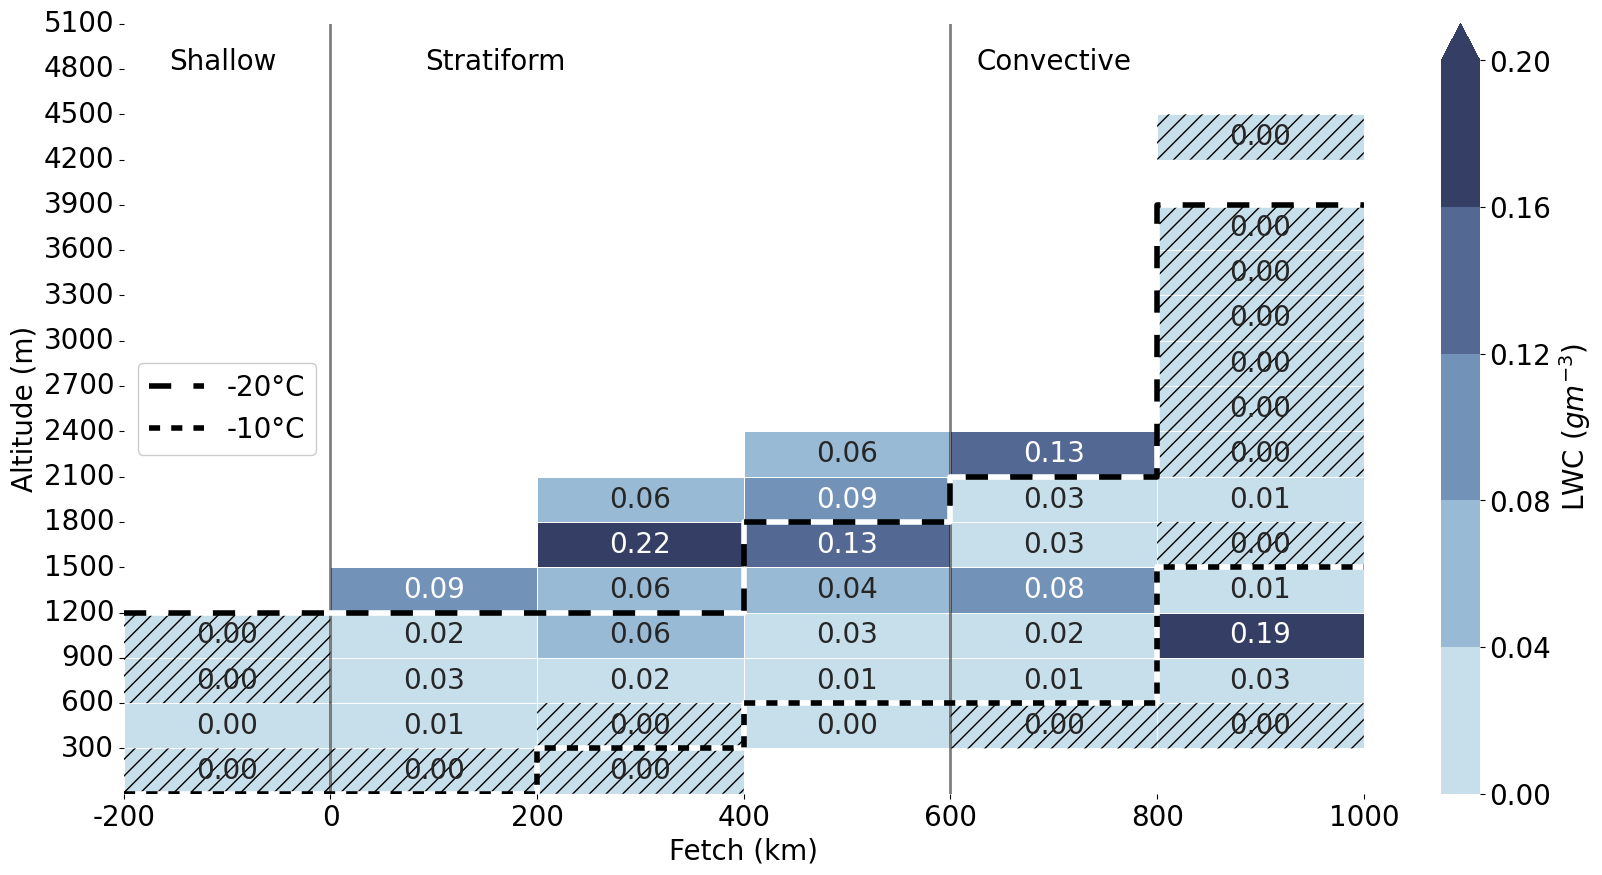

In [65]:
# Heatplot of LWC (LWC)
# y-axis: altitude
# cip_size_mean_df,cip_size_std_df

lwc_lab_dict = {
    'xax_lab':'Fetch (km)',
    'yax_lab':'Altitude (m)',
    'cbar_lab':'LWC ($gm^{-3}$)'
}

savefile = save_path + f'LWC_heatmap_{d_text}_{sample_rate}s.png'


fig,ax = plt.subplots(figsize=(20, 10))

plot_heatmap_ax(lwc_mean_df, lwc_lab_dict, ax, mask_na= True, val=2, annot_df = lwc_mean_df, counts=False, ss=20,ncol=5, v_extend=0.2, altitude_bins=altitude_bins)

plt.pcolor(x, y, hatch_data, hatch='//',hatch_linewidth=1, alpha=0) #Hatching for bins where cdnc is zero

temp_steps(ax,tb,th20,th10) # add temperature lines -10 and -20
add_sect(ax,fs=ss) # add lines and text for sections

plt.savefig(savefile, bbox_inches='tight')
print(f'Plot is saved to: {savefile}')

plt.show()

# Joint ice/water plots

In [66]:
# what is the actual heights for the 450 bin of the 400, 600 and 800 bin?
mas1 = (ds_incloud['altitude_bin']==450).compute() # only the 450 bin
test = ds_incloud.where(mas1,drop=True)
mas11 = (ds_incloud['altitude_bin']==150).compute() # only the 450 bin
test1 = ds_incloud.where(mas11,drop=True)

mas23 = (test1['dist_bin']==-200).compute()
test125 = test1.where(mas23, drop=True)

mas22 = (test1['dist_bin']==0).compute()
test0 = test1.where(mas22, drop=True)

mas21 = (test1['dist_bin']==200).compute()
test200 = test1.where(mas21, drop=True)

mas2 = (test['dist_bin']==400).compute()
test400 = test.where(mas2, drop=True)

mas3 = (test['dist_bin']==600).compute()
test600 = test.where(mas3, drop=True)

mas4 = (test['dist_bin']==800).compute()
test800 = test.where(mas4, drop=True)

print(test125['alt'].values.min())
print(test0['alt'].values.min())
print(test200['alt'].values.min())
print(test400['alt'].values.min())
print(test600['alt'].values.min())
print(test800['alt'].values.min())

285.4697
83.0911
289.40973
301.0474
355.06622
319.81317


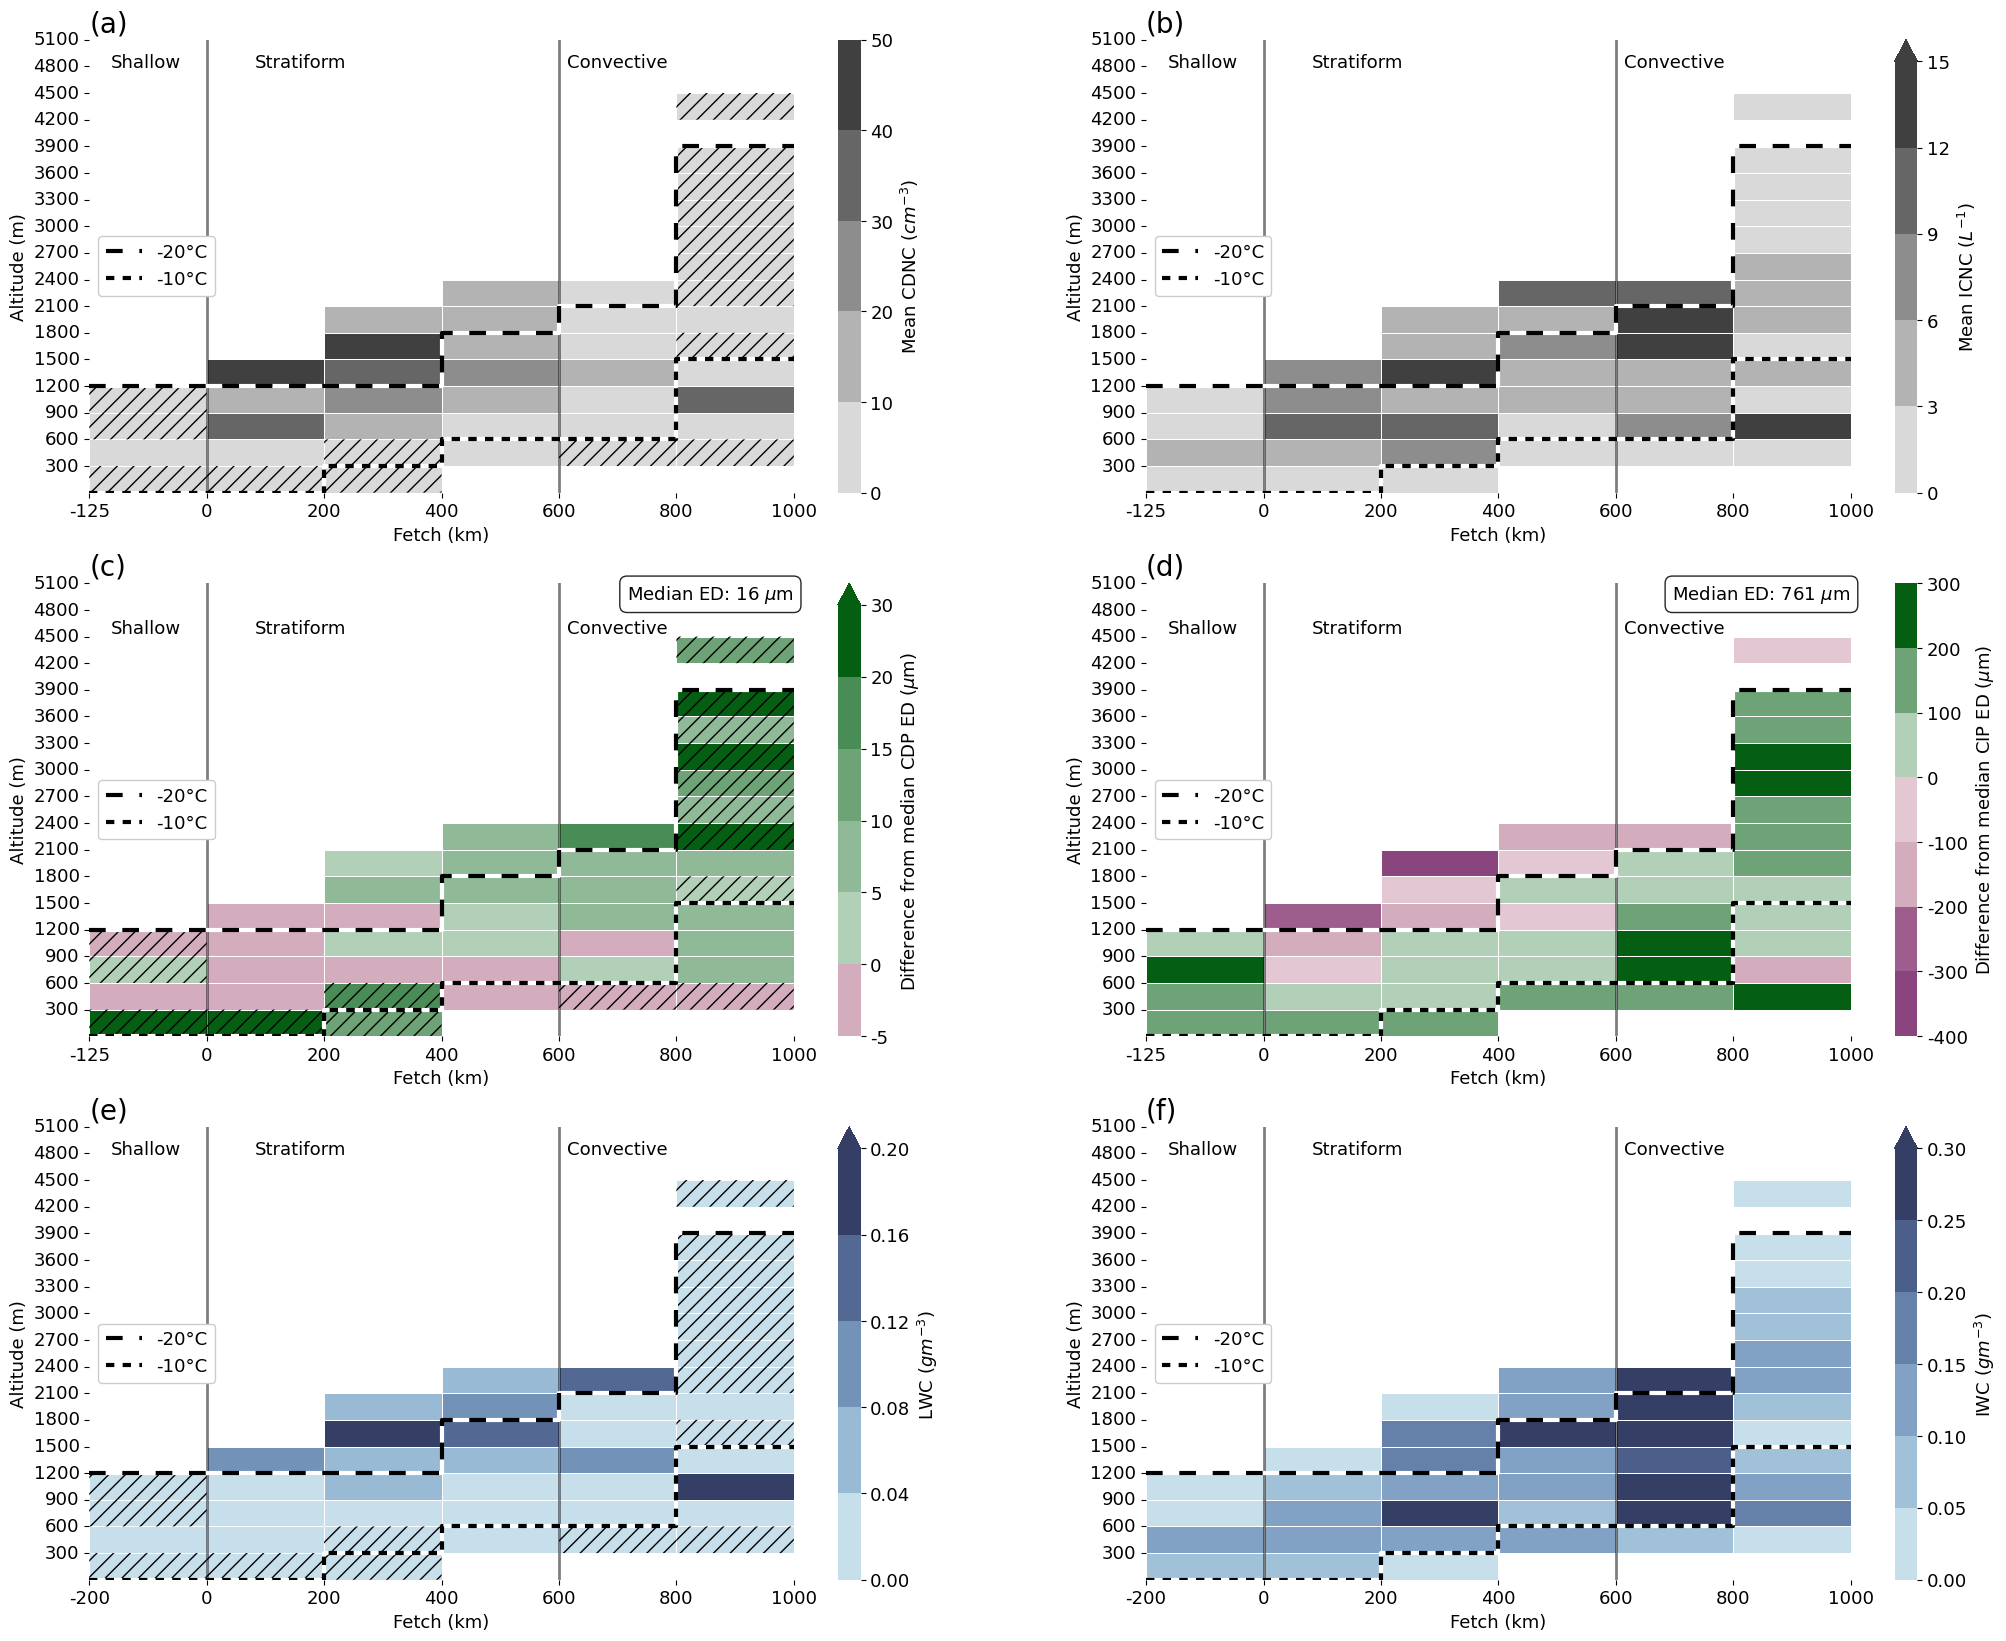

In [67]:
# new version of plot with ED for both cip and cdp
fig, ax = plt.subplots(3,2, figsize=(25, 20))

js=13
vals = x_vals=[0.08,0.3,0.75]

# --- The water plots
# CDNC
plot_heatmap_ax(cdnc_mean_df, cdnc_lab_dict, ax[0,0], mask_na=True, col='Grey', ss=js, ncol=5, v_extend=50, altitude_bins=altitude_bins)
ax[0,0].pcolor(x, y, hatch_data, hatch='//',hatch_linewidth=1, alpha=0) #Hatching for bins where cdnc is zero
ax[0,0].set_title('(a)', loc='left',fontdict={'fontsize': ss})
temp_steps(ax[0,0],tb,th20,th10,lw=3)
add_sect(ax[0,0],x_vals=vals) # add section information

# ED CDP
#plot_heatmap_ax(ed_df, ed_labels_dict, ax[1,0], mask_na=True,col='PurpleGreen',ncol=5,v_extend=50)

plot_heatmap_ax(ed_diff_df_cdp, ed_labels_dict, ax[1,0], mask_na= True, col=cmap_ed,ss=js, ticks=t_ed,v_extend=20, altitude_bins=altitude_bins)
ax[1,0].pcolor(x, y, hatch_data, hatch='//',hatch_linewidth=1, alpha=0) #Hatching for bins where cdnc is zero
ax[1,0].text(
    0.9999, 0.9999,          # x, y in axes coordinates (0..1). 0.01 is near left, 0.99 is near top
    f'{stat.capitalize()} ED: {round(ed_stat_cdp)} $\mu$m',
    transform=ax[1,0].transAxes,
    fontsize=js,
    va='top',            # align text vertically at top
    ha='right',           # align left
    color='black',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85)
)
ax[1,0].set_title('(c)', loc='left',fontdict={'fontsize': ss})
temp_steps(ax[1,0],tb,th20,th10,lw=3)
add_sect(ax[1,0], y_val=0.9,x_vals=vals) # add section information

# LWC
plot_heatmap_ax(lwc_mean_df, lwc_lab_dict, ax[2,0], mask_na=True, val=2, ncol=5, ss=js,v_extend=0.2, altitude_bins=altitude_bins)
ax[2,0].pcolor(x, y, hatch_data, hatch='//',hatch_linewidth=1, alpha=0) #Hatching for bins where cdnc is zero
ax[2,0].set_title('(e)', loc='left',fontdict={'fontsize': ss})
temp_steps(ax[2,0],tb,th20,th10,lw=3)
add_sect(ax[2,0],x_vals=vals) # add section information


# --- The ice plots
# ICNC
plot_heatmap_ax(icnc_mean_df, icnc_lab_dict, ax[0,1], mask_na=True,col='Grey',ncol=5,ss=js, v_extend=15, altitude_bins=altitude_bins)
ax[0,1].set_title('(b)', loc='left',fontdict={'fontsize': ss})
temp_steps(ax[0,1],tb,th20,th10,lw=3)
add_sect(ax[0,1],x_vals=vals) # add section information

# ED CDP
plot_heatmap_ax(ed_diff_df_cip, cip_lab_dict, ax[1,1], mask_na= True, col=cmap_mvd,ss=js, ticks=t_mvd, altitude_bins=altitude_bins)
ax[1,1].text(
    0.9999, 0.9999,          # x, y in axes coordinates (0..1). 0.01 is near left, 0.99 is near top
    f'{stat.capitalize()} ED: {round(ed_stat_cip)} $\mu$m',
    transform=ax[1,1].transAxes,
    fontsize=js,
    va='top',            # align text vertically at top
    ha='right',           # align left
    color='black',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85)
)
ax[1,1].set_title('(d)', loc='left',fontdict={'fontsize': ss})
temp_steps(ax[1,1],tb,th20,th10,lw=3)
add_sect(ax[1,1], y_val=0.9,x_vals=vals) # add section information

# IWC
plot_heatmap_ax(iwc_mean_df, iwc_lab_dict, ax[2,1], mask_na=True, val=2, ncol=6,ss=js,v_extend=0.3, altitude_bins=altitude_bins)
ax[2,1].set_title('(f)', loc='left',fontdict={'fontsize': ss})
temp_steps(ax[2,1],tb,th20,th10,lw=3)
add_sect(ax[2,1],x_vals=vals) # add section information


savefile = save_path + f'ice_liquid_joined_heatmap_{d_text}_{sample_rate}{name_add}.png'
plt.savefig(savefile, bbox_inches='tight', dpi=300)

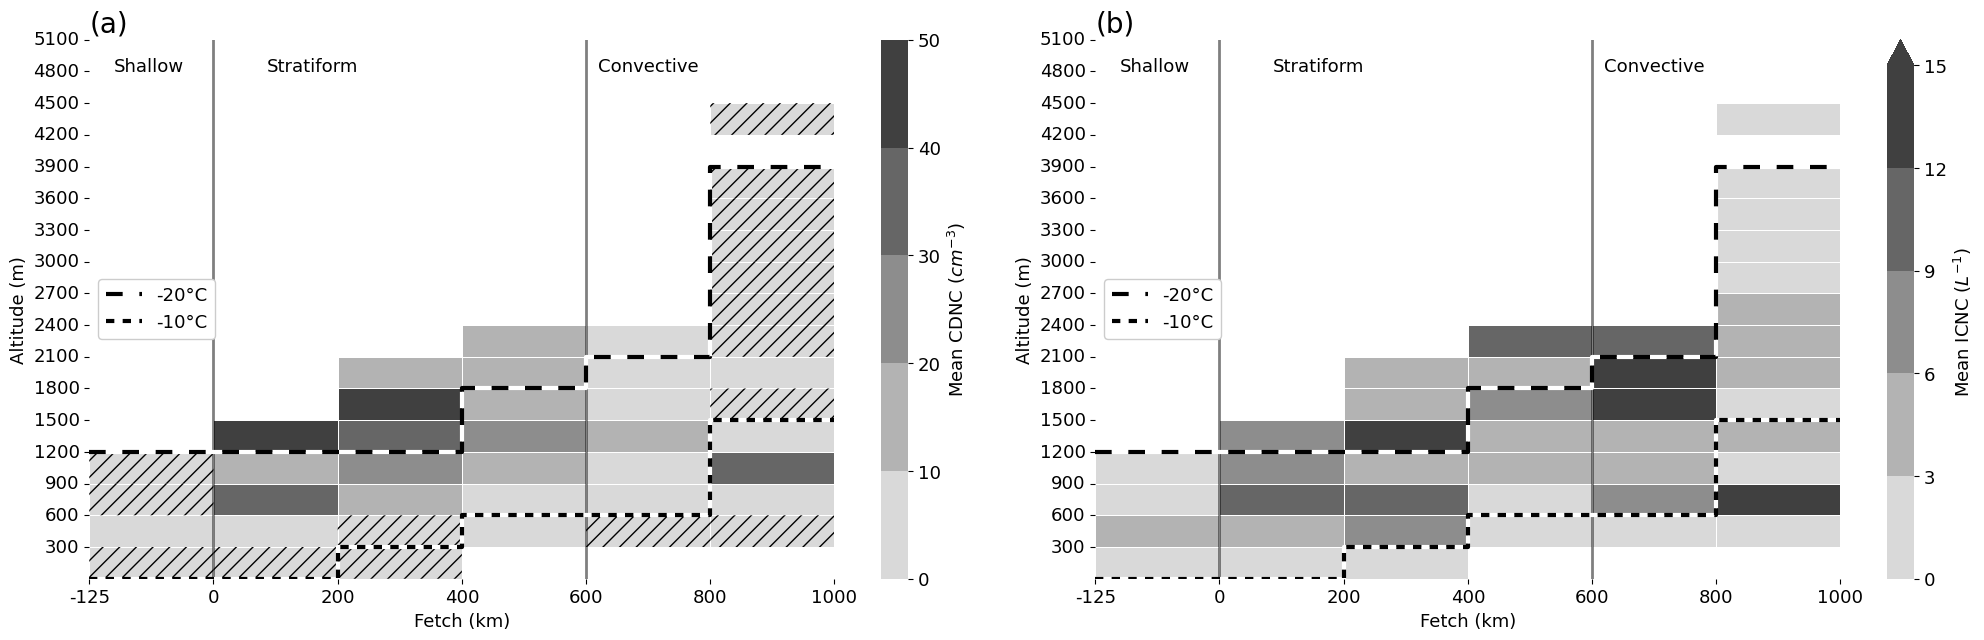

In [68]:
# ---- Joint concentration plots

fig, ax = plt.subplots(1,2, figsize=(25, 7))
plt.subplots_adjust(wspace=0.08)

# CDNC
plot_heatmap_ax(cdnc_mean_df, cdnc_lab_dict, ax[0], mask_na=True, col='Grey', ss=js, ncol=5, v_extend=50, altitude_bins=altitude_bins)
ax[0].pcolor(x, y, hatch_data, hatch='//',hatch_linewidth=1, alpha=0) #Hatching for bins where cdnc is zero
ax[0].set_title('(a)', loc='left',fontdict={'fontsize': ss})
temp_steps(ax[0],tb,th20,th10,lw=3)
add_sect(ax[0],x_vals=vals) # add section information

# --- The ice plots
# ICNC
plot_heatmap_ax(icnc_mean_df, icnc_lab_dict, ax[1], mask_na=True,col='Grey',ncol=5,ss=js, v_extend=15, altitude_bins=altitude_bins)
ax[1].set_title('(b)', loc='left',fontdict={'fontsize': ss})
temp_steps(ax[1],tb,th20,th10,lw=3)
add_sect(ax[1],x_vals=vals) # add section information


savefile = save_path + f'Joint_concentration_{d_text}_{sample_rate}s.png'
plt.savefig(savefile, bbox_inches='tight')

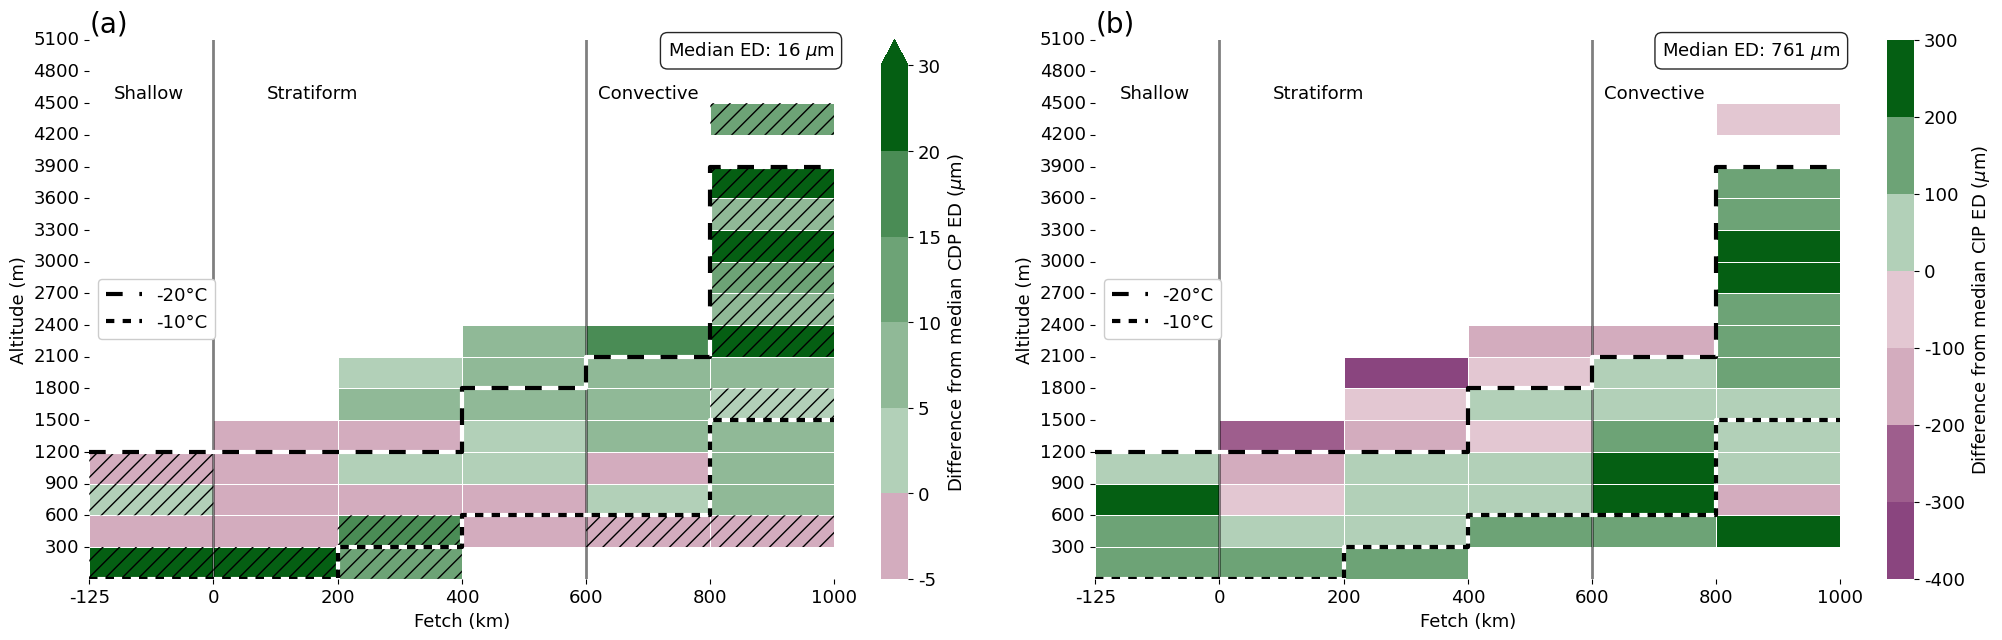

In [69]:
# ---- Joint size plots
fig, ax = plt.subplots(1,2, figsize=(25, 7))
plt.subplots_adjust(wspace=0.08)

# ED CDP
plot_heatmap_ax(ed_diff_df_cdp, ed_labels_dict, ax[0], mask_na= True, col=cmap_ed,ss=js, ticks=t_ed,v_extend=20, altitude_bins=altitude_bins)
ax[0].pcolor(x, y, hatch_data, hatch='//',hatch_linewidth=1, alpha=0) #Hatching for bins where cdnc is zero
ax[0].text(
    0.9999, 0.9999,          # x, y in axes coordinates (0..1). 0.01 is near left, 0.99 is near top
    f'{stat.capitalize()} ED: {round(ed_stat_cdp)} $\mu$m',
    transform=ax[0].transAxes,
    fontsize=js,
    va='top',            # align text vertically at top
    ha='right',           # align left
    color='black',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85)
)
ax[0].set_title('(a)', loc='left',fontdict={'fontsize': ss})
temp_steps(ax[0],tb,th20,th10,lw=3)
add_sect(ax[0], y_val=0.9,x_vals=vals) # add section information



# ED CDP
plot_heatmap_ax(ed_diff_df_cip, cip_lab_dict, ax[1], mask_na= True, col=cmap_mvd,ss=js, ticks=t_mvd, altitude_bins=altitude_bins)
ax[1].text(
    0.9999, 0.9999,          # x, y in axes coordinates (0..1). 0.01 is near left, 0.99 is near top
    f'{stat.capitalize()} ED: {round(ed_stat_cip)} $\mu$m',
    transform=ax[1].transAxes,
    fontsize=js,
    va='top',            # align text vertically at top
    ha='right',           # align left
    color='black',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85)
)
ax[1].set_title('(b)', loc='left',fontdict={'fontsize': ss})
temp_steps(ax[1],tb,th20,th10,lw=3)
add_sect(ax[1], y_val=0.9,x_vals=vals) # add section information


savefile = save_path + f'Joint_size_{d_text}_{sample_rate}s.png'
plt.savefig(savefile, bbox_inches='tight')


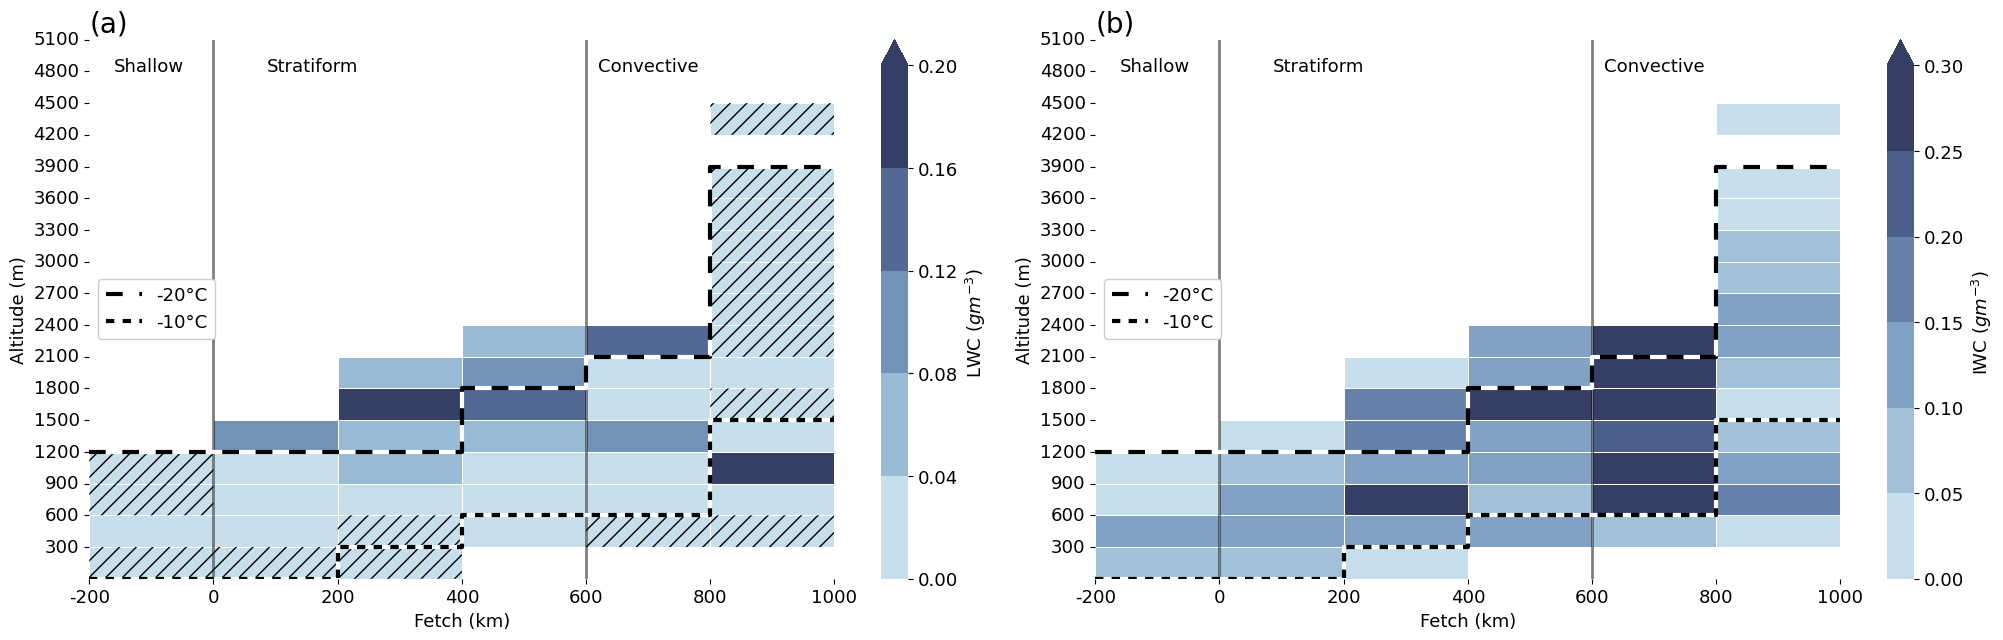

In [70]:
# ---- Joint water content plot
fig, ax = plt.subplots(1,2, figsize=(25, 7))
plt.subplots_adjust(wspace=0.08)

# LWC
plot_heatmap_ax(lwc_mean_df, lwc_lab_dict, ax[0], mask_na=True, val=2, ncol=5, ss=js,v_extend=0.2, altitude_bins=altitude_bins)
ax[0].pcolor(x, y, hatch_data, hatch='//',hatch_linewidth=1, alpha=0) #Hatching for bins where cdnc is zero
ax[0].set_title('(a)', loc='left',fontdict={'fontsize': ss})
temp_steps(ax[0],tb,th20,th10,lw=3)
add_sect(ax[0],x_vals=vals) # add section information

# IWC
plot_heatmap_ax(iwc_mean_df, iwc_lab_dict, ax[1], mask_na=True, val=2, ncol=6,ss=js,v_extend=0.3, altitude_bins=altitude_bins)
ax[1].set_title('(b)', loc='left',fontdict={'fontsize': ss})
temp_steps(ax[1],tb,th20,th10,lw=3)
add_sect(ax[1],x_vals=vals) # add section information



savefile = save_path + f'Joint_WaterContent_{d_text}_{sample_rate}s.png'
plt.savefig(savefile, bbox_inches='tight')

# SLF per flight and separating different "regions"

In [71]:
#all flights
flights = np.unique(ds_incloud['islasid'].values)
ss=20
count = len(flights)

# get x tick-labels from distance bin values
dists = np.unique(ds_incloud['dist_bin'].values)
dists[0]=-125 # first one should be the lowest distance value

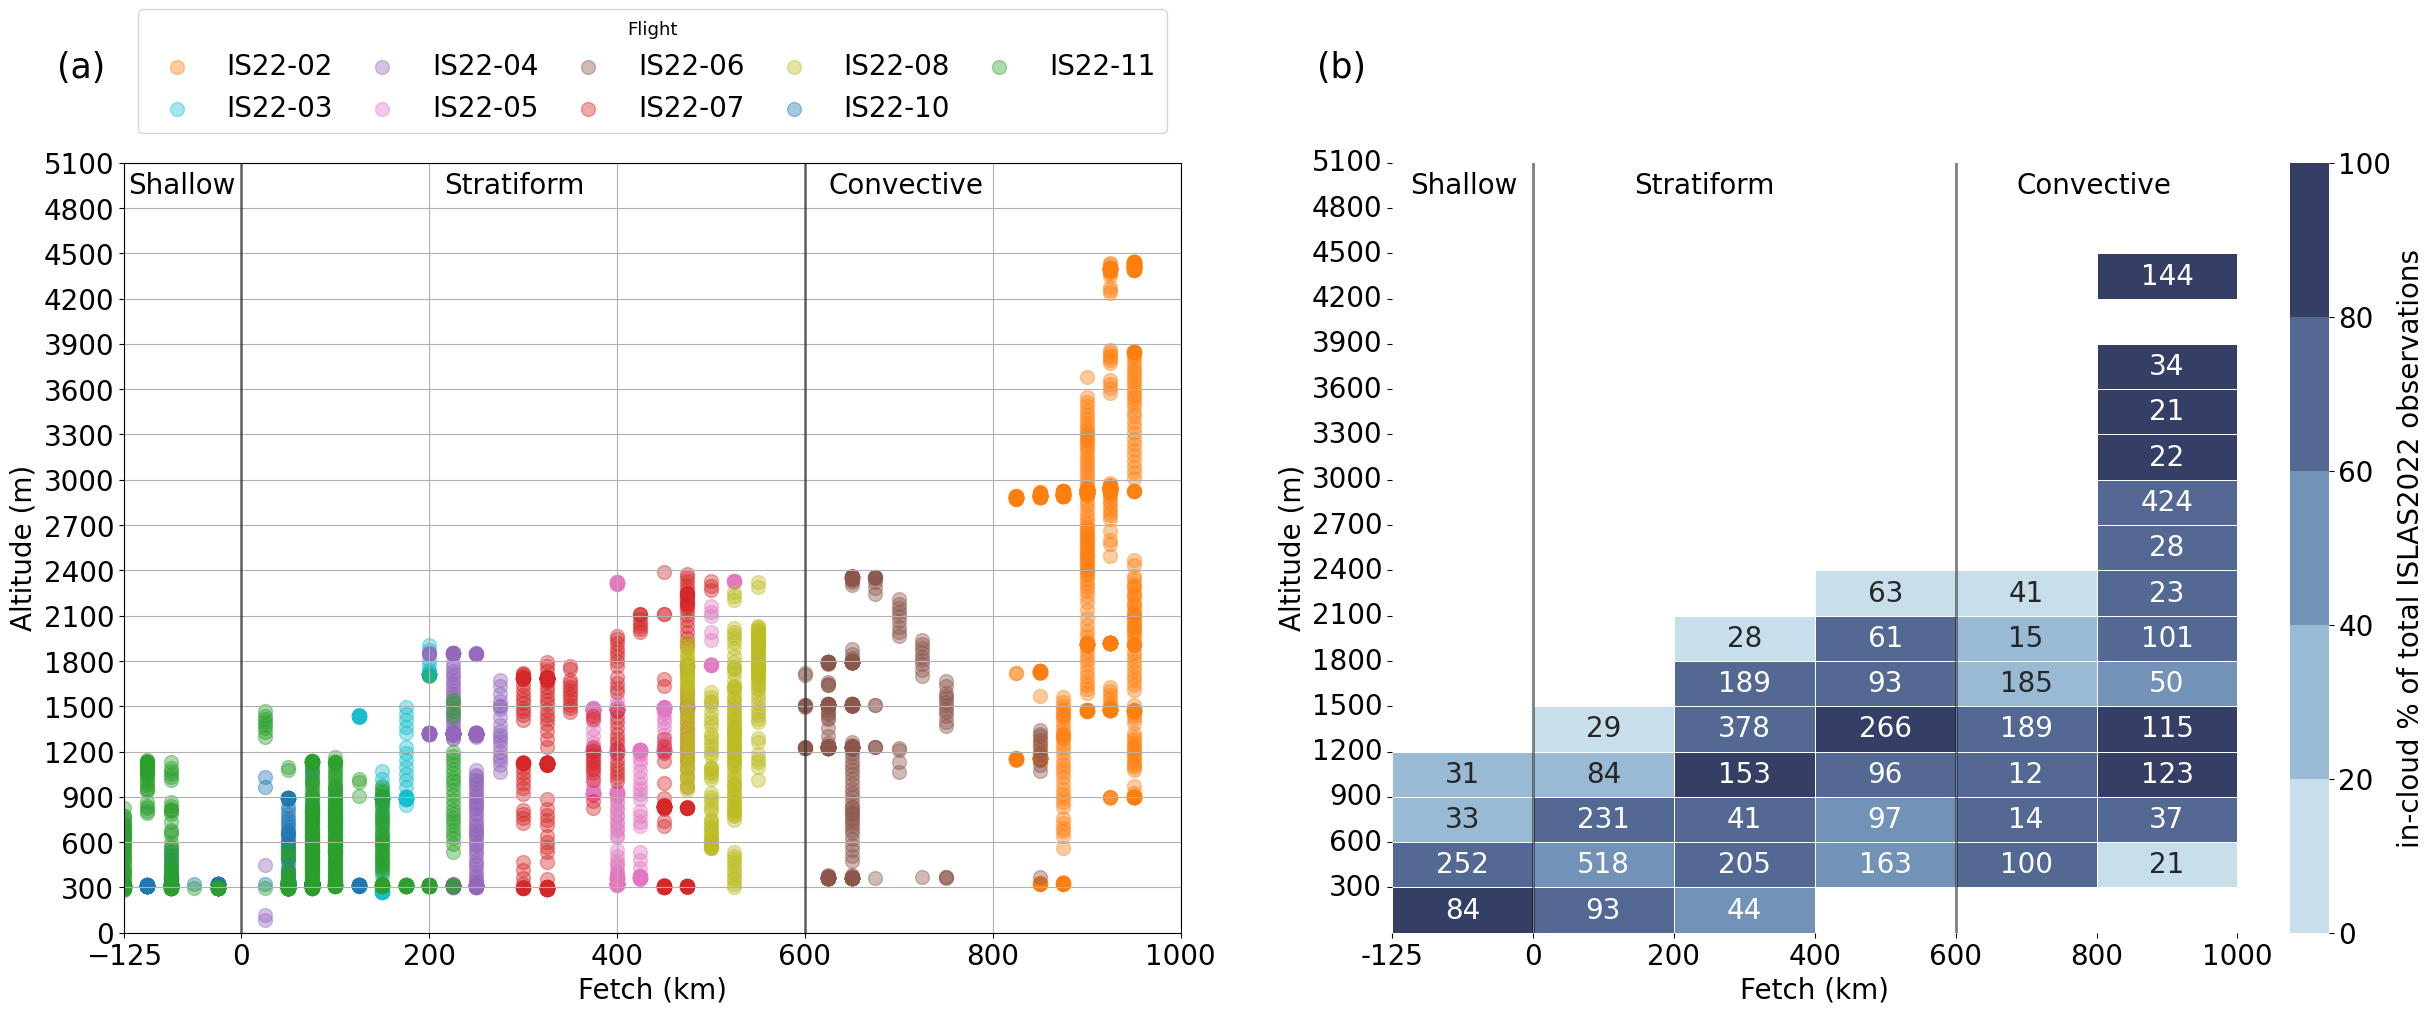

In [72]:
# Version 2 of the figure (without SLF information)


# --- Set up figure
fig, ax = plt.subplots(1,2, figsize=(30, 10))

# Set figure (a) to be the distribution ob observations per flight
add_sect(ax[0],fs=ss,y_val=0.97,x_vals=[0.055,0.37,0.74],xv_vals=[0,600]) # add region separators

for i, flight in enumerate(flights):
    mask = (ds_incloud['islasid']==flight).compute()
    flight_ds=ds_incloud.where(mask, drop=True)

    color = c_flights[flight] 

    # WC plots
    ax[0].scatter(flight_ds['distance_from_ice'], flight_ds['alt'],marker='o',alpha=0.4,s=100, color=color, label=flight)

ax[0].set_ylabel('Altitude (m)', size=ss)
ax[0].set_xlabel(f'Fetch ({ds_incloud['distance_from_ice'].attrs['units']})', size=ss)

# set decorators
full_dists = np.append(dists, 1000)
ax[0].set_xticks(full_dists)
ax[0].set_xlim(full_dists[0], full_dists[-1])
ax[0].set_yticks(np.arange(0,5400,300))
ax[0].set_ylim(0)
ax[0].tick_params(axis='both', labelsize=ss)
ax[0].grid(True)
 

# Add legend to the top of the plot
leg = ax[0].legend(bbox_to_anchor = (0., 1.02, 1., .102), loc='lower left', ncols=5, mode="expand",fontsize=ss, title="Flight")

# Plot (b) is the number of observations per bin in the composite
incloud_labels_dict = {
    'xax_lab':'Fetch (km)',
    'yax_lab':'Altitude (m)',
    'cbar_lab':'in-cloud % of total ISLAS2022 observations'
}
# Total number of observations (5s)
# in-cloud
plot_heatmap_ax(count_perc_df, incloud_labels_dict, ax[1], mask_na=True, val=0, annot_df = count_df,ss=ss,counts=True,ncol=5, altitude_bins=altitude_bins)
add_sect(ax[1],y_val=0.97,x_vals = [0.085,0.37,0.83],fs=ss) # add lines and text for sections

# set (a) and (b) to plots
ax[1].set_title('(b)', y=1.1, x=-0.06,fontdict={'fontsize': 25}) # testing
ax[0].set_title('(a)', y=1.1, x=-0.04,fontdict={'fontsize': 25})

savefile = save_path + f'{sample_rate}sobs_flight_composite.png'
plt.savefig(savefile,dpi=300, bbox_inches='tight')

In [82]:
print(np.nanmin(count_df.values))
print(np.nanmax(count_df.values))
print(np.nanmean(count_df.values))

12.0
518.0
114.67441860465117


In [83]:
count_df.sum()

dist_bin
-125     400.0
 0       955.0
 200    1038.0
 400     839.0
 600     556.0
 800    1143.0
dtype: float64

In [ ]:
# Cloud regions without the flight SLF (for 200 km dist bin!)

# --- Set up figure
fig, ax = plt.subplots(1,1, figsize=(20, 10))

# set the colored spans for each region
plt.axvspan(-200,0,facecolor='blue', alpha=0.05)
plt.axvspan(0,600, facecolor='green',  alpha=0.05)
plt.axvspan(600,1000, facecolor='lightslategrey', alpha=0.05)

add_sect(ax,fs=ss,x_vals=[0.05,0.35,0.75],xv_vals=[0,600]) # add region separators

# Plot decorations   
ax.set_ylabel(f'Altitude (m)', size=ss)
ax.set_xlabel(f'Fetch (km)', size=ss)
ax.set_xticks([0,200,400,600,800,1000])
ax.set_xlim(-200,1000)
ax.set_yticks(np.arange(0,5700,300))
ax.set_ylim(0)
ax.tick_params(axis='both', labelsize=ss)
#ax.grid(True)

savefile = save_path + f'cloud_areas.png'
plt.savefig(savefile, bbox_inches='tight', dpi=300)

## Comparing some values between Heymsfield and Brown and Francis

In [ ]:
# set sizing for plots:
js = 15

In [ ]:
vals = x_vals=[0.08,0.3,0.82] # location of region text in plot

# IWC B1

# from Brown (IWC100)
data_groupedx = ds_incloud_bf['IWC100'].groupby('dist_bin')
data_groupedxy = data_groupedx.map(lambda group: group.groupby('altitude_bin').mean())
iwc_b_mean_df = data_groupedxy.to_dataframe().unstack() 
iwc_b_mean_df = iwc_b_mean_df.T.reset_index(level=0, drop = True) # - transpose to get altitude on y-axis - reset index and drop outer index(base_time)
iwc_b_mean_df = iwc_b_mean_df.reindex(bin_labels, fill_value=np.nan).iloc[::-1] # fill with 0 - reverse order of altitudes

# adjust for plotting: remove the two topmost empthy altitude layers
iwc_b_mean_df = iwc_b_mean_df.iloc[2:]

# Updating lab_dict for brown IWC
iwc_b_lab_dict = {'xax_lab': 'Fetch (km)',
                  'yax_lab': 'Altitude (m)',
                  'cbar_lab': 'IWC (BF95) ($gm^{-3}$)'}


# Updating lab_dict for Heymsfield IWC
iwc_h_lab_dict = {'xax_lab': 'Fetch (km)',
                  'yax_lab': 'Altitude (m)',
                  'cbar_lab': 'IWC (H10) ($gm^{-3}$)'}


# calculate difference between brown and francis
iwc_diff_df = iwc_mean_df-iwc_b_mean_df

# lab_dict for difference
iwc_diff_lab_dict = {'xax_lab': 'Fetch (km)',
                  'yax_lab': 'Altitude (m)',
                  'cbar_lab': 'IWC (H10-BF95) ($gm^{-3}$)'}


# 3 panel figure with gridspec
fig = plt.figure(figsize=(25, 15))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[1, 1])
gs.update(wspace=0.2, hspace=0.3)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, :])

# Heymsfield
plot_heatmap_ax(iwc_mean_df, iwc_h_lab_dict, ax_a, mask_na=True, val=2,annot_df = iwc_mean_df, ncol=6,ss=js,v_extend=0.3, altitude_bins=altitude_bins)
ax_a.set_title('(a)', loc='left',fontdict={'fontsize': ss})
add_sect(ax_a,x_vals=vals) # add section information

# Brown
plot_heatmap_ax(iwc_b_mean_df, iwc_b_lab_dict, ax_b, mask_na=True, val=2, annot_df = iwc_b_mean_df,ncol=6,ss=js,v_extend=0.3, altitude_bins=altitude_bins)
ax_b.set_title('(b)', loc='left',fontdict={'fontsize': ss})
add_sect(ax_b,x_vals=vals) # add section information

# difference
plot_heatmap_ax(iwc_diff_df, iwc_diff_lab_dict, ax_c, mask_na=True, annot_df = iwc_diff_df, val=2, ncol=6,ss=js, altitude_bins=altitude_bins)
ax_c.set_title('(c)', loc='left',fontdict={'fontsize': ss})
add_sect(ax_c,x_vals=vals) # add section information



savefile = save_path + f'MassDim_param_difference_IWC_{d_text}_{sample_rate}s.png'
plt.savefig(savefile, bbox_inches='tight', dpi=300)


In [ ]:
# TWC B2

# from Brown ()
# TWC
twc_var = 'TWC_BF95'

data_groupedx = ds_incloud_bf[twc_var].groupby('dist_bin')
data_groupedxy = data_groupedx.map(lambda group: group.groupby('altitude_bin').mean())
twc_b_mean_df = data_groupedxy.to_dataframe().unstack() 
twc_b_mean_df = twc_b_mean_df.T.reset_index(level=0, drop = True) # - transpose to get altitude on y-axis - reset index and drop outer index(base_time)
twc_b_mean_df = twc_b_mean_df.reindex(bin_labels, fill_value=np.nan).iloc[::-1] # fill with 0 - reverse order of altitudes

# the df includes empthy rows on top, trop the two first ones for cleaner plots
twc_b_mean_df = twc_b_mean_df.iloc[2:]


# Updating lab_dict for brown IWC
twc_b_lab_dict = {'xax_lab': 'Fetch (km)',
                  'yax_lab': 'Altitude (m)',
                  'cbar_lab': 'Mean TWC (BF95) ($gm^{-3}$)'}

# Updating lab_dict for Heymsfield IWC
twc_h_lab_dict = {'xax_lab': 'Fetch (km)',
                  'yax_lab': 'Altitude (m)',
                  'cbar_lab': 'Mean TWC (H10) ($gm^{-3}$)'}


# calculate difference between brown and francis
twc_diff_df = twc_mean_df-twc_b_mean_df

# lab_dict for difference
twc_diff_lab_dict = {'xax_lab': 'Fetch (km)',
                  'yax_lab': 'Altitude (m)',
                  'cbar_lab': 'TWC (H10-BF95) ($gm^{-3}$)'}


# 3 panel figure with GridSpec
fig = plt.figure(figsize=(25, 15))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[1, 1])
gs.update(wspace=0.2, hspace=0.3)  # horisontal og vertikal avstand mellom delplott

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, :])

# Heymsfield
plot_heatmap_ax(twc_mean_df, twc_h_lab_dict, ax_a, mask_na=True, val=2, annot_df = twc_mean_df,counts=False, ss=js,ncol=6, v_extend=0.3, altitude_bins=altitude_bins)
ax_a.set_title('(a)', loc='left',fontdict={'fontsize': ss})
add_sect(ax_a,x_vals=vals) # add section information

# Brown
plot_heatmap_ax(twc_b_mean_df, twc_b_lab_dict, ax_b, mask_na=True, val=2, annot_df = twc_b_mean_df,counts=False, ss=js,ncol=6, v_extend=0.3, altitude_bins=altitude_bins)
ax_b.set_title('(b)', loc='left',fontdict={'fontsize': ss})
add_sect(ax_b,x_vals=vals) # add section information

# difference
plot_heatmap_ax(twc_diff_df, twc_diff_lab_dict, ax_c, mask_na=True, annot_df = twc_diff_df, val=2, ncol=6,ss=js, altitude_bins=altitude_bins)
ax_c.set_title('(c)', loc='left',fontdict={'fontsize': ss})
add_sect(ax_c,x_vals=vals) # add section information

savefile = save_path + f'MassDim_param_difference_TWC_{d_text}_{sample_rate}s.png'
plt.savefig(savefile, bbox_inches='tight', dpi=300)


In [ ]:
# SLF B3
# from Brown (SLFB95)
slf_b_mean_df = create_distribution_df(ds_incloud_bf['SLF_BF95'],'dist_bin','altitude_bin','mean',val=0, mask=incloud_mask)

# adjust for plotting: remove the two topmost empthy altitude layers
slf_b_mean_df = slf_b_mean_df.iloc[2:]

# Updating lab_dict for brown IWC
slf_b_lab_dict = {'xax_lab': 'Fetch (km)',
                  'yax_lab': 'Altitude (m)',
                  'cbar_lab': 'Mean SLF (BF95) (%)'}


# Updating lab_dict for Heymsfield IWC
slf_h_lab_dict = {'xax_lab': 'Fetch (km)',
                  'yax_lab': 'Altitude (m)',
                  'cbar_lab': 'Mean SLF (H10) (%)'}


# calculate difference between brown and francis
slf_diff_df = slf_mean_df-slf_b_mean_df

# lab_dict for difference
slf_diff_lab_dict = {'xax_lab': 'Fetch (km)',
                  'yax_lab': 'Altitude (m)',
                  'cbar_lab': 'SLF (H10-BF95) (%)'}


# 3 panel figure with GridSpec
fig = plt.figure(figsize=(25, 15))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[1, 1])
gs.update(wspace=0.2, hspace=0.3)  # horisontal og vertikal avstand mellom delplott

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, :]) 

# Heymsfield
plot_heatmap_ax(slf_mean_df, slf_h_lab_dict, ax_a, mask_na=True, val=0, annot_df = slf_mean_df, counts = False, ss=js,ncol=7,v_extend=70, altitude_bins=altitude_bins)
ax_a.set_title('(a)', loc='left',fontdict={'fontsize': ss})
add_sect(ax_a,x_vals=vals) # add section information

# Brown
plot_heatmap_ax(slf_b_mean_df, slf_b_lab_dict, ax_b, mask_na=True, val=0, annot_df = slf_b_mean_df, counts = False, ss=js,ncol=7,v_extend=70, altitude_bins=altitude_bins)
ax_b.set_title('(b)', loc='left',fontdict={'fontsize': ss})
add_sect(ax_b,x_vals=vals) # add section information

# difference
plot_heatmap_ax(slf_diff_df, slf_diff_lab_dict, ax_c, mask_na=True, val=0, annot_df = slf_diff_df, counts = False, ss=js,ticks = np.array([-20,-15,-10,-5,0]),reverse = True, altitude_bins=altitude_bins)
ax_c.set_title('(c)', loc='left',fontdict={'fontsize': ss})
add_sect(ax_c,x_vals=vals) # add section information

savefile = save_path + f'MassDim_param_difference_SLF_{d_text}_{sample_rate}s.png'
plt.savefig(savefile, bbox_inches='tight', dpi=300)

In [ ]:
# Over ice

# --- Set up figure
fig, ax = plt.subplots(1,1, figsize=(9.3, 16))

plt.axvspan(-125,0,facecolor='blue', alpha=0.05)
plt.text(-120,4500,'Over ice', fontsize=ss)

ax.set_ylabel(f'Altitude ({flight_ds['alt'].attrs['units']})', size=ss)
ax.set_xlabel(f'Fetch ({flight_ds['distance_from_ice'].attrs['units']})', size=ss)
ax.set_xticks(dists)
ax.set_xlim(dists[0], dists[1])
ax.set_yticks(np.arange(0,5000,300))
ax.set_ylim(0)
ax.tick_params(axis='both', labelsize=ss)
ax.grid(True)

savefile = save_path + f'images_over_sea_ice.png'
plt.savefig(savefile, bbox_inches='tight')

In [ ]:
# Stratiform off ice

# --- Set up figure
fig, ax = plt.subplots(1,1, figsize=(19, 16))

plt.axvspan(0,dist_bin_size*sep, facecolor='green',  alpha=0.05)
plt.text(5,4500,'Stratiform off ice', fontsize=ss)
   
ax.set_ylabel(f'Altitude ({flight_ds['alt'].attrs['units']})', size=ss)
ax.set_xlabel(f'Fetch ({flight_ds['distance_from_ice'].attrs['units']})', size=ss)
ax.set_xticks(dists)
ax.set_xlim(dists[1], dist_bin_size*sep)
ax.set_yticks(np.arange(0,5000,300))
ax.set_ylim(0)
ax.tick_params(axis='both', labelsize=ss)
ax.grid(True)

savefile = save_path + f'images_stratiform_off_ice.png'
plt.savefig(savefile, dpi=300)


In [ ]:
# Stratiform deepening into convenctive

# --- Set up figure
fig, ax = plt.subplots(1,1, figsize=(28.5, 16))

plt.axvspan(dist_bin_size*sep,dists[-1], facecolor='red', alpha=0.05)
plt.text(dist_bin_size*sep+5,4500,'Stratiform deepening into convective', fontsize=ss)
   
ax.set_ylabel(f'Altitude ({flight_ds['alt'].attrs['units']})', size=ss)
ax.set_xlabel(f'Fetch ({flight_ds['distance_from_ice'].attrs['units']})', size=ss)
ax.set_xticks(dists)
ax.set_xlim(dist_bin_size*sep,dists[-1])
ax.set_yticks(np.arange(0,5000,300))
ax.set_ylim(0)
ax.tick_params(axis='both', labelsize=ss)
ax.grid(True)

savefile = save_path + f'images_stratiform_deepening.png'
plt.savefig(savefile, bbox_inches='tight',dpi=300)

In [ ]:
# Mature convective

# --- Set up figure
fig, ax = plt.subplots(1,1, figsize=(28.5, 16))

plt.axvspan(dists[-1],dists[-1]+dist_bin_size, facecolor='lightslategrey', alpha=0.05)
plt.text(dists[-1]+5,4500,'Convective', fontsize=ss)

ax.set_ylabel(f'Altitude ({flight_ds['alt'].attrs['units']})', size=ss)
ax.set_xlabel(f'Fetch ({flight_ds['distance_from_ice'].attrs['units']})', size=ss)
ax.set_xticks(dists)
ax.set_xlim(dists[-1],dists[-1]+dist_bin_size)
ax.set_yticks(np.arange(0,5000,300))
ax.set_ylim(0)
ax.tick_params(axis='both', labelsize=ss)
ax.grid(True)

savefile = save_path + f'images_convective.png'
plt.savefig(savefile, bbox_inches='tight')

### Times for extracting CIP images


REMEMBER THAT YOU HAVE NOT FIXED THE CONNECTION TO DISTANCE BIN SIZE SELECTION BELOW THIS SUBHEADER

In [ ]:
np.unique(ds_incloud['dist_bin'].values)

In [ ]:
# at what times are we at what distances from sea ice? (Set up for 200 km distance bins)
# distances
#mask = (ds_incloud['dist_bin']==-200).compute() 
#mask = (ds_incloud['dist_bin']==0).compute() 
mask = (ds_incloud['dist_bin']==200).compute() 
#mask = (ds_incloud['dist_bin']==400).compute() 
#mask = (ds_incloud['dist_bin']==600).compute() 
#mask = (ds_incloud['dist_bin']==800).compute() 

test = ds_incloud.where(mask, drop=True)

# altitudes
altmask1 = (test['altitude_bin']==150).compute()
alt150 = test.where(altmask1,drop=True)

altmask2 = (test['altitude_bin']==450).compute()
alt450 = test.where(altmask2,drop=True)

altmask3 = (test['altitude_bin']==750).compute()
alt750 = test.where(altmask3,drop=True)

altmask4 = (test['altitude_bin']==1050).compute()
alt1050 = test.where(altmask4,drop=True)

altmask5 = (test['altitude_bin']==1350).compute()
alt1350 = test.where(altmask5,drop=True)

altmask6 = (test['altitude_bin']==1650).compute()
alt1650 = test.where(altmask6,drop=True)

altmask7 = (test['altitude_bin']==1950).compute()
alt1950 = test.where(altmask7,drop=True)

altmask8 = (test['altitude_bin']==2250).compute()
alt2250 = test.where(altmask8,drop=True)

altmask9 = (test['altitude_bin']==2550).compute()
alt2550 = test.where(altmask9,drop=True)

altmask10 = (test['altitude_bin']==2850).compute()
alt2850 = test.where(altmask10,drop=True)

altmask11 = (test['altitude_bin']==3150).compute()
alt3150 = test.where(altmask11,drop=True)

altmask12 = (test['altitude_bin']==3450).compute()
alt3450 = test.where(altmask12,drop=True)

altmask13 = (test['altitude_bin']==3750).compute()
alt3750 = test.where(altmask13,drop=True)

altmask14 = (test['altitude_bin']==4050).compute()
alt4050 = test.where(altmask14,drop=True)

altmask15 = (test['altitude_bin']==4350).compute()
alt4350 = test.where(altmask15,drop=True)

altmask16 = (test['altitude_bin']==4650).compute()
alt4650 = test.where(altmask16,drop=True)

altmask17 = (test['altitude_bin']==4950).compute()
alt4950 = test.where(altmask17,drop=True)



In [ ]:
#alt150['time'].values
#alt450['time'].values
#alt750['time'].values
alt1050['time'].values
#alt1350['time'].values
#alt1650['time'].values
#alt1950['time'].values
#alt2250['time'].values
#alt2550['time'].values
#alt2850['time'].values
#alt3150['time'].values
#alt3450['time'].values
#alt3750['time'].values
#alt4050['time'].values
#alt4350['time'].values
#alt4650['time'].values
#alt4950['time'].values

# Size distributions

In [ ]:
def cdp_norm_Nt(ds):
    """ Log-normalized particle number per bin for CDP observations

    Parameters
    ----------
    ds
        A xarray.DataSet containing the parameters: 
        -'CDP Bin Particle Count': 
        -'SV': Sample volume
        -'Size': Upper size edge of bin
        -'Bin min': Lower size edge of bin
        This value is already normalized by bin width, but not log-normalized. 
    
    Returns
    -------
    cdp_part_norm
        A xarray.DataArray that contains the log-normalized values of the CIP number concentration

    """
    import numpy as np
    
    # adjust the raw particle count by sample volume
    # log normalize the cdp particle counts to width (Size = upper limit of bin, Bin_min = lower limit of bin)
    # bin units are in micrometers and must be adjusted to m
    ds['CDP count log norm'] = (ds['CDP Bin Particle Count']/ds['SV'])/(np.log(ds['Size'][0]*1.e-6)-np.log(ds['Bin_min'][0]*1.e-6))
    
    return ds


In [ ]:
# Testing dataselections

region_dict = {'over_ice':[-125],
               'strat_off':[0,125,250],
               'strat_off': [375,500,625],
               'convective': [750,875]}


dist_mask = (ds_incloud['dist_bin'].isin(region_dict['over_ice'])).compute()
dist_ds = ds_incloud.where(dist_mask, drop=True)

dist_ds = cdp_norm_Nt(dist_ds)
dist_sum = dist_ds['CDP count log norm'].sum('time') # the sum of particle counts per bin

#np.unique(dist_ds['dist_bin'].values)  # testing which distance bins is chosen

def alt_perc(dist_ds):
    # selecting alt
    # get the data as multiple datasets: separate by altitude bin
    alt_list = np.unique(dist_ds['altitude_bin'].values)

    alt_ds_list = []

    for alt in alt_list:
        #print(alt)
        alt_mask = (dist_ds['altitude_bin']==alt).compute()
        alt_ds = dist_ds.where(alt_mask, drop=True)

        sum_c_perc = alt_ds['CDP count log norm'].sum('time').values/dist_sum.values # the sum of particle counts per bin
        alt_ds_list.append(sum_c_perc)

    # get the percentage of total number of observations per altitude as dataframe
    cdp_alt_perc_df = pd.DataFrame(data=alt_ds_list, index = alt_list, columns=np.unique(dist_ds['Size'].values))

    return cdp_alt_perc_df



In [ ]:
# -- Number concentration hist plot: 
# select one of the distance regions
region_dict = {'over_ice':[-125],
               'strat_off':[0,125,250],
               'strat_deep': [375,500,625],
               'convective': [750,875]}


def plot_NTdist(dist_ds, category, ax, layers=False):
    dist_ds = cdp_norm_Nt(dist_ds)
    # Get the normalized values for plotting (from functions in numb_conc)
    cip_part_norm, cip_median = numb_conc.cip_mean_norm_Nt(dist_ds)
   
    cdp_part_norm_mean=dist_ds['CDP count log norm'].mean('time') 
    cdp_counts, cdp_bins, cdp_patches = ax.hist(dist_ds['Size'][0].values, weights = cdp_part_norm_mean.values, bins=30, label = "CDP", histtype='bar')
    
    
    ax.hist(dist_ds['MIDBINS'][0].values[2:], weights = cip_part_norm.values[2:], bins=61, label = "CIP", color='orange',histtype='bar')
    cip_counts, cip_bins, cip_patches =ax.hist(dist_ds['MIDBINS'][0].values[:3], weights = cip_part_norm.values[:3], bins=3, label = "CIP below 100 $\mu$m", histtype='bar',hatch='x',alpha=0.3,edgecolor='orange', fill=False)
   
    
    if layers == False:
        ax.set_title(f'{category}')
        ax.legend()

        ax.set_ylabel('dN/dlogDp (#/$m^4$)')
        ax.set_xlabel('Size ($\mu$m)')
    
    return cdp_counts, cdp_bins, cdp_patches, cip_counts, cip_bins, cip_patches

fig, ax = plt.subplots(2,4,figsize = (15,10), sharex=True, sharey=True)

# ALL Altitudes
# over sea ice
dist_mask = (ds_incloud['dist_bin'].isin(region_dict['over_ice'])).compute()
dist_si_ds = ds_incloud.where(dist_mask, drop=True)
si_cdp_counts, si_cdp_bins, si_cdp_patches, si_cip_counts, si_cip_bins, si_cip_patches = plot_NTdist(dist_si_ds,'a) Over sea ice', ax[0,0])
cdp_alt_perc_df = alt_perc(dist_ds)

# over stratiform off ice
dist_mask = (ds_incloud['dist_bin'].isin(region_dict['strat_off'])).compute()
dist_st_ds = ds_incloud.where(dist_mask, drop=True)
plot_NTdist(dist_st_ds,'b) Stratiform off ice', ax[0,1])

# over stratiform deepening
dist_mask = (ds_incloud['dist_bin'].isin(region_dict['strat_deep'])).compute()
dist_ic_ds = ds_incloud.where(dist_mask, drop=True)
plot_NTdist(dist_ic_ds,'c) Stratiform deepening', ax[0,2])

# over convective
dist_mask = (ds_incloud['dist_bin'].isin(region_dict['convective'])).compute()
dist_dc_ds = ds_incloud.where(dist_mask, drop=True)
plot_NTdist(dist_dc_ds,'d) Convective', ax[0,3])

# selected altitudes

# stratiform off ice altitudes: 1050-1950
alt_mask = (dist_st_ds['altitude_bin'].isin([1050, 1350, 1650, 1950])).compute()
st_top_ds = dist_st_ds.where(alt_mask, drop=True)
plot_NTdist(st_top_ds,'f) top layers stratiform off ice',ax[1,1])

plt.yscale('log')
plt.xscale('log')
plt.xlim(0,1600)



plt.show()

In [ ]:
alt_mask = (dist_si_ds['altitude_bin']==1350).compute()
alt_si_ds= dist_si_ds.where(alt_mask, drop=True)
alt_si_ds.time.size

In [ ]:

altitudes = np.unique(ds_incloud['altitude_bin'].values)
count=len(altitudes)

fig, ax = plt.subplots(count,1,figsize = (10,15), sharex=True, sharey=True)
fig.subplots_adjust(bottom=0.06,hspace=0)

# over sea ice
dist_mask = (ds_incloud['dist_bin'].isin(region_dict['over_ice'])).compute()
dist_si_ds = ds_incloud.where(dist_mask, drop=True)


#per altitude
#altitudes = [150,  450,  750, 1050]

for i, alt in enumerate(altitudes):
    #print(count-1-i)
    #print(alt)
    
    # select only the data from one altitude
    alt_mask = (dist_si_ds['altitude_bin']==alt).compute()
    alt_si_ds= dist_si_ds.where(alt_mask, drop=True)

    if alt_si_ds.time.size:
        plot_NTdist(alt_si_ds, 'alt', ax[count-1-i], layers=True)

    ax[count-1-i].set_title(f'Alt. {alt-150}-{alt+150}', loc='right',y=0.5)


fig.supylabel('dN/dlogDp (#/$m^4$)')
fig.supxlabel('Size ($\mu$m)')
fig.suptitle('Over sea ice: -125 km to 0 km',y=0.9)

plt.yscale('log')
plt.xscale('log')
plt.xlim(2.9,1600)



plt.show()

In [ ]:
# over statiform
region_dict = {'over_ice':[-125],
               'strat_off':[0,125,250],
               'strat_deep': [375,500,625],
               'convective': [750,875]}

#dist_mask = (ds_incloud['dist_bin'].isin(region_dict['strat_off'])).compute() # select the stratiform data
#dist_st_ds = ds_incloud.where(dist_mask, drop=True)

dist_mask = (ds_incloud['dist_bin']<1000).compute() #drop the two furthest distance bins
dist_use_ds = ds_incloud.where(dist_mask, drop=True)

# get distance bins for subplot settings
#dists = np.unique(dist_st_ds['dist_bin'].values)
dists = np.unique(dist_use_ds['dist_bin'].values)
cols=len(dists)

fig, ax = plt.subplots(count,cols,figsize = (20,15), sharex=True, sharey=True)
fig.subplots_adjust(bottom=0.06,hspace=0,wspace=0)

#per distance
for j, dist in enumerate(dists):
    #per altitude
    # select only the data from one distance
    #d_mask = (dist_st_ds['dist_bin']==dist).compute()
    #dist_ds= dist_st_ds.where(d_mask, drop=True)
    d_mask = (dist_use_ds['dist_bin']==dist).compute()
    dist_ds= dist_use_ds.where(d_mask, drop=True)


    for i, alt in enumerate(altitudes):
        #print(count-1-i)
        #print(alt)
        
        # select only the data from one altitude
        alt_mask = (dist_ds['altitude_bin']==alt).compute()
        alt_ds= dist_ds.where(alt_mask, drop=True)

        if alt_ds.time.size:
            plot_NTdist(alt_ds, 'alt', ax[count-1-i,j], layers=True)

        if 0<len(alt_ds['time'])<20:
            ax[count-1-i,j].text(0.95,0.95,f'#obs: {len(alt_ds['time'])}',transform=ax[count-1-i,j].transAxes,
            horizontalalignment='right',
            verticalalignment='top')



fig.supylabel('dN/dlogDp (#/$m^4$)',x=0.1)
fig.supxlabel('Size ($\mu$m)')
fig.suptitle('Size distributions per altitude/distance bin')

plt.yscale('log')
plt.xscale('log')
plt.xlim(2.9,1600)



plt.show()

In [ ]:
# stacked barplot

import matplotlib.pyplot as plt
import numpy as np

# Generate some sample data for multiple distributions
np.random.seed(42) # for reproducibility
data1 = np.random.normal(loc=50, scale=10, size=1000)
data2 = np.random.normal(loc=60, scale=15, size=1000)
data3 = np.random.normal(loc=45, scale=8, size=1000)

# Combine the data into a list for the hist function
all_data = [data1, data2, data3]

# Define bin edges
n_bins = 30

# Plot the stacked histogram
plt.hist(all_data, n_bins, histtype='bar', stacked=True, label=['Dataset 1', 'Dataset 2', 'Dataset 3'])

# Add labels and title
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Stacked Histogram of Multiple Datasets')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.75)

plt.show()

In [ ]:
# histogram for stacked number concentration

# select one of the distance bins
dist_mask = (ds_incloud['dist_bin']==-125).compute() # distance -125
dist_ds = ds_incloud.where(dist_mask, drop=True)


# get the data as multiple datasets: separate by altitude bin
alt_list = np.unique(dist_ds['altitude_bin'].values)

hist_cdp_list=[]
hist_cip_list=[]
nbins_cdp_list=[]
nbins_cip_list=[]

for alt in alt_list:
    print(alt)

    alt_mask = (dist_ds['altitude_bin']==alt).compute()
    alt_ds = dist_ds.where(alt_mask, drop=True)

    # Get the normalized values for plotting (from functions in numb_conc)
    cip_part_norm_mean,cip_part_norm_median = numb_conc.cip_mean_norm_Nt(alt_ds)
    alt_ds = cdp_norm_Nt(alt_ds)
    cdp_part_norm_mean = alt_ds['CDP count log norm'].mean(dim='time')

    # combine the data into a list
    hist_cip_list.append(cip_part_norm_mean.values)
    hist_cdp_list.append(cdp_part_norm_mean.values)

    #get bins for the two
    n_bins_cip = alt_ds['MIDBINS'].values
    n_bins_cdp = alt_ds['Size'].values
    nbins_cip_list.append(n_bins_cip)
    nbins_cdp_list.append(n_bins_cdp)

# first step: make a boxplot based on the new data for the cdpFZ
fig, ax = plt.subplots(figsize = (15,15))

# plot as stacked histogram
#ax.hist(n_bins_cip, weights = hist_cip_list, bins=n_bins_cip, label = alt_list, histtype='bar', stacked=True)
ax.hist(n_bins_cdp, weights = hist_cdp_list, bins=n_bins_cdp, label = alt_list, histtype='bar',stacked=True)

## Single flight plots

In [ ]:
# single flight overview plot
# the flight path, the distribution of observations and the temperature viw altitude plot on top
# the altitude/observations on bottom

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# --- Dataselection

islasid = 'IS22-08'

proj= ccrs.NorthPolarStereo()

#filter the three main dataframes on the flight
ds_incloud_flight = ds_incloud.where(ds_incloud['islasid']==islasid, drop = True)
ds_relevant_flight = ds_relevant.where(ds_relevant['islasid']==islasid, drop = True)
ds_all_flight = ds.where(ds['islasid']== islasid, drop = True)

full_extent = [ds.lon.values.min()-5, ds.lon.values.max()+1, ds.lat.values.min()-3, ds.lat.values.max()+3]
   
# create dataframe with the data to visualize in the separate plots:
# lat_bins is the same as for the full dataset
    
count_df = create_counts(ds_incloud_flight, 'lat',lat_bins) # counts for incloud selection
#set 0 to nan
count_df = count_df.replace(0,np.nan)
   
count_rel_df = create_counts(ds_relevant_flight, 'lat',lat_bins) # counts for all observations
# Calculating the percentage of total observations per category that is in cloud:
dist_df = ((count_df/count_rel_df)*100)



In [ ]:
# sea ice for flight
date = pd.to_datetime(ds_incloud_flight.time[0].values) # get the date and format it correctly
date = date.strftime('%Y%m%d')

sic_ds = xr.open_dataset(sic_path  + date + sic_file_struct)
sic_ds.close()

# rename data variable and update attributes
sic_ds['sic'] = sic_ds['__xarray_dataarray_variable__'].assign_attrs(units="Percent", description="Sea Ice Concentration")
sic_ds = sic_ds.drop_vars(['__xarray_dataarray_variable__'])

# add some attributes
sic_ds.attrs['date'] = date
sic_ds.attrs['file'] = f'asi-n6250-{date}-5.4_regridded.nc'

In [ ]:
# get sic distances
sic_select = sic_ds.where(sic_ds.sic>25, drop=True)

sic_select

In [ ]:


# --- Set up the figure with Gridspec
fig = plt.figure(figsize=(20, 15))
gs = fig.add_gridspec(2, 5, wspace=0.1)  # 2 rows, 5 columns

# -- Row 1: 3 plots

# - Left plot: map
ax_map = fig.add_subplot(gs[0,0:1], projection=ccrs.NorthPolarStereo())
col_flight = plot_flight_obs_single(full_extent, ds_all_flight, ds_incloud_flight, sic_ds, ax_map)
# add north arrow
#north_arrow(ax=ax_map, location="upper right", rotation={"crs": ccrs.NorthPolarStereo(), "reference":"center"})

#windrose axis
wrax = inset_axes(ax_map, width='25%', height='25%',
                  loc="upper right",
                  axes_class = WindroseAxes)

ws = ds_incloud_flight.WS.values
wd = ds_incloud_flight.WD.values

wrax.bar(wd, ws, normed=True)

wrax.tick_params(labelleft=False) #, labelbottom=False)

# - Middle plot: heatplot of where the observations are
# Create the heatmap on the left (2/3 of the width)
ax_heatmap = fig.add_subplot(gs[0,1:4])

#plot text size options
hs=15
ss=10

pl = sns.heatmap(count_df, annot=True, fmt=".0f", cmap='Blues', ax=ax_heatmap, 
                cbar_kws={"label": "# cloud observations","location":"left"},
                linewidths=0.5, annot_kws={'size':ss}, vmax=400)
    
ax_heatmap.set_title(f'{islasid}: # observations per latitude/altitude box ({len(ds_incloud_flight.time)} incloud obs. total)')
    
pl.set_xlabel('Latitude ($^\circ$N)',fontsize=ss)
pl.set_ylabel('Altitude (m)', fontsize=ss)
pl.get_yaxis().set_visible(False) # only show x-axis, the other plot shows the y-axis

# add overlines
# Create overlay plot
ax_lines = fig.add_axes(ax_heatmap.get_position(), frameon=False)
ax_lines.set_xlim(79,70)
ax_lines.set_ylim(0,4500)
yticks = np.linspace (0,4500,300)
ax_lines.set_yticks(altitude_bins)
ax_lines.axes.get_xaxis().set_visible(False) # only show the y-axis, the other plot shows the xaxis (this shows the altitudes better.)
ax_lines.set_ylabel('Altitude (m)', fontsize=ss)
ax_lines.tick_params(labelsize=ss)

# Plot the limit between the two regions
ax_lines.axvline(lat_bands[1], ls='--', c='k', lw=2)
ax_lines.text(lat_bands[1] + 1, altitude_bins[-2], f"{lat_bands[1]:.2f}°",c='k', fontsize=ss)

# temperature plot
ax_temp = fig.add_subplot(gs[0,4])

# Temperature southern and northern marine
# -- southern marine: mean and std
# Select variables to plot
sel_vars = ['altitude_bin', 'T']

df_incloud_flight = ds_incloud_flight[sel_vars].to_dataframe().reset_index()
t_mean = df_incloud_flight.groupby('altitude_bin')['T'].mean()
t_std = df_incloud_flight.groupby('altitude_bin')['T'].std()

#expand the t_mean and the t_std
new_index = pd.Index((altitude_bins+150).astype(int))
t_mean_expanded = t_mean.reindex(new_index)
t_std_expanded = t_std.reindex(new_index)

# the comma is to get the first element of the list returned
mn, = ax_temp.plot(t_mean_expanded, t_mean_expanded.index, label = 'Mean', lw=2,color = 'green')
std = ax_temp.fill_betweenx(t_mean_expanded.index, t_mean_expanded+t_std_expanded, t_mean_expanded-t_std_expanded, facecolor='green', alpha=0.2, label='Std')
ax_temp.grid()
ax_temp.legend()
ax_temp.tick_params(axis='both', which='major', labelsize=ss)
ax_temp.set_ylabel('Altitude (m)', fontsize = ss)
ax_temp.yaxis.set_label_position("right")
ax_temp.set_xlabel('In-cloud temperature ($^\circ$C)', fontsize = ss)

#get and set limits
t_max = t_mean.max()+1
t_min = t_mean.min()-1
ax_temp.set_xlim([t_min, t_max])

ax_temp.yaxis.tick_right()
ax_temp.set_yticks(altitude_bins)
ax_temp.set_ylim((0,5100))

# Row 2: 2 plots
ax_altobs = fig.add_subplot(gs[1,0:5])
ax_altobs.plot(ds_all_flight['time'], ds_all_flight['alt'], c='k', alpha = 0.5, label = 'Altitude')
ax_altobs.scatter(ds_incloud_flight['time'],ds_incloud_flight['alt'], c=col_flight, label = 'Incloud observation')

ax_altobs.xaxis.set_major_formatter(formatter) # only show time on x-axis
ax_altobs.set_ylabel('Altitude (meter)', color = 'k')
ax_altobs.tick_params(axis='y', labelcolor='k')
ax_altobs.legend(title=f'Flight: {islasid}')
ax_altobs.grid(True)

axt=ax_altobs.twinx() # second axses for temperature
axt.set_ylabel('Temperature ($^\circ$C)', color='g')
axt.plot(ds_all_flight['time'], ds_all_flight['T'], c ='g', label='Temperature')
axt.yaxis.set_inverted(True) # temperature axis inverted for readability
axt.tick_params(axis='y', labelcolor='g')

fig.savefig(save_path+f'FlightOverview_{islasid}.png') # Save to

# Satellite, ice age and windrose plot

In [ ]:
import cartopy.crs as ccrs
from windrose import WindroseAxes
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Modis information
modis_dictionary = {'IS22-02':'MOD021KM.A2022081.1125.nc',   # closest full coverage (obs from 11:39:01 to 14:29:56)
                    'IS22-03':'MOD021KM.A2022083.1115.nc',   # closest full coverage (obs from 10:28:59 to 11:10:49)
                    'IS22-04':'MOD021KM.A2022083.1430.nc',   # closest full incloud coverage (obs from 13:09:34 to 14:33:59)
                    'IS22-05':'MOD021KM.A2022085.1100.nc',   # closest full coverage (obs from 09:48:50 to 11:35:35)
                    'IS22-06':'MOD021KM.A2022085.1100.nc',   # closest full coverage (obs from 14:51:19 to 16:53:29)
                    'IS22-07':'MOD021KM.A2022088.1130.nc',   # closest full coverage (obs from 10:02:56 to 11:43:31)
                    'IS22-08':'MOD021KM.A2022089.1035.nc',   # closest full coverage (obs from 15:05:34 to 15:50:54)
                    'IS22-10':'MOD021KM.A2022093.1150.nc',   # closest full coverage (obs from 09:07:47 to 10:56:17)
                    'IS22-11':'MOD021KM.A2022093.1150.nc'    # closest full coverage (obs from 12:38:49 to 14:56:39)
                    } # dictionary over satellite images to use

folder = "/home/ninalar/Documents/MC2/procIslasMicrophy/sea_ice_satellite/" # Modis-files folder

In [ ]:
for islasid in np.unique(ds_incloud['islasid'].values):
#for islasid in ['IS22-08']:
    #print(islasid)
    ds_incloud_flight = ds_incloud.where(ds_incloud['islasid']==islasid, drop = True)
    ds_all_flight = ds.where(ds['islasid']== islasid, drop = True)
    date = ds_incloud_flight['time'][0].values
    dato = date.astype('datetime64[D]')
    day_of_year = (date.astype('datetime64[D]') - np.datetime64(str(date.astype('datetime64[Y]')))).astype('timedelta64[D]').astype(int) + 1

    # testing for times and day of year for selecting closest MODIS image
    #print(f'Day of year: {day_of_year}')

    min_t = pd.Timestamp(ds_incloud_flight.time.min().values)
    max_t = pd.Timestamp(ds_incloud_flight.time.max().values)
    
    min_time = f'{min_t.hour:02d}:{min_t.minute:02d}'
    max_time = f'{max_t.hour:02d}:{max_t.minute:02d}'
    

    #--- get satellite information for the flight
    filename = modis_dictionary[islasid] # get filename of closest modis from dictionary
    #print(filename)

    ds_modis = xr.open_dataset(folder + filename)
    ds_modis_i = ds_modis.isel(time=0) # Choose the first time 

    # get the time information
    modis_t = pd.Timestamp(ds_modis_i.time.values)
    modis_time = f'{modis_t.hour:02d}:{modis_t.minute:02d}'

    #--- get sea ice information
    # sea ice for flight
    date = pd.to_datetime(ds_incloud_flight.time[0].values) # get the date and format it correctly
    date = date.strftime('%Y%m%d')

    sic_ds = xr.open_dataset(sic_path  + date + sic_file_struct)
    sic_ds.close()

    # rename data variable and update attributes
    sic_ds['sic'] = sic_ds['__xarray_dataarray_variable__'].assign_attrs(units="Percent", description="Sea Ice Concentration")
    sic_ds = sic_ds.drop_vars(['__xarray_dataarray_variable__'])

    # add some [attributes
    sic_ds.attrs['date'] = date
    sic_ds.attrs['file'] = f'asi-n6250-{date}-5.4_regridded.nc'
    # get sic distances
    sic_select = sic_ds.where(sic_ds.sic>25, drop=True)

    #-- plot together
    fig = plt.figure(figsize=(20, 15))
    ax_map = fig.add_subplot(projection=ccrs.NorthPolarStereo(central_longitude=20))

    # plot satellite image 
    cb = ax_map.pcolormesh(ds_modis_i.lon, ds_modis_i.lat, ds_modis_i.radiance.isel(band=0), transform=ccrs.PlateCarree(), cmap="gray", vmax=150,zorder=0)

    # plot the Flight path and the sea-ice edge border for the given flight

    col_flight, handles, labels = plot_flight_obs_single(full_extent, ds_all_flight, ds_incloud_flight, sic_ds, ax_map)

    # add axes for background color for windrose
    fax = ax_map.inset_axes([0,0.78,0.37,0.22])
    fax.set_facecolor('white')
    fax.set_xticks([])
    fax.set_yticks([])

    # Plot the windrose
    wrax = inset_axes(fax, width='70%', height='70%',
                    loc="center",
                    axes_class = WindroseAxes)

    ws = ds_incloud_flight.WS.values
    wd = ds_incloud_flight.WD.values

    wrax.bar(wd, ws, normed=True)
    wrax.set_facecolor('white')
    wrax.tick_params(labelleft=False)
    wrax.tick_params(axis='x', colors='black')
    for tick in wrax.get_xticklabels():
        tick.set_fontsize(16)
        tick.set_fontweight('bold')


    # Create custom legend handles for the two titles
    title1 = Line2D([0], [0], color='none', label=f'{islasid} - {dato}\nincloud times: {min_time} - {max_time} \nMODIS image time: {modis_time}', lw=0)  # Empty handle for title

    # Combine the handles and labels
    comb_handles = [title1] + handles
    comb_labels = [title1.get_label()] + labels
    # Add legend to the plot
    l = ax_map.legend(handles=comb_handles, labels=comb_labels, loc='lower left',framealpha=1, fontsize=16)
  
  
    fig.savefig(save_path+f'FlightModisIce_{islasid}.png', dpi=300, bbox_inches='tight')


In [ ]:
import matplotlib.patches as patches

# single flight with markings for stratifrom cloud streets and cellcular structure
for islasid in ['IS22-07']:
    #print(islasid)
    ds_incloud_flight = ds_incloud.where(ds_incloud['islasid']==islasid, drop = True)
    ds_all_flight = ds.where(ds['islasid']== islasid, drop = True)
    date = ds_incloud_flight['time'][0].values
    dato = date.astype('datetime64[D]')
    day_of_year = (date.astype('datetime64[D]') - np.datetime64(str(date.astype('datetime64[Y]')))).astype('timedelta64[D]').astype(int) + 1

    # testing for times and day of year for selecting closest MODIS image
    #print(f'Day of year: {day_of_year}')

    min_t = pd.Timestamp(ds_incloud_flight.time.min().values)
    max_t = pd.Timestamp(ds_incloud_flight.time.max().values)
    
    min_time = f'{min_t.hour:02d}:{min_t.minute:02d}'
    max_time = f'{max_t.hour:02d}:{max_t.minute:02d}'
    

    #--- get satellite information for the flight
    filename = modis_dictionary[islasid] # get filename of closest modis from dictionary
    #print(filename)

    ds_modis = xr.open_dataset(folder + filename)
    ds_modis_i = ds_modis.isel(time=0) # Choose the first time 

    # get the time information
    modis_t = pd.Timestamp(ds_modis_i.time.values)
    modis_time = f'{modis_t.hour:02d}:{modis_t.minute:02d}'

#--- get sea ice information
    # sea ice for flight
    date = pd.to_datetime(ds_incloud_flight.time[0].values) # get the date and format it correctly
    date = date.strftime('%Y%m%d')

    sic_ds = xr.open_dataset(sic_path  + date + sic_file_struct)
    sic_ds.close()

    # rename data variable and update attributes
    sic_ds['sic'] = sic_ds['__xarray_dataarray_variable__'].assign_attrs(units="Percent", description="Sea Ice Concentration")
    sic_ds = sic_ds.drop_vars(['__xarray_dataarray_variable__'])

    # add some [attributes
    sic_ds.attrs['date'] = date
    sic_ds.attrs['file'] = f'asi-n6250-{date}-5.4_regridded.nc'
    # get sic distances
    sic_select = sic_ds.where(sic_ds.sic>25, drop=True)

    #-- plot together
    fig = plt.figure(figsize=(20, 15), layout="constrained")
    gs = gridspec.GridSpec(1, 2, figure=fig)
    ax_flights = fig.add_subplot(gs[0,0], projection=ccrs.NorthPolarStereo())
    plot_flight_obs(ds, ds_incloud,sic_max_ds, sic_min_ds,ax=ax_flights, obs=False)
    ax_map = fig.add_subplot(gs[0,1], projection=ccrs.NorthPolarStereo(central_longitude=20))

    # plot satellite image 
    cb = ax_map.pcolormesh(ds_modis_i.lon, ds_modis_i.lat, ds_modis_i.radiance.isel(band=0), transform=ccrs.PlateCarree(), cmap="gray", vmax=150,zorder=0)

    # plot the Flight path and the sea-ice edge border for the given flight

    col_flight, handles, labels = plot_flight_obs_single(full_extent, ds_all_flight, ds_incloud_flight, sic_ds, ax_map)

    # add axes for background color for windrose
    #fax = ax_map.inset_axes([0,0.78,0.37,0.22]) # windrose axes on left top side
    fax = ax_map.inset_axes([0,0.78,0.4,0.22]) # windrose axes on left top side with extention
    #fax = ax_map.inset_axes([0.09,0.78,0.37,0.22]) # windrose axes on left top side, padded to fit (b)
    #fax = ax_map.inset_axes([0.63,0.78,0.37,0.22]) # windrose axes on right top side
    fax.set_facecolor('white')
    fax.set_alpha(0.05)
    fax.set_xticks([])
    fax.set_yticks([])

    # alt fax to add windrose to
    fax_alt = ax_map.inset_axes([0.07,0.78,0.37,0.22]) # windrose axes on left top side, padded to fit (b)
    #fax_alt.set_facecolor('white')
    fax_alt.spines['left'].set_visible(False)
    fax_alt.set_xticks([])
    fax_alt.set_yticks([])

# Plot the windrose
    #wrax = inset_axes(fax, width='70%', height='70%', #original
    wrax = inset_axes(fax_alt, width='70%', height='70%',
                    loc="center",
                    axes_class = WindroseAxes)

    ws = ds_incloud_flight.WS.values
    wd = ds_incloud_flight.WD.values

    wrax.bar(wd, ws, normed=True)
    wrax.set_facecolor('white')
    wrax.set_alpha(0.05)
    wrax.tick_params(labelleft=False)
    wrax.tick_params(axis='x', colors='black')
    for tick in wrax.get_xticklabels():
        tick.set_fontsize(16)
        tick.set_fontweight('bold')

    # add annotations, first create a new axes to put this on
    rect_ax = ax_map.inset_axes([0,0,1,1])
    rect_ax.set_facecolor('None')
    rect_ax.set_xticks([])
    rect_ax.set_yticks([])

    # Cloud streets
    x=0.5
    y=0.55
    rect = patches.Rectangle((x, y), 0.3, 0.1, linewidth=4, edgecolor='white', facecolor='none')
    rect_ax.add_patch(rect)
    rect_ax.text(x+0.29, y+0.1, "Cloud streets", fontsize=20, ha='right', va='bottom',
            bbox=dict(facecolor='white', alpha=1, edgecolor='black', pad=5))

    # add the open cellular
    x=0.3
    y=0.35
    rect = patches.Rectangle((x, y), 0.3, 0.1, linewidth=4, edgecolor='white', facecolor='none')
    rect_ax.add_patch(rect)
    rect_ax.text(x+0.29, y+0.1, "Open Cellular", fontsize=20, ha='right', va='bottom',
            bbox=dict(facecolor='white', alpha=1, edgecolor='black', pad=5))

    # Create custom legend handles for the two titles
    title1 = Line2D([0], [0], color='none', label=f'{islasid} - {dato}\nincloud times: {min_time} - {max_time} \nMODIS image time: {modis_time}', lw=0)  # Empty handle for title

    # Combine the handles and labels
    comb_handles = [title1] + handles
    comb_labels = [title1.get_label()] + labels
    # Add legend to the plot
    l = ax_map.legend(handles=comb_handles, labels=comb_labels, loc='lower left',framealpha=1, fontsize=16)

    #add a) and b) as titles
    ax_flights.set_title('(a)', y=1.0, x=0.04, pad=-30,fontdict={'fontsize': 25})
    fax.set_title('(b)', y=1.0,x=0.09, pad=-30, fontdict={'fontsize': 25})
  
  # Force same height vertical position of plots
    pos_left  = ax_flights.get_position()  # Bbox: x0, y0, x1, y1 in figure coords
    pos_right = ax_map.get_position()

    # Make right axis match left axis height and vertical position
    # [# keep current left x,# match bottom, # keep current width, # match height]
    ax_map.set_position([pos_right.x0, pos_left.y0, pos_right.width,pos_left.height])
  
    fig.savefig(save_path+f'FlightsModisIce_{islasid}_annotated.png', dpi=300, bbox_inches='tight')


In [ ]:
# single versions of the plots above

# --- Plot with satellite image
fig = plt.figure(figsize=(20, 10))
gs = GridSpec(1, 2, figure=fig)
ax = fig.add_subplot(gs[0,0], projection=ccrs.NorthPolarStereo())

if len(file)==1: # only plot satellite image if it exists 
    cb = ax.pcolormesh(ds_modis_i.lon, ds_modis_i.lat, ds_modis_i.radiance.isel(band=0), transform=ccrs.PlateCarree(), cmap="gray", vmax=150)

fl = ax.plot(ds_all_flight.lon, ds_all_flight.lat, transform = ccrs.PlateCarree(), c=col_flight, lw=4, label=islasid)

#plt.colorbar(cb, label="band 1 [W m-2 micron-1 sr-1]")
ax.set_extent(full_extent, crs=ccrs.PlateCarree())  # limit area
ax.gridlines()
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linewidth=2)
ax.legend(loc='lower left', fontsize= 11)

plt.tight_layout()

if len(file)==1: # only save if satellite image exists 
    fig.savefig(save_path+f'Flight_Modis_{islasid}.png',bbox_inches='tight', pad_inches=0, dpi=300)

plt.show()

# ---Plot with just map
fig = plt.figure(figsize=(20, 10))
gs = GridSpec(1, 2, figure=fig)
ax = fig.add_subplot(gs[0,0], projection=ccrs.NorthPolarStereo())

col_flight = plot_flight_obs_single(full_extent, ds_all_flight, ds_incloud_flight, sic_ds, ax)
# add north arrow
north_arrow(ax=ax, location="upper right", rotation={"crs": ccrs.NorthPolarStereo(), "reference":"center"})

plt.tight_layout(pad=0.1)

fig.savefig(save_path+f'Flight_path{islasid}.png',bbox_inches='tight', pad_inches=0)
plt.show()

# ---Plot withwind direction for the flight

fig = plt.figure(figsize=(20, 10))
gs = GridSpec(1, 2, figure=fig)
ax = fig.add_subplot(gs[0,0], axes_class=WindroseAxes)

ws = ds_incloud_flight.WS.values
wd = ds_incloud_flight.WD.values

ax.bar(wd, ws, normed=True)
ax.set_title("Wind Rose in-cloud observations")
ax.tick_params(labelleft=False) #, labelbottom=False)
ax.legend(title="Wind Speed (m/s)", fontsize=10,loc='best', bbox_to_anchor=(0.5,-0.5,0.5,0.5))

plt.tight_layout(pad=0.1)

fig.savefig(save_path+f'Flight_Wind{islasid}.png',bbox_inches='tight', pad_inches=0) # Save to
plt.show()

In [ ]:
# plot with observation overview
# --- Set up the figure with Gridspec
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(1, 5, wspace=0)  # 1 rows, 5 columns


# - Middle plot: heatplot of where the observations are
# Create the heatmap on the left (2/3 of the width)
ax_heatmap = fig.add_subplot(gs[0:3])

#plot text size options
hs=15
ss=10

pl = sns.heatmap(dist_df, annot=count_df, fmt=".0f", cmap='Blues', ax=ax_heatmap, 
                cbar_kws={"label": "% cloud observations","location":"left"},
                linewidths=0.5, annot_kws={'size':ss}, vmax=100)
    
ax_heatmap.set_title(f'{islasid}: # observations per latitude/altitude box ({len(ds_incloud_flight.time)} incloud obs. total)')


pl.set_xlabel('Latitude ($^\circ$N)',fontsize=ss)
pl.set_ylabel('Altitude (m)', fontsize=ss)
pl.get_yaxis().set_visible(False)

# add overlines
# Create overlay plot
ax_lines = fig.add_axes(ax_heatmap.get_position(), frameon=False)
ax_lines.set_xlim(79,70)
ax_lines.set_ylim(0,4500)
yticks = np.linspace (0,4500,300)
ax_lines.set_yticks(altitude_bins)
ax_lines.axes.get_xaxis().set_visible(False) # only show the y-axis, the other plot shows the xaxis (this shows the altitudes better.)
ax_lines.set_ylabel('Altitude (m)', fontsize=ss)
ax_lines.tick_params(labelsize=ss)

# Plot the limit between the two regions
ax_lines.axvline(lat_bands[1], ls='--', c='k', lw=2)
ax_lines.text(lat_bands[1] + 1, altitude_bins[-2], f"{lat_bands[1]:.2f}°",c='k', fontsize=ss)

# temperature plot
ax_temp = fig.add_subplot(gs[4])

# Temperature southern and northern marine
# -- southern marine: mean and std
# Select variables to plot
sel_vars = ['altitude_bin', 'T']

df_incloud_flight = ds_incloud_flight[sel_vars].to_dataframe().reset_index()
t_mean = df_incloud_flight.groupby('altitude_bin')['T'].mean()
t_std = df_incloud_flight.groupby('altitude_bin')['T'].std()

#expand the t_mean and the t_std
new_index = pd.Index((altitude_bins+150).astype(int))
t_mean_expanded = t_mean.reindex(new_index)
t_std_expanded = t_std.reindex(new_index)

# the comma is to get the first element of the list returned
mn, = ax_temp.plot(t_mean_expanded, t_mean_expanded.index, label = 'Mean', lw=2,color = 'green')
std = ax_temp.fill_betweenx(t_mean_expanded.index, t_mean_expanded+t_std_expanded, t_mean_expanded-t_std_expanded, facecolor='green', alpha=0.2, label='Std')
ax_temp.grid()
ax_temp.legend(title=islasid)
ax_temp.tick_params(axis='both', which='major', labelsize=ss)
ax_temp.set_ylabel('Altitude (m)', fontsize = ss)
ax_temp.yaxis.set_label_position("right")
ax_temp.set_xlabel('In-cloud temperature ($^\circ$C)', fontsize = ss)

#get and set limits
t_max = t_mean.max()+1
t_min = t_mean.min()-1
ax_temp.set_xlim([t_min, t_max])

ax_temp.yaxis.tick_right()
ax_temp.set_yticks(altitude_bins)
ax_temp.set_ylim((0,5100))


fig.savefig(save_path+f'Flight_obs_loc_{islasid}.png', bbox_inches='tight') # Save

In [ ]:
# plot size distribution with height for CDP and CIP (similar til the temperature plots) with the total particle count per instrument

# get the data for the plots
sel_vars = ['altitude_bin', 'MVD','ED', 'NT100', 'Number Conc calc' ]
df_sizes = ds_incloud_flight[sel_vars].to_dataframe().reset_index()
cip_mvd_units = ds_incloud_flight.MVD.attrs['units']
cdp_ed_units = ds_incloud_flight.ED.attrs['unit']

# calculate the mean and std per altitude
cip_mvd_mean = df_sizes.groupby('altitude_bin')['MVD'].mean()
cip_mvd_std = df_sizes.groupby('altitude_bin')['MVD'].std()
cip_mvd_05 = df_sizes.groupby('altitude_bin')['MVD'].quantile(.05)
cip_mvd_95 = df_sizes.groupby('altitude_bin')['MVD'].quantile(.95)
cip_nt_mean = df_sizes.groupby('altitude_bin')['NT100'].mean()
cdp_ed_mean = df_sizes.groupby('altitude_bin')['ED'].mean()
cdp_ed_std = df_sizes.groupby('altitude_bin')['MVD'].std()
cdp_ed_05 = df_sizes.groupby('altitude_bin')['ED'].quantile(.05)
cdp_ed_95 = df_sizes.groupby('altitude_bin')['ED'].quantile(.95)
cdp_nc_mean = df_sizes.groupby('altitude_bin')['Number Conc calc'].mean()


# Set up the figure with Gridspec
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(1, 2, wspace=0.1)  # 1 row, 2 columns

# Create one plot for cip and one plot for cdp
ax_cdp = fig.add_subplot(gs[:, 0])
ax_cip = fig.add_subplot(gs[:,1])

# the comma is to get the first element of the list returned
cip_mn, = ax_cip.plot(cip_mvd_mean, cip_mvd_mean.index, label = 'CIP MVD mean', lw=2,color = 'green')
cip_std = ax_cip.fill_betweenx(cip_mvd_mean.index, cip_mvd_95, cip_mvd_05, facecolor='green', alpha=0.2, label='CIP MVD 5-95 percentile')
cdp_mn, = ax_cdp.plot(cdp_ed_mean, cdp_ed_mean.index, label = 'CDP ED mean', lw=2,color = 'blue')
cdp_std = ax_cdp.fill_betweenx(cdp_ed_mean.index, cdp_ed_95, cdp_ed_05, facecolor='blue', alpha=0.2, label='CDP ED 5-95 percentile')

ax_cdp2 = ax_cdp.twiny()
ax_cip2 = ax_cip.twiny()

cdp_nc, = ax_cdp2.plot(cdp_nc_mean, cdp_nc_mean.index, label = 'CDP Number conc. mean', lw=2,color = 'grey')
cip_nt, = ax_cip2.plot(cip_nt_mean, cip_nt_mean.index, label = 'CIP tot. Number conc. mean', lw=2,color = 'grey')

ax_cdp.grid()
ax_cip.grid()

ax_cip.legend()
ax_cdp.legend()

ax.tick_params(axis='both', which='major', labelsize=ss)
ax.set_ylabel('Altitude (m)', fontsize = ss)
#ax.yaxis.set_label_position("right")
ax.set_xlabel(f'Particle size ({cip_mvd_units})', fontsize = ss)
#get and set limits
#t_max = t_mean.max()+1
#t_min = t_mean.min()-1
#ax.set_xlim([t_min, t_max])
#plt.xscale('log')

#ax.yaxis.tick_right()
#ax.set_yticks(altitude_bins)
#ax.set_ylim((0,5100))


In [ ]:
# Create dataframe for visualizing available observations with Heatmap
# - number of observations per altitude bin vs SLF bin

def create_counts_slf(df, bin_labels, vert_param, Tbin = 2, norm=True):
    # Function to create counts array of the slf-data against either temperature or altitude
    # To use when making heatmaps. Keeps control of normalizations etc.
    # Input: 
    # --- df: dataframe with all data
    # --- bins_labels: total altitude bins (calculated earlier, not needed if temperature is used)
    # --- Vert_param: the vertical parameter to do he calculations on. either 'alt' or'T'
    # --- Tbin: degrees to bin temperature in
    # --- norm = True: if normalization per vertical layer should be done.
    # output:
    # --- count_df: df of number of observations per SLF bin and altitude bin/temperature bin for the given dataset
    
    # Calculate SLF bins:
    #slf_bins = np.arange(0,105, 5) # slf_bins: create a set of 20 bins from 0 to 100% 
    slf_bins = np.arange(0,110, 10) # slf_bins: create a set of 10 bins from 0 to 100% 
    df['SLF_bins'] = pd.cut(df['SLF'], bins=slf_bins, right=True, include_lowest=False) # bin the SLF data

    # calculate grouped data for the given vert_param
    if vert_param =='alt':
        grouped_data = df.groupby(['SLF_bins', 'altitude_bin'], observed = True).size() # group by both binning variables
        # Adjustments
        count_df = grouped_data.reset_index(name='counts') # convert to dataframe
        count_df = count_df.pivot(index='altitude_bin', columns='SLF_bins', values='counts')#.fillna(0) #pivot to get SLF on corrext axis
        count_df = count_df.reindex(bin_labels) # reindex to make sure all altitude_bins are included
        count_df = count_df.iloc[::-1] # reverse altitude order
    elif vert_param =='T':
        T_bins = np.arange(-35,-5,Tbin) # T_bins: from -35 to -5 in degre bins given (default 2)
        df['T_bins'] = pd.cut(df['T'], bins=T_bins, right=True, include_lowest=False) # bin the T data
        grouped_data = df.groupby(['SLF_bins', 'T_bins'], observed = True).size() # group by both binning variables
        # Adjustments
        count_df = grouped_data.reset_index(name='counts') # convert to dataframe
        count_df = count_df.pivot(index='T_bins', columns='SLF_bins', values='counts')#.fillna(0) #pivot to get SLF on corrext axis
        count_df = count_df.reindex(T_bins) # reindex to make sure all altitude_bins are included
   
    return count_df
    

def norm_count(df):
    sum_alt = df.sum(axis=1)
    normalized_count_df = df.div(sum_alt, axis=0)*100
    
    return normalized_count_df

ncount_df = create_counts_slf(north_df, bin_labels, 'alt')
nnormcount_df = norm_count(ncount_df)
scount_df = create_counts_slf(south_df, bin_labels, 'alt')
snormcount_df = norm_count(scount_df)


In [ ]:
# function

def merge_edge_rows(orig_df, sum_limit=20):
    """ Merge top or bottom rows of dataframes down to the row below/above if the sum of the row is less than a given limit

    Parameters
    ----------
    orig_df
        A pandas dataframe consisting of counts per SLF_bins/T-bins combination
    sum_limit
        The sum of counts for a row to lead it to be merged with the row below
        Default: 15 
    
    Returns
    -------
    df
        A new pandas dataframe where the top row is the first row that exceeds the limit and that includes the counts for the rows above,
        and equally for the bottom row.
    top_overshoot
        sum of counts that is added to the top row, but belonged to higher rows
    base_overshoot
        sum of counts that is added to the base row, but belonged to the lower rows

    """
    df = orig_df.copy() # copy of the df to not disrupt the original dataframe
    # default overshoot values
    top_overshoot = None
    base_overshoot = None

    # merge top rows
    while True:

        # get the current top row and check if larger than limit or also last row
        current_row_sum = df.iloc[0].sum()
        if current_row_sum > sum_limit or df.shape[0] <= 1:
            break
        
        # Merge the the column values from the current row with the next row
        current_sum= df.iloc[0].sum()
        new_row = df.iloc[1].add(df.iloc[0], fill_value=0)  # Sum up to lowest level, fill with zeroes where nan

        # create "counter" for values added to next row (to display in figure)
        # only do this if it does not exceed the limit
        if current_sum<sum_limit:
            top_overshoot = current_sum

        # Replace the second row with the new summed row (to keep the lowest index) 
        # and drop the first row (merged into the second)
        df.iloc[1] = new_row
        df = df.drop(index=df.index[0])

    # merge base rows
    while True:

        # get the current top row and check if larger than limit or also last row
         current_row_sum = df.iloc[-1].sum()
         print(current_row_sum)
         if current_row_sum > sum_limit or df.shape[0] <= 1:
               break
        
        # Merge the the column values from the current row with the next row
         current_sum= df.iloc[-1].sum()
         new_row = df.iloc[-2].add(df.iloc[-1], fill_value=0)  # Sum up to lowest level, fill with zeroes where nan

        # create "counter" for values added to next row (to display in figure)
        # only do this if it does not exceed the limit
         if current_sum<sum_limit:
            base_overshoot = current_sum

        # Replace the second row with the new summed row (to keep the lowest index) 
        # and drop the first row (merged into the second)
         df.iloc[-2] = new_row
         df = df.drop(index=df.index[-1])

    
    return df, top_overshoot, base_overshoot


In [ ]:
## SINGLE MARGPLOT ALTITUDE Code that works

def slf_marg_plot_alt(df, title, altitude_bins,bin_labels, x_bins=20, y_bins=None, x_range=[0, 100]):
    import matplotlib.gridspec as gridspec
    from matplotlib.colors import LogNorm
    import numpy as np

    #plot text size options
    hs=25
    ss=20
    
    if y_bins is None:
        y_bins = len(altitude_bins) - 1  # number of bins, altitude bins contains edges
    
    # Prepare altitude bin edges based on altitude_bins
    if len(altitude_bins) < 2:
        raise ValueError("altitude_bins must contain at least two edges.")

    # preparing for histogram and 2d histogram
    # create a count_df for heatmap plot
    count_df = create_counts_slf(df, bin_labels, 'alt')
    norm_count_df=norm_count(count_df)
  
    vert_df = count_df.sum(axis=1)
   
    fig = plt.figure(figsize=(25,15))
    
    gs = gridspec.GridSpec(3, 4, wspace = 0, hspace = 0)
    ax_main = plt.subplot(gs[1:3, 0:3])
    ax_xDist = plt.subplot(gs[0, 1:3])#,sharex=ax_main)
    ax_yDist = plt.subplot(gs[1:3, 3])#,sharey=ax_main)
    ax_text = plt.subplot(gs[0,3])
    ax_text.axis('off')
    plots.letter_annotation(ax_text, 0.3, 0.3, f'tot. # of obs.: \n{len(df)}', size=ss)

    # pad norm_count_df with nan to gwt limits right
    

    hh = sns.heatmap(norm_count_df, cmap='Blues', ax=ax_main, annot=True, fmt=".0f", annot_kws={"fontsize":ss},
            cbar_kws={"label": "% of Observations","location":"left","pad":0.18}, vmin=0, vmax=100,
            linewidths=0.5, norm=LogNorm())
    
    ax_main.set_ylabel('Altitude (m)', fontsize = hs)
    ax_main.set_xlabel('SLF %', fontsize = hs)
    xlabel = [interval.right for interval in norm_count_df.sum(axis=0).index] # get the highest number from the interval
    xlabel = [int(num) for num in xlabel] # turn into int
    ax_main.set_xticklabels(xlabel)
    ax_main.tick_params('x',rotation=0)

    #colorbar adjustments:
    cbar = ax_main.collections[0].colorbar
    cbar.ax.tick_params(labelsize=ss) #change label textsize
    cbar.set_label(label = "% of Observations \n per 300 m altitude", fontsize=ss)

    # Marginal histograms
    # set the horizontal histogram
    horiz = norm_count_df.sum(axis=0)
    bin_edges = [interval.left for interval in horiz.index] + [horiz.index[-1].right]
    # normalize the horiz values
    horiz_sum = horiz.sum()
    norm_horiz = horiz/horiz_sum
    heights = norm_horiz.values.tolist()  # Get the values as a list

    ax_xDist.hist(bin_edges[:-1],bins = bin_edges, weights= heights)
    ax_xDist.set_ylabel('Norm. count', fontsize = ss)
    ax_xDist.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
    ax_xDist.set_xlim(0,100)
    ax_xDist.set_ylim(0,0.8)
    ax_xDist.set_xticks([0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100])
    ax_xDist.set_yticks([tick for tick in ax_xDist.get_yticks() if tick != 0])
    ax_xDist.tick_params(axis='both', which='major', labelsize=ss)
    ax_xDist.tick_params(axis='both', which='minor', labelsize=ss)

    # set the vertical histogram
    vert = count_df.sum(axis=1)
    vert.sort_index(inplace=True)
    bin_edges = [0] + vert.index.tolist()
    heights = vert.values.tolist()  # Get the values as a list
    
    ax_yDist.hist(bin_edges[:-1],bins = bin_edges, weights= heights, orientation='horizontal')
    ax_yDist.set_xlabel('# obs \n pr 300 m', fontsize = ss)
    ax_yDist.yaxis.tick_right()
    ax_yDist.set_ylim(-150,4350) # if alt
    #ax_yDist.set_ylim(-5,-35) # if T
    ax_yDist.set_yticks(bin_edges[1:])
    ax_yDist.tick_params(axis='both', which='major', labelsize=ss)
    ax_yDist.tick_params(axis='both', which='minor', labelsize=ss)
    ax_yDist.set_xticks([tick for tick in ax_yDist.get_xticks() if tick != 0])

    # ticklabel adjustments
    xlab = ax_main.get_xticklabels() 
    ax_main.set_xticklabels(labels = xlab, size=ss)
    ylab = ax_main.get_yticklabels()
    for label in ylab:
        label.set_text(label.get_text().replace('.0', '')) # remove all '.0'
    ax_main.set_yticklabels(labels = ylab, size = ss, rotation=0)
    
    plt.suptitle(title, fontsize = 30)
    
    return(fig)


s_plot = slf_marg_plot_alt(south_df, f'b) Southern marine region (sample rate:{sample_rate}s)', altitude_bins, bin_labels)
s_plot.savefig(save_path+f'SLF_alt_South_{sample_rate}s_{th_method}{extr_txt}.png') # Save to
n_plot = slf_marg_plot_alt(north_df, f'a) Northern marine region(sample rate:{sample_rate}s)', altitude_bins, bin_labels)
n_plot.savefig(save_path+f'SLF_alt_North_{sample_rate}s_{th_method}{extr_txt}.png') # Save to

In [ ]:
## SINGLE MARGPLOT Temperature testing

def slf_marg_plot_temp(norm_count_df, count_df,df, title, altitude_bins, max_obs, top_os, base_os, y_bins=None, x_range=[0, 100]):
    import matplotlib.gridspec as gridspec
    from matplotlib.colors import LogNorm
    import numpy as np

    #plot text size options
    hs=25
    ss=20
    
    if y_bins is None:
        y_bins = len(altitude_bins) - 1  # number of bins, altitude bins contains edges
    
    # Prepare altitude bin edges based on altitude_bins
    if len(altitude_bins) < 2:
        raise ValueError("altitude_bins must contain at least two edges.")
  
   
    fig = plt.figure(figsize=(25,15))
    
    gs = gridspec.GridSpec(3, 4, wspace = 0, hspace = 0)
    ax_main = plt.subplot(gs[1:3, 0:3])
    ax_xDist = plt.subplot(gs[0, 1:3])#,sharex=ax_main)
    ax_yDist = plt.subplot(gs[1:3, 3])#,sharey=ax_main)
    ax_text = plt.subplot(gs[0,3])
    ax_text.axis('off')

    if top_os:
        plots.letter_annotation(ax_main, 0.1, 0.9, f'# obs above highest layer(merged down): \n{top_os}', size=ss)

    if base_os:
        plots.letter_annotation(ax_main, 0.1, 0, f'# obs below lowest layer(merged up): \n{base_os}', size=ss)


    # pad norm_count to cover alt T in plot
    t_range = list(range(-35,-3,4)) 
    new_index = pd.Index(t_range)
    norm_count_df_expanded = norm_count_df.reindex(new_index)

    hh = sns.heatmap(norm_count_df_expanded, cmap='Blues', ax=ax_main, annot=True, fmt=".0f", annot_kws={"fontsize":ss},
            cbar_kws={"label": "% of Observations","location":"left","pad":0.18}, vmin=0,
            linewidths=0.5, norm=LogNorm())
    
    ax_main.set_ylabel('Temperature ($^\circ$C)', fontsize = hs)
    ax_main.set_xlabel('SLF %', fontsize = hs)
    # Comment out this to get the intervals as xaxis
    xlabel = [interval.right for interval in norm_count_df.sum(axis=0).index] # get the highest number from the interval
    xlabel = [int(num) for num in xlabel] # turn into int
    ax_main.set_xticklabels(xlabel)
    ax_main.tick_params('x',rotation=0)

    #colorbar adjustments:
    cbar = ax_main.collections[0].colorbar
    cbar.ax.tick_params(labelsize=ss) #change label textsize
    cbar.set_label(label = f'% of Observations per {tbin}$^\circ$C', fontsize=ss)

    # Marginal histograms
    # set the horizontal histogram
    horiz = norm_count_df.sum(axis=0)
    bin_edges = [interval.left for interval in horiz.index] + [horiz.index[-1].right]
    # normalize the horiz values
    def norm_horiz(horiz):
        horiz_sum = horiz.sum()
        norm_horiz = horiz/horiz_sum
        heights = norm_horiz.values.tolist()  # Get the values as a list
        return heights
    
    heights = norm_horiz(horiz)
    # get top and base layer and normaize
    t_heights = norm_horiz(norm_count_df.iloc[0])
    b_heights = norm_horiz(norm_count_df.iloc[-1])
    
    ax_xDist.hist(bin_edges[:-1],bins = bin_edges, weights= heights, alpha=0.3, label='All')
    ax_xDist.hist(bin_edges[:-1],bins = bin_edges, weights= t_heights,histtype='step',label='top',linewidth=4, linestyle='dotted')
    ax_xDist.hist(bin_edges[:-1],bins = bin_edges, weights= b_heights,histtype='step',label='base',linewidth=4, linestyle = 'dashed')
    ax_xDist.set_ylabel('Norm. count', fontsize = ss)
    ax_xDist.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
    ax_xDist.set_xlim(0,100)
    ax_xDist.set_ylim(0,1)
    ax_xDist.set_xticks([0,10,20,30,40,50,60,70,80,90,100])
    ax_xDist.set_yticks([tick for tick in ax_xDist.get_yticks() if tick != 0])
    ax_xDist.tick_params(axis='both', which='major', labelsize=ss)
    ax_xDist.tick_params(axis='both', which='minor', labelsize=ss)
    ax_xDist.legend(title='Layer(s)',fontsize = ss, title_fontsize=ss)
    
    # set the vertical histogram
    # pad count_df to cover alt T in plot
    t_range = list(range(-35,-3,4)) 
    new_index = pd.Index(t_range)
    count_df_expanded = count_df.reindex(new_index)
    vert = count_df_expanded.sum(axis=1) # number of observations per vertical bin (temp/alt)
    vert.sort_index(inplace=True)
    bin_edges = vert.index.tolist()
    heights = vert.values.tolist()  # Get the values as a list
     
    ax_yDist.barh(vert.index, vert.values, height=4, alpha=0.7)
    ax_yDist.set_xlabel(f'# obs per {tbin}$^\circ$C', fontsize = ss)
    ax_yDist.yaxis.tick_right()
    ax_yDist.yaxis.set_inverted(True)
    #ax_yDist.set_ylim(-150,4350) # if alt
    ax_yDist.set_ylim(-5,-37) # if T
    ax_yDist.set_xlim(0,max_obs)
    ax_yDist.set_yticks(bin_edges[1:])
    ax_yDist.tick_params(axis='both', which='major', labelsize=ss)
    ax_yDist.tick_params(axis='both', which='minor', labelsize=ss)
    ax_yDist.set_xticks([tick for tick in ax_yDist.get_xticks() if tick != 0])
    ax_yDist.axes.get_yaxis().set_visible(False) # do not show yaxis for this plot
    ax_yDist.grid()

    # obs per 1 degree temperature line
    df['T1_bins'] = np.floor(df['T']) # create new 1 degree binning
    T1_count = df.groupby('T1_bins')['T'].count() # get counts per 1 degree
    # create full index and reindex T_count
    t_range = list(range(-35,0)) 
    new_index = pd.Index(t_range)
    T1_count=T1_count.reindex(new_index)

    # create overlaying plot of the 1 degree line
    ax_singledeg = ax_yDist.twinx()
    ax_singledeg.plot(T1_count.values, T1_count.index, label='# obs per 1$^\circ$C', lw=4)
    ax_singledeg.legend(fontsize = ss)
    ax_singledeg.set_ylim(-8,-39)
    yticks = np.arange(-39,-7)
    ax_singledeg.set_yticks(yticks)
    #ax_singledeg.axes.get_xaxis().set_visible(False) # only show the y-axis, the other plot shows the xaxis (this shows the altitudes better.)
    ax_singledeg.set_ylabel('Temperature ($^\circ$C)', fontsize = hs)
    ax_singledeg.tick_params(labelsize=ss)
    ax_singledeg.grid()

    
    # ticklabel adjustments
    xlab = ax_main.get_xticklabels() 
    ax_main.set_xticklabels(labels = xlab, size=ss)
    ylab = ax_main.get_yticklabels()
    for label in ylab:
        label.set_text(label.get_text().replace('.0', '')) # remove all '.0'
    ax_main.set_yticklabels(labels = ylab, size = ss, rotation=0)
    
    plt.suptitle(title + f', {len(df)} obs.', fontsize = 36)
    
    return fig

# preparing for histogram and 2d histogram
# create a count_df for heatmap plot
tbin = 4 # temperature bin size
    
#Make counts for both regions:
s_count_df = create_counts_slf(south_df, bin_labels, 'T', Tbin=tbin) 
n_count_df = create_counts_slf(north_df, bin_labels, 'T', Tbin=tbin)

# normalize orig count for both regions
n_norm_count_df = norm_count(n_count_df)
s_norm_count_df = norm_count(s_count_df)

# merge small values to other layers
n_count_merg_df, n_top_os, n_base_os = merge_edge_rows(n_count_df)
s_count_merg_df, s_top_os, s_base_os = merge_edge_rows(s_count_df)

# normalize merged df
n_norm_count_merg_df = norm_count(n_count_merg_df)
s_norm_count_merg_df = norm_count(s_count_merg_df)

#find highest number of observations per temperaturebin for the two regions (to use as xlim)
max_obs = round(max([s_count_df.sum(1).max(),s_count_df.sum(1).max()]),-3)


s_plot = slf_marg_plot_temp(s_norm_count_merg_df, s_count_merg_df, south_df, f'b) Southern marine region (sample rate:{sample_rate}s)', altitude_bins,max_obs,s_top_os,s_base_os)
#s_plot.savefig(save_path+f'SLF_T_South_{sample_rate}s_{th_method}{extr_txt}.png') # Save to
s_plot.savefig(save_path+f'SLF_T_South_new2.png') # Save to
n_plot = slf_marg_plot_temp(n_norm_count_merg_df, n_count_merg_df, north_df, f'a) Northern marine region (sample rate:{sample_rate}s)', altitude_bins,max_obs,n_top_os,n_base_os)
#n_plot.savefig(save_path+f'SLF_T_North_{sample_rate}s_{th_method}{extr_txt}.png') # Save to
n_plot.savefig(save_path+f'SLF_T_North_new2.png') # Save to



In [ ]:
# -- BOXPLOT: Water content, original

# Define the dataframes and columns
row_titles = ['North marine','South marine']
dfs = [north_df, south_df]
var = ['TWC', 'IWC100','LWC calc']

# Get list of all available altitude categories in the full dataset
alt_cats = np.unique(ds_incloud['altitude_bin'].values)

# subplotsize
n_rows = len(var)

fig, ax = plt.subplots(2, n_rows, figsize=(15, 12))


# Plot the data and add the count of observations
for col, df in enumerate(dfs):
    alt_bins = df['altitude_bin'].unique()
    positions = [np.where(alt_cats == alt)[0][0] + 1 for alt in alt_bins]
    for row, v in enumerate(var):
        df.boxplot(column= v, by='altitude_bin', ax=ax[col, row], positions=positions, vert=False, showfliers=False)
        ax[col, row].set_yticks(range(1, len(alt_cats) + 1))
        ax[col, row].set_yticklabels(alt_cats)

        if col == len(var) - 1:
            # Add counts only to the last plot
            counts = df['altitude_bin'].value_counts() #get the number of observations per altitude bin
            for group, count in counts.items():
                # for each item in the counts per altitude bin:
                # 1: find out where it is located in the array of sorted altitude bins
                # 2: plot the count as text by the boxplot located at this location.
                index_of_group = np.where(alt_cats==group)[0] +1  # change from 0 base to 1 base
                ax[row,0].text(1, index_of_group, f'n={count}', verticalalignment='center', fontsize=8, color='blue')
           

# Set titles for each row
for i, title in enumerate(row_titles):
    ax[i, 0].text(-0.1, 1.05, title, transform=ax[i, 0].transAxes, fontsize=14, fontweight='bold', va='center', ha='right')

# Adjust layout
plt.setp(ax, xlim=(0, 1.2))
#plt.setp(ax, xlim=(0, 3.5)) # lims for showfliers = True


# --- Figure 
plt.suptitle(f'{', '.join(str(e) for e in var)} per latitude region \n \
            Preselection: {pre_text}\n \
            in-cloud threshold method: {th_method}, threshold(s): {th}') # title
plt.savefig(save_path+f'{th_method}/LWC_IWC_TWC_per_lat_region_{th_method}{extr_txt}.png') # Save to
plt.show()


In [ ]:
# -- BOXPLOT: Total water content and SLF


import seaborn as sns

sns.set_theme(style='darkgrid')

fig, ax = plt.subplots(1,2, figsize=(20, 15))

twc_p = sns.boxplot(data= ds_incloud, y ='altitude_bin', x='TWC', hue='region', whis=(0,99), gap=.2,
            palette=dict(north='b', south='r'), 
            width=0.8, orient = 'h', ax=ax[0],
           showfliers=False)
slf_p = sns.boxplot(data= ds_incloud, y ='altitude_bin', x='SLF_all', hue='region', whis=(0,99), gap=.2, 
            palette=dict(north='b', south='r'), 
            width=0.8, orient = 'h', ax=ax[1],
           showfliers=False)

for a in ax:
    a.set_ylim(reversed(a.get_ylim()))  # Reversing the y-axis for each subplot

twc_p.set(xlabel=f"Total Water Content ({ds_incloud['TWC'].attrs['unit']})", ylabel="Altitude bins (pr 300 m)")
slf_p.set(xlabel=f"Supercooled Liquid Fraction, LWC/TWC (%)", ylabel="Altitude bins (pr 300 m)")
#plt.setp(ax, xlim=(-0.01, 3.5))  

# --- Figure 
plt.suptitle(f'Vertical distributions of TWC and SLF divided by latitude region \n \
            Preselection: {pre_text}\n \
            in-cloud threshold method: {th_method}, threshold(s): {th}') # title
plt.savefig(save_path+f'{th_method}/WITHOUT_OUTLIERS_seaborn_WC_per_Latitude_region_{th_method}{extr_txt}.png') # Save to
plt.show()

In [ ]:
# -- BOXPLOT: Total water content
import seaborn as sns

sns.set_theme(style='darkgrid')

fig, ax = plt.subplots(figsize=(10, 15))

twc_p = sns.boxplot(data = ds_incloud, y ='altitude_bin', x='TWC', hue='region', whis=(0,95), gap=.2,
            palette=dict(north='b', south='r'), 
            width=0.8, orient = 'h', ax=ax,
           showfliers=False)

ax.set_ylim(reversed(twc_p.get_ylim()))  # Reversing the y-axis for each subplot

# titles and adjust fontzises
twc_p.axes.set_title(f'Vertical distributions of TWC per region',fontsize=20)
twc_p.set_xlabel(f"Total Water Content ({ds_incloud['TWC'].attrs['unit']})",fontsize=20)
twc_p.set_ylabel("Altitude (m)",fontsize=20)
twc_p.tick_params(labelsize=14)
plt.setp(twc_p.get_legend().get_texts(), fontsize='20') # for legend text
plt.setp(twc_p.get_legend().get_title(), fontsize='20')

# --- Figure 
#plt.suptitle(f'Vertical distributions of TWC pr region and 300 m altitude bin \n \
#            Preselection: {pre_text}\n \
#            in-cloud threshold method: {th_method}, threshold(s): {th}') # title
plt.savefig(save_path+f'{th_method}/WITHOUT_OUTLIERSEGU_seaborn_TWC_per_Latitude_region_{th_method}{extr_txt}.png') # Save to
plt.show()

In [ ]:
# -- BOXPLOT: Water contents, southern and northern in same plot (OLD)

import seaborn as sns

sns.set_theme(style='darkgrid')

fig, ax = plt.subplots(3,1, figsize=(8, 20))

sns.boxplot(data= ds_incloud, y ='altitude_bin', x='TWC', hue='region',  
            palette=dict(north='b', south='r'), 
            width=0.8, orient = 'h', ax=ax[0],
           showfliers=True)
sns.boxplot(data= ds_incloud, y ='altitude_bin', x='LWC calc', hue='region',  
            palette=dict(north='b', south='r'), 
            width=0.8, orient = 'h', ax=ax[1],
           showfliers=True)
sns.boxplot(data= ds_incloud, y ='altitude_bin', x='IWC100', hue='region',  
            palette=dict(north='b', south='r'), 
            width=0.8, orient = 'h', ax=ax[2],
           showfliers=True)

for a in ax:
    a.set_ylim(reversed(a.get_ylim()))  # Reversing the y-axis for each subplot

plt.setp(ax, xlim=(0, 3.5))  

# --- Figure 
plt.suptitle(f'{', '.join(str(e) for e in var)} per latitude region \n \
            Preselection: {pre_text}\n \
            in-cloud threshold method: {th_method}, threshold(s): {th}') # title
plt.savefig(save_path+f'{th_method}/seaborn_WC_per_Latitude_region_{th_method}{extr_txt}.png') # Save to
plt.show()

In [ ]:
# -- southern marine
# get the mean values per height bin
s_twc_mean = south_df.groupby('altitude_bin')['TWC'].mean()
s_lwc_mean = south_df.groupby('altitude_bin')['LWC calc'].mean()
s_iwc_mean = south_df.groupby('altitude_bin')['IWC100'].mean()
s_t_mean = south_df.groupby('altitude_bin')['T'].mean() # temperature

# get the std values per height bin
s_twc_std = south_df.groupby('altitude_bin')['TWC'].std()
s_lwc_std = south_df.groupby('altitude_bin')['LWC calc'].std()
s_iwc_std = south_df.groupby('altitude_bin')['IWC100'].std()
s_t_std = south_df.groupby('altitude_bin')['T'].std()

# get the max values per height bin
s_twc_mx = south_df.groupby('altitude_bin')['TWC'].max()
s_lwc_mx = south_df.groupby('altitude_bin')['LWC calc'].max()
s_iwc_mx = south_df.groupby('altitude_bin')['IWC100'].max()
s_t_mx = south_df.groupby('altitude_bin')['T'].max()

# get the std values per height bin
s_twc_mn = south_df.groupby('altitude_bin')['TWC'].min()
s_lwc_mn = south_df.groupby('altitude_bin')['LWC calc'].min()
s_iwc_mn = south_df.groupby('altitude_bin')['IWC100'].min()
s_t_mn = south_df.groupby('altitude_bin')['T'].min()

# -- nothern marine
n_twc_mean = north_df.groupby('altitude_bin')['TWC'].mean()
n_lwc_mean = north_df.groupby('altitude_bin')['LWC calc'].mean()
n_iwc_mean = north_df.groupby('altitude_bin')['IWC100'].mean()
n_t_mean = north_df.groupby('altitude_bin')['T'].mean()

# get the std values per height bin
n_twc_std = north_df.groupby('altitude_bin')['TWC'].std()
n_lwc_std = north_df.groupby('altitude_bin')['LWC calc'].std()
n_iwc_std = north_df.groupby('altitude_bin')['IWC100'].std()
n_t_std = north_df.groupby('altitude_bin')['T'].std()

# get the max values per height bin
n_twc_mx = north_df.groupby('altitude_bin')['TWC'].max()
n_lwc_mx = north_df.groupby('altitude_bin')['LWC calc'].max()
n_iwc_mx = north_df.groupby('altitude_bin')['IWC100'].max()
n_t_mx = north_df.groupby('altitude_bin')['T'].max()

# get the std values per height bin
n_twc_mn = north_df.groupby('altitude_bin')['TWC'].min()
n_lwc_mn = north_df.groupby('altitude_bin')['LWC calc'].min()
n_iwc_mn = north_df.groupby('altitude_bin')['IWC100'].min()
n_t_mn = north_df.groupby('altitude_bin')['T'].min()

In [ ]:
# plotting the mean and the spread (std) per height


# plot the values
fig = plt.figure(figsize=(15,10))
gs = fig.add_gridspec(1,3, wspace=0)
axs = gs.subplots(sharey=True, sharex=True)

# TWC southern and northern marine
axs[0].plot(s_twc_mean, s_twc_mean.index, label = 'Southern marine', lw=2,color = 'red')
axs[0].fill_betweenx(s_twc_mean.index, s_twc_mean+s_twc_std, s_twc_mean-s_twc_std, facecolor='red', alpha=0.2, label='S. std')

axs[0].plot(n_twc_mean, n_twc_mean.index, label = 'Northern marine', lw=2,color = 'blue')
axs[0].fill_betweenx(n_twc_mean.index, n_twc_mean+n_twc_std, n_twc_mean-n_twc_std, facecolor='blue', alpha=0.2, label='N. std')

axs[0].set_title('TWC')
axs[0].set_ylabel('Altitude (m)')
axs[0].set_xlabel('g/m³')
axs[0].legend(loc='upper right')


# LWC southern and northern marine
axs[1].plot(s_lwc_mean, s_lwc_mean.index, label = 'Southern marine', lw=2,color = 'red')
axs[1].fill_betweenx(s_lwc_mean.index, s_lwc_mean+s_lwc_std, s_lwc_mean-s_lwc_std, facecolor='red', alpha=0.2, label='S. std')

axs[1].plot(n_lwc_mean, n_lwc_mean.index, label = 'Northern marine', lw=2,color = 'blue')
axs[1].fill_betweenx(n_lwc_mean.index, n_lwc_mean+n_lwc_std, n_lwc_mean-n_lwc_std, facecolor='blue', alpha=0.2, label='N.std')

axs[1].set_title('LWC')
axs[1].set_xlabel('g/m³')
axs[1].legend(loc='upper right')


# IWC southern and northern marine
axs[2].plot(s_iwc_mean, s_iwc_mean.index, label = 'Southern marine', lw=2,color = 'red')
axs[2].fill_betweenx(s_iwc_mean.index, s_iwc_mean+s_iwc_std, s_iwc_mean-s_iwc_std, facecolor='red', alpha=0.2, label='S. std')

axs[2].plot(n_iwc_mean, n_iwc_mean.index, label = 'Northern marine', lw=2,color = 'blue')
axs[2].fill_betweenx(n_iwc_mean.index, n_iwc_mean+n_iwc_std, n_iwc_mean-n_iwc_std, facecolor='blue', alpha=0.2, label='N. std')

axs[2].set_title('IWC')
axs[2].set_xlabel('g/m³')
axs[2].legend(loc='upper right')


# --- Figure 
plt.suptitle(f'Mean water content per altitude, with standard deviation (separated by region) \n \
            Preselection: {pre_text}\n \
            in-cloud threshold method: {th_method}, threshold(s): {th}') # title
plt.savefig(save_path+f'{th_method}/mean_LWC_TWC_IWC_regionvise_{th_method}{extr_txt}.png') # Save to
plt.show()

In [ ]:
# mean temperature  per altitude per region, with standard deviation

# plot the values
fig, ax = plt.subplots(figsize=(8,8))

# Temperature southern and northern marine

# the comma is to get the first element of the list returned
nmn, = ax.plot(n_t_mean, n_t_mean.index, label = 'Northern \n marine region \n mean', lw=2,color = 'blue')
nstd = ax.fill_betweenx(n_t_mean.index, n_t_mean+n_t_std, n_t_mean-n_t_std, facecolor='blue', alpha=0.2, label='N.M.R. std')

smn, = ax.plot(s_t_mean, s_t_mean.index, label = 'Southern \n marine region \n mean', lw=2,color = 'red')
sstd = ax.fill_betweenx(s_t_mean.index, s_t_mean+s_t_std, s_t_mean-s_t_std, facecolor='red', alpha=0.2, label='S.M.R. std')


# Create to title legend
legend_handles = [nmn, nstd, smn, sstd]
legend_labels = ['Mean', 'Std', 'Mean', 'Std']

# Create a legend with titles and custom handles
from matplotlib.lines import Line2D

# Create custom legend handles for the two titles
title1 = Line2D([0], [0], color='none', label='Northern marine \n region', lw=0)  # Empty handle for title
title2 = Line2D([0], [0], color='none', label='Southern marine \n region', lw=0)  # Empty handle for title

# Combine the handles and labels
handles = [title1] + [legend_handles[0], legend_handles[1], title2, legend_handles[2], legend_handles[3]]
labels = [title1.get_label(),legend_labels[0], legend_labels[1], title2.get_label(), legend_labels[2], legend_labels[3]]

# Add legend to the plot
ax.legend(handles=handles, labels=labels, loc='upper right', fontsize=16)

ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_ylabel('Altitude (m)', fontsize = 20)
ax.set_xlabel('Temperature ($^\circ$C)', fontsize = 20)
ax.set_xlim([-30, 0])

# legend with two headlines:
#ax.legend(loc='upper right', fontsize=16)

plt.yticks(altitude_bins)


# --- Figure 
#plt.suptitle(f'Incloud temperature per altitude, with standard deviation (separated by region) \n \
#            Preselection: {pre_text}\n \
#            in-cloud threshold method: {th_method}, threshold(s): {th}') # title
#plt.title(f'In-cloud temperature per altitude, \n (regionvise)', fontsize=25)
plt.tight_layout()
plt.savefig(save_path+f'{th_method}/mean_T_regionvise_{th_method}{extr_txt}.png') # Save to
#plt.show()

In [ ]:
# summary of flights TAS
mean_temperature = ds_incloud['T'].groupby('islasid').mean()
mean_temperature.values



# boxplot of TAS per flight
tas = ds_incloud['TAS'].to_dataframe()

fig, ax = plt.subplots(figsize=(20,6))

t_plot = sns.boxplot(data=tas, x="TAS", y="islasid", showmeans=True, 
            meanprops = {'marker':'o','markerfacecolor':'white','markeredgecolor':'black','markersize':'8'})

t_plot.set_xticks([55,60,65,70,75,80,85,90,95,100,105,110,115,120,125,130,135,140,145])

savefile =  save_path + f'TAS_distribution.png'
plt.savefig(savefile, bbox_inches='tight')
plt.show()

means = tas.groupby("islasid").mean()

print(means)